# Prediction analysis

This is to analyse the predicted ages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Load the predicted ages
results_df = pd.read_csv('column_model_predictions_all_subjects_with_cBAG.csv')

# Load metadata
METADATA_PATH = "../../../AD_DECODE_data3.xlsx"
metadata_df = pd.read_excel(METADATA_PATH, sheet_name='AD_DECODE_data2')
# Merge results with metadata by 'subject_id' in result_df and 'MRI_Exam' in metadata_df
# subject_id is like 02110
# MRI_Exam is like 2110
# Convert 'MRI_Exam' to match 'subject_id' format
metadata_df['subject_id'] = metadata_df['MRI_Exam'].apply(lambda x: f"{int(x):05d}" if pd.notnull(x) else np.nan)
# Ensure both subject_id columns are strings for merging
results_df['subject_id'] = results_df['subject_id'].apply(lambda x: f"{int(x):05d}")
# Merge the dataframes
merged_df = pd.merge(results_df, metadata_df, on='subject_id', how='left')

## cBAG vs. cognitive score


C:\Users\22679\AppData\Local\Temp\ipykernel_19464\2650873082.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


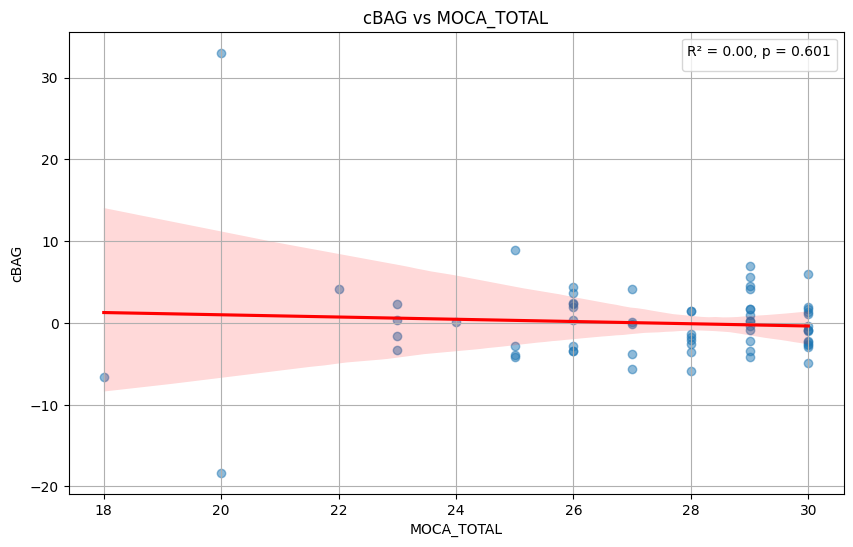

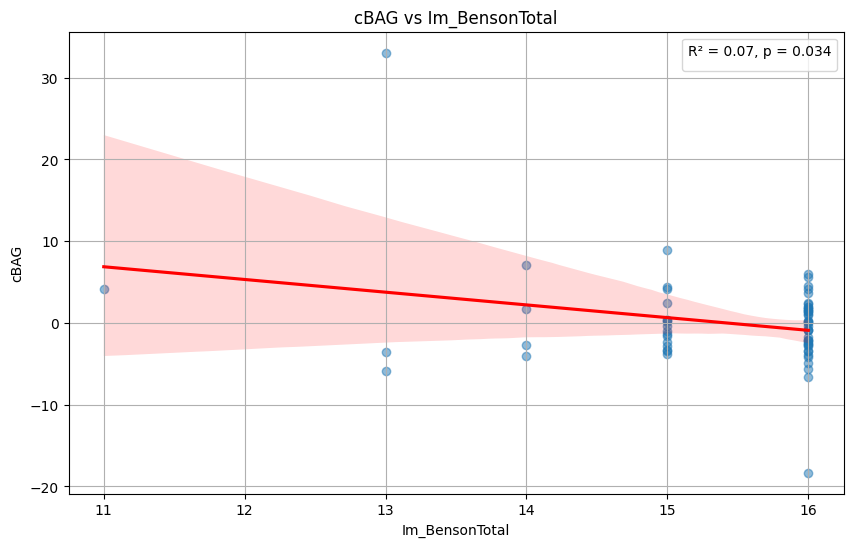

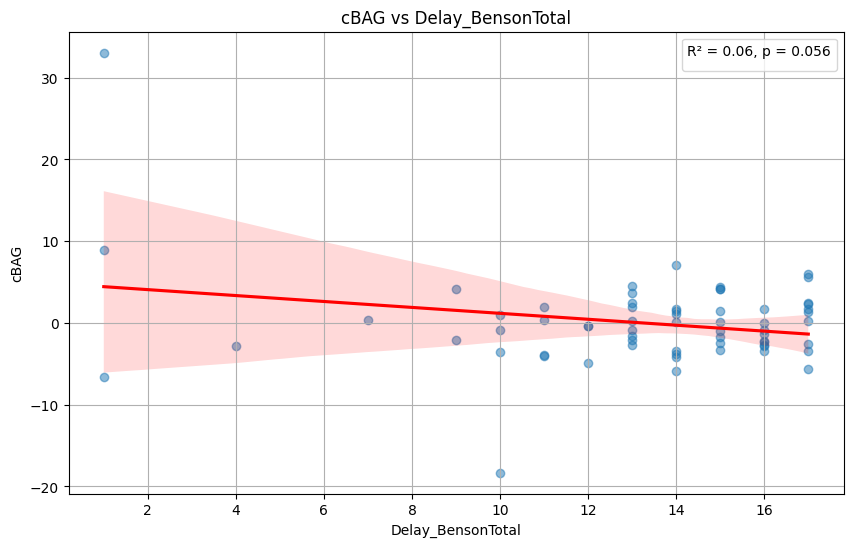

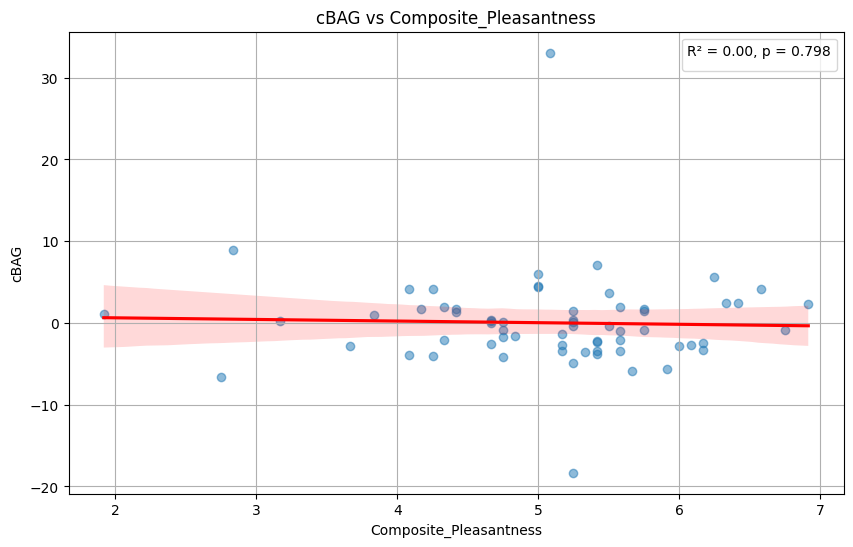

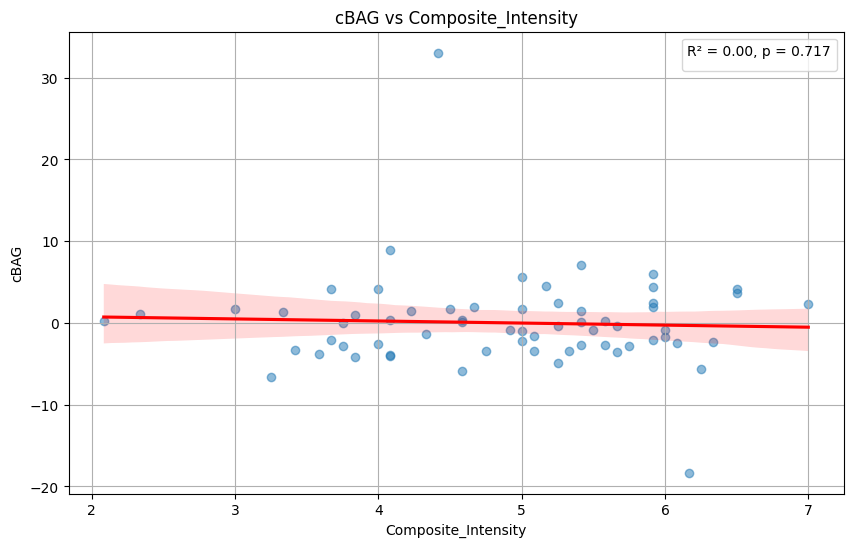

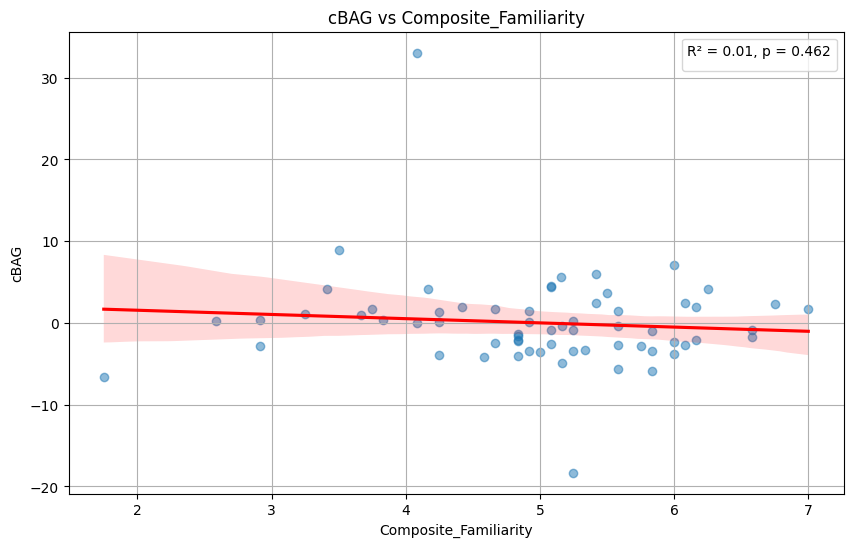

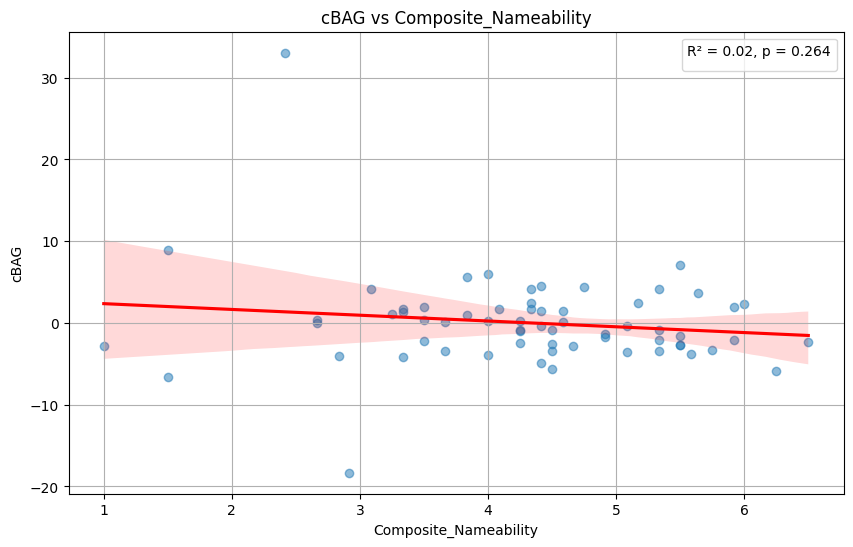

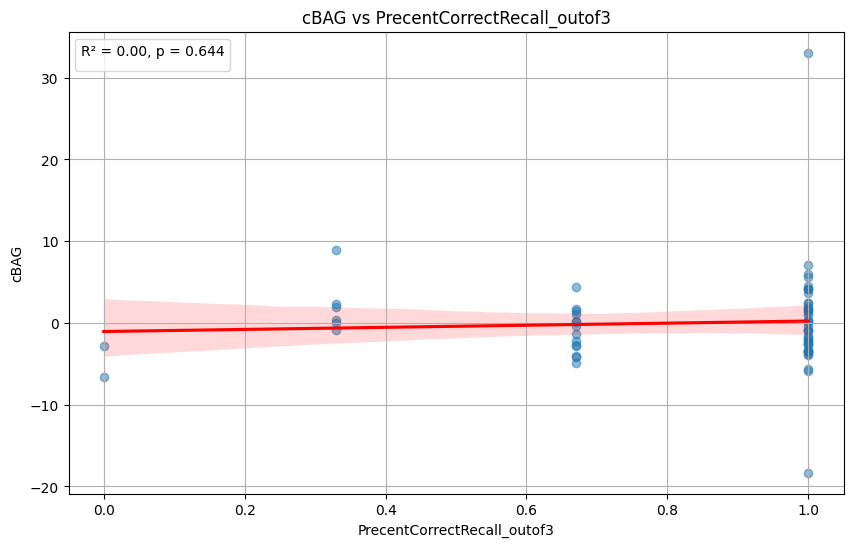

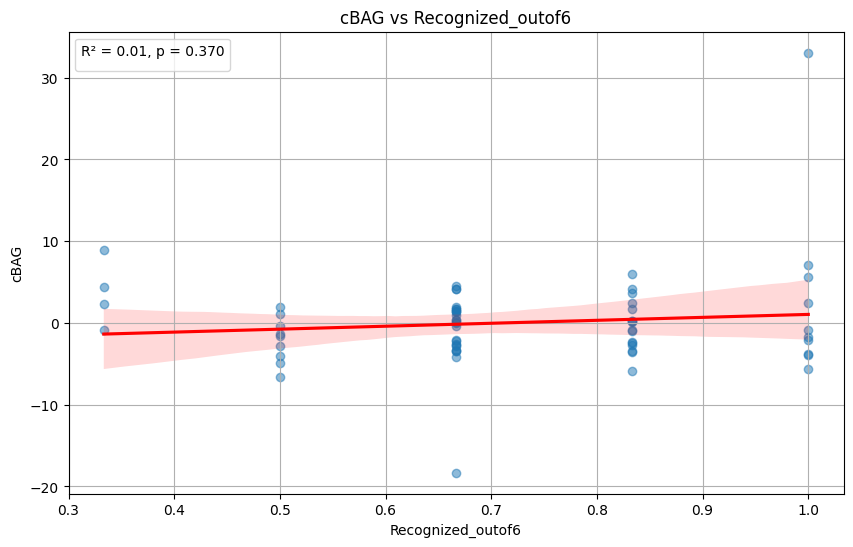

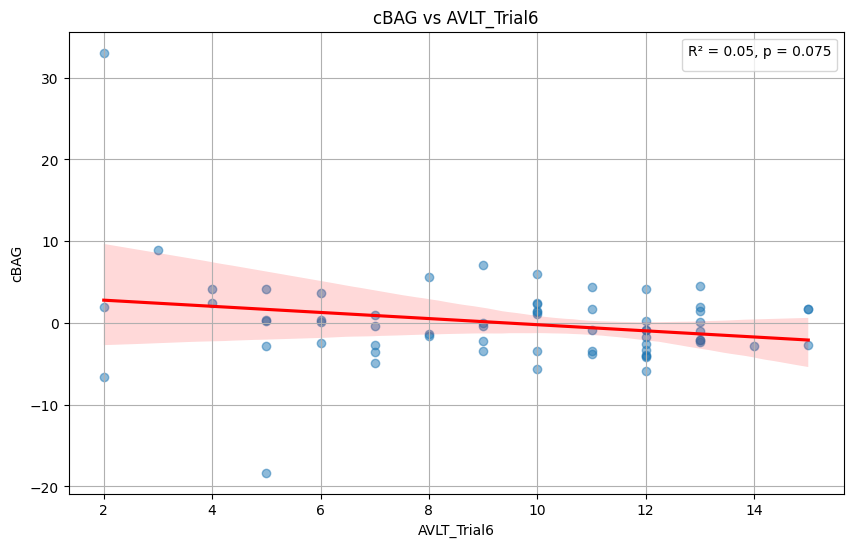

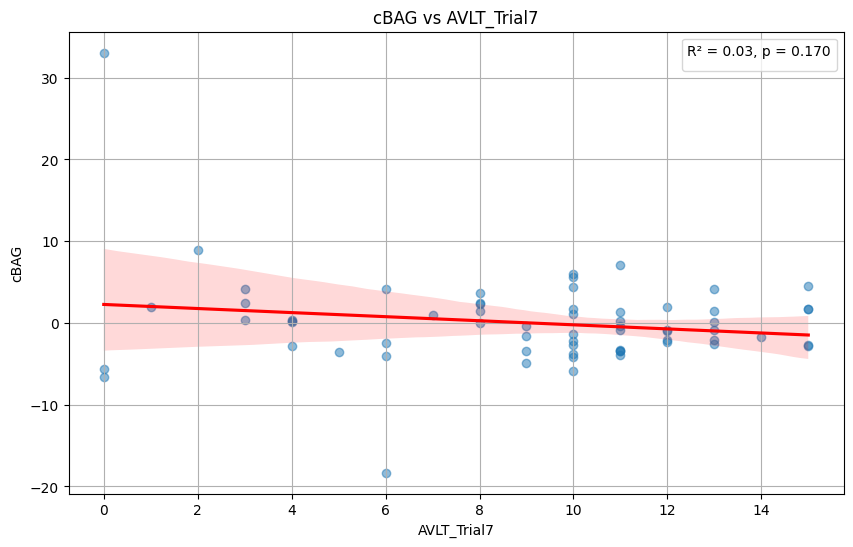

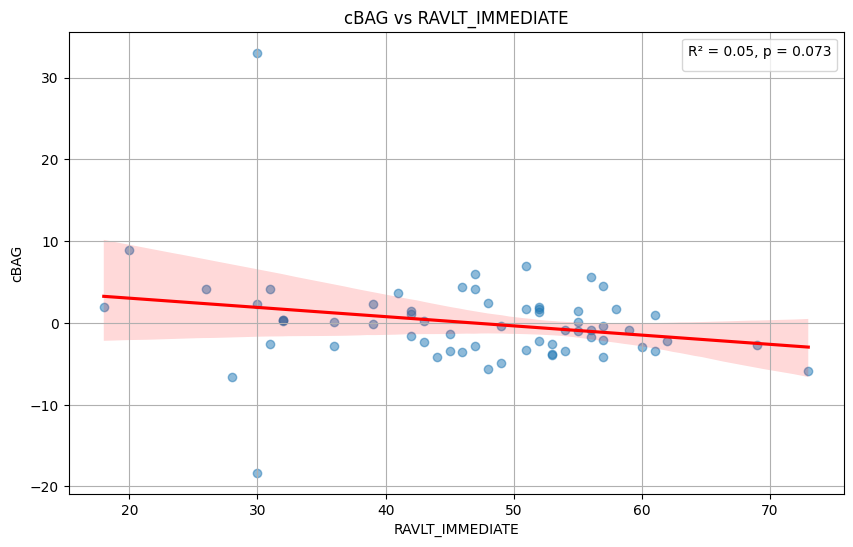

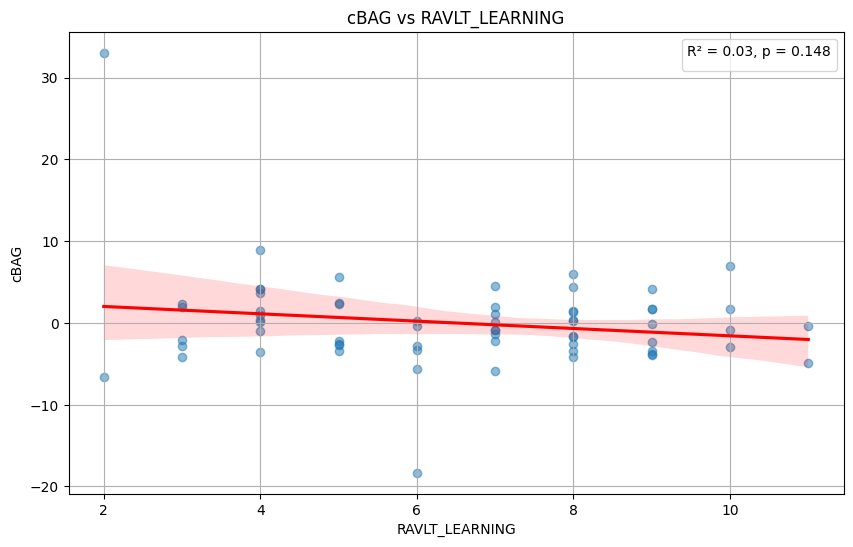

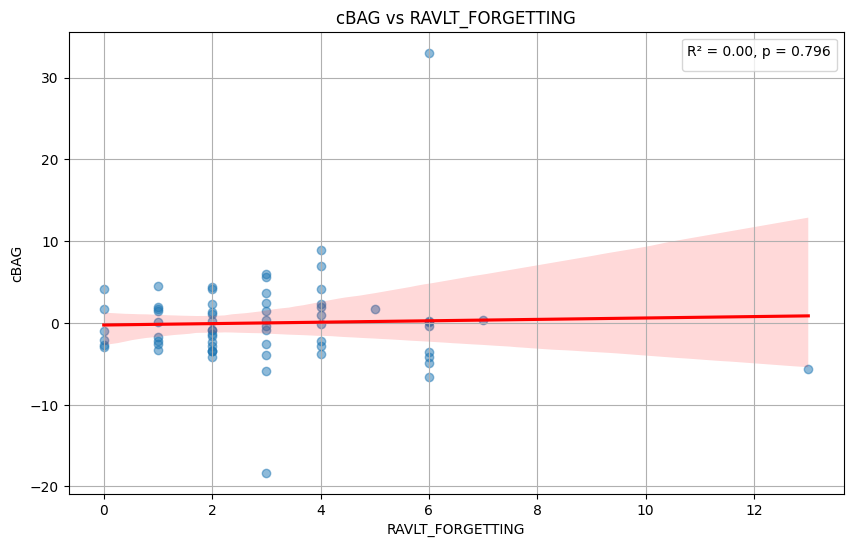

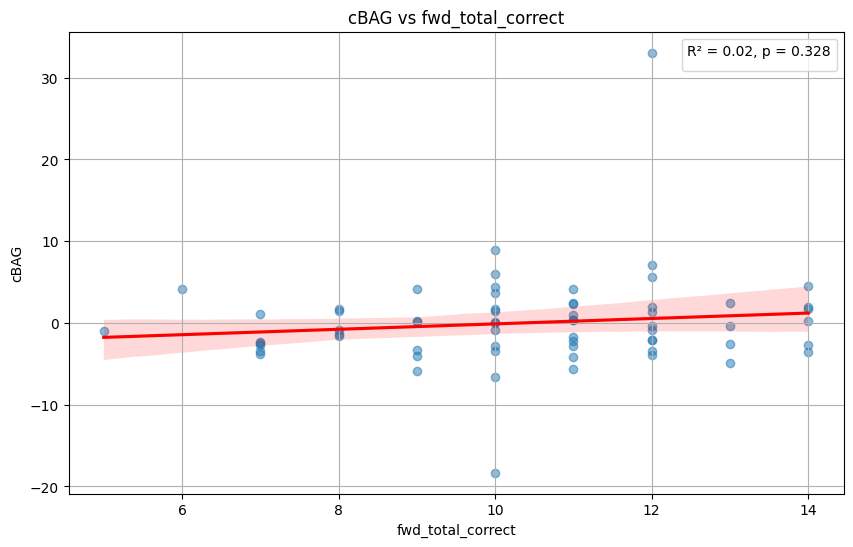

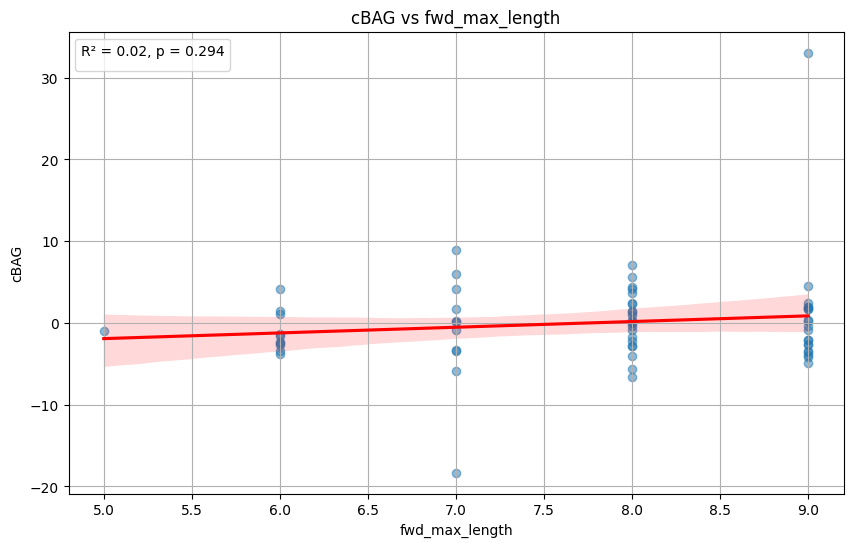

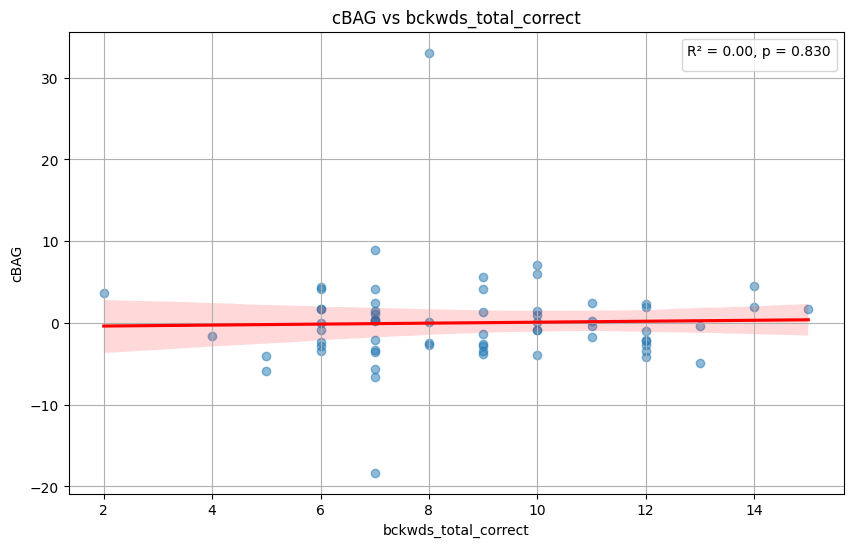

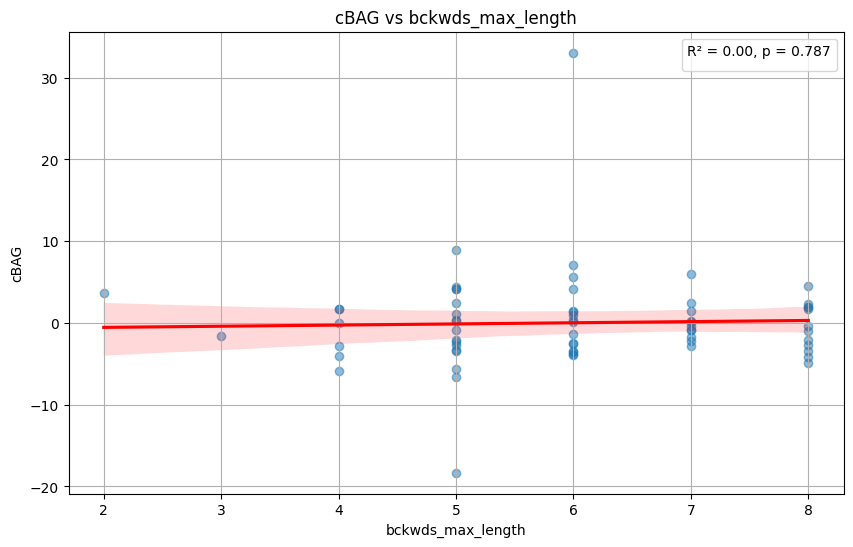

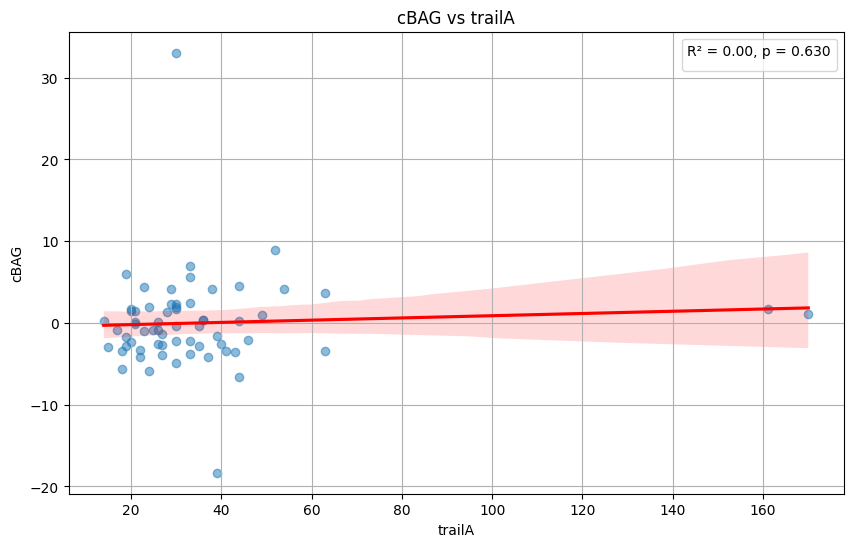

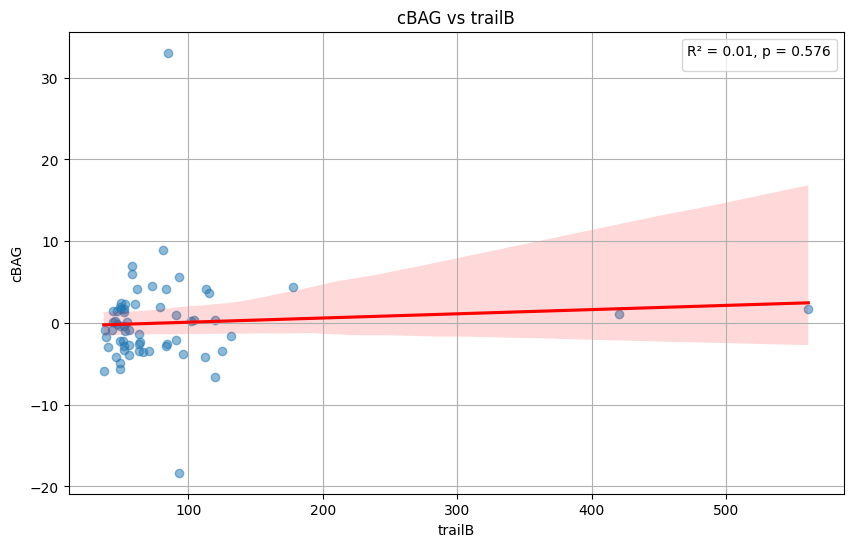

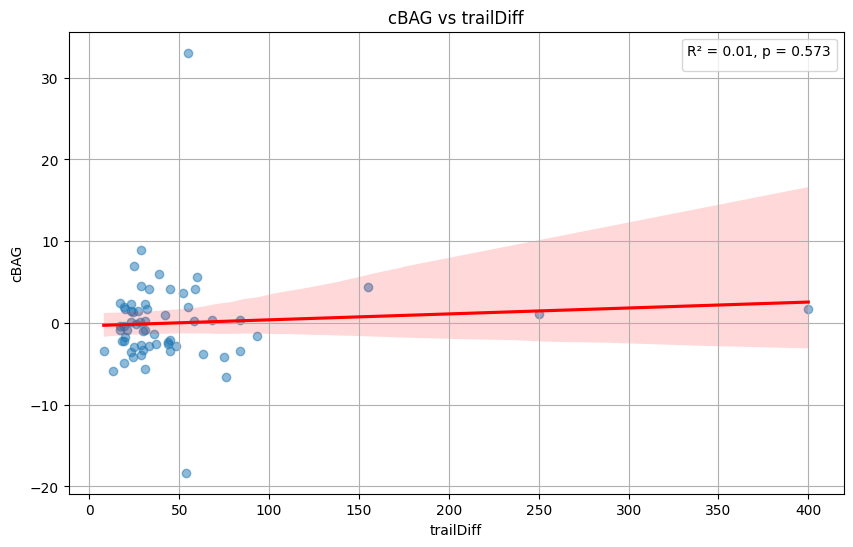

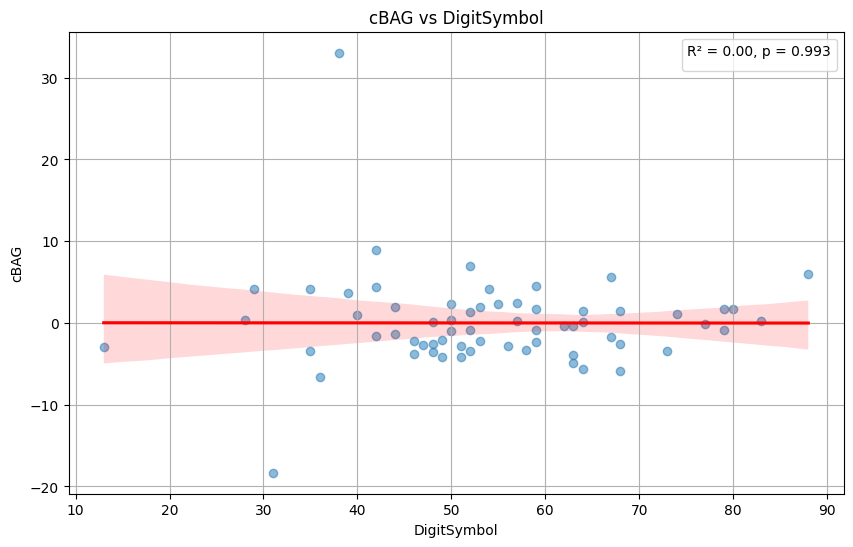

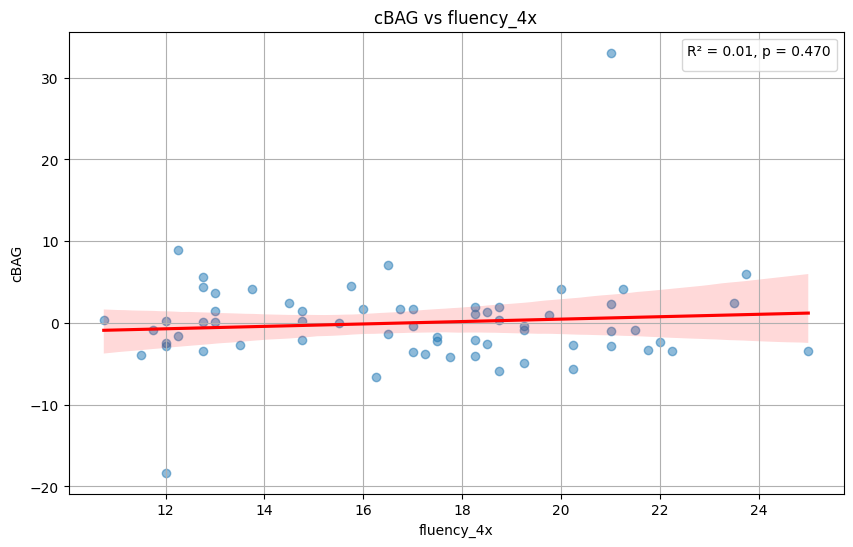

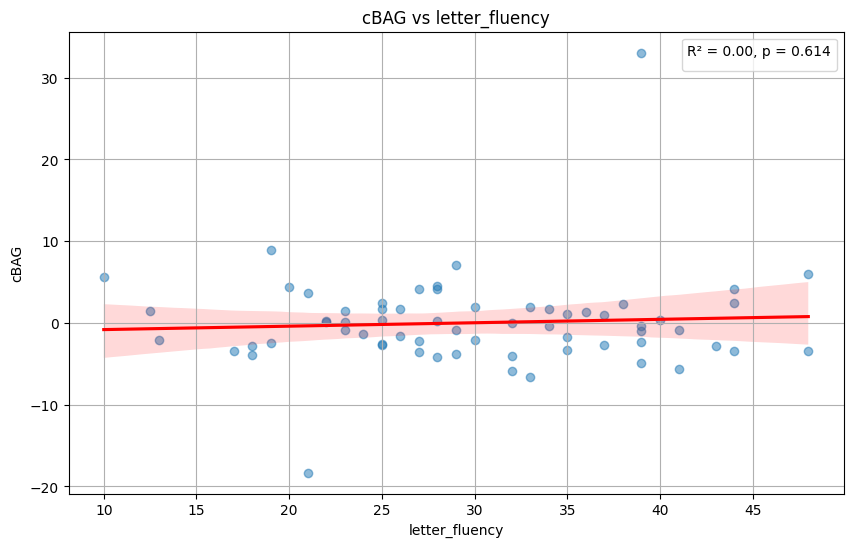

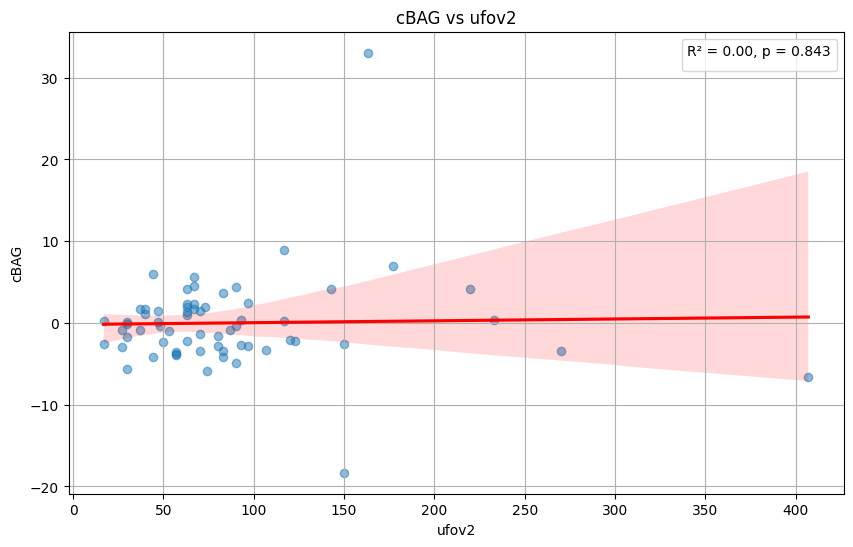

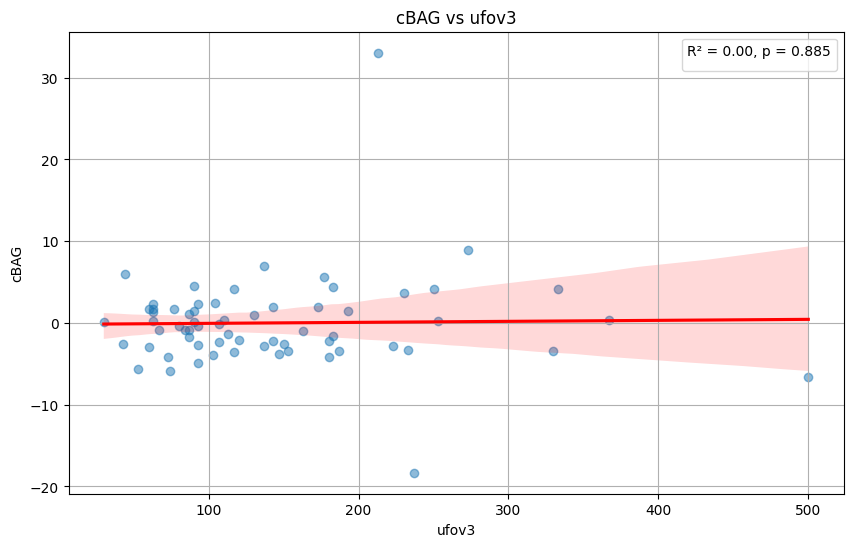

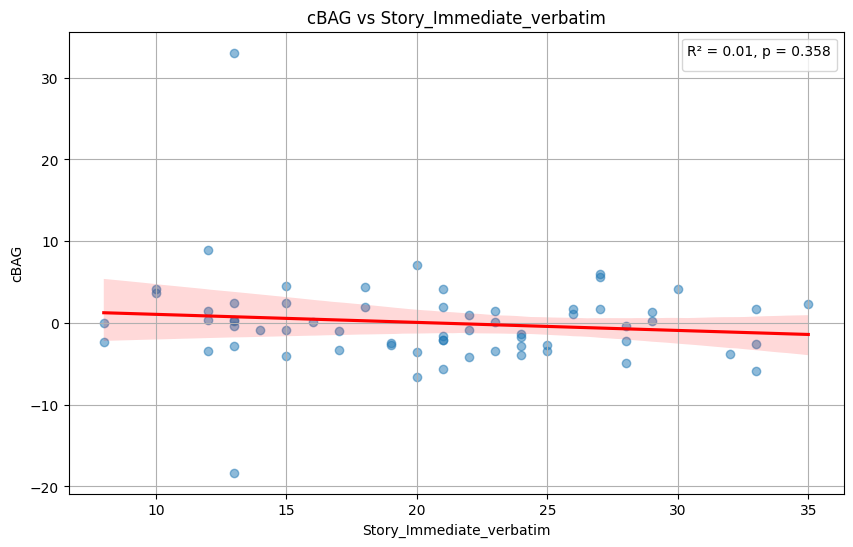

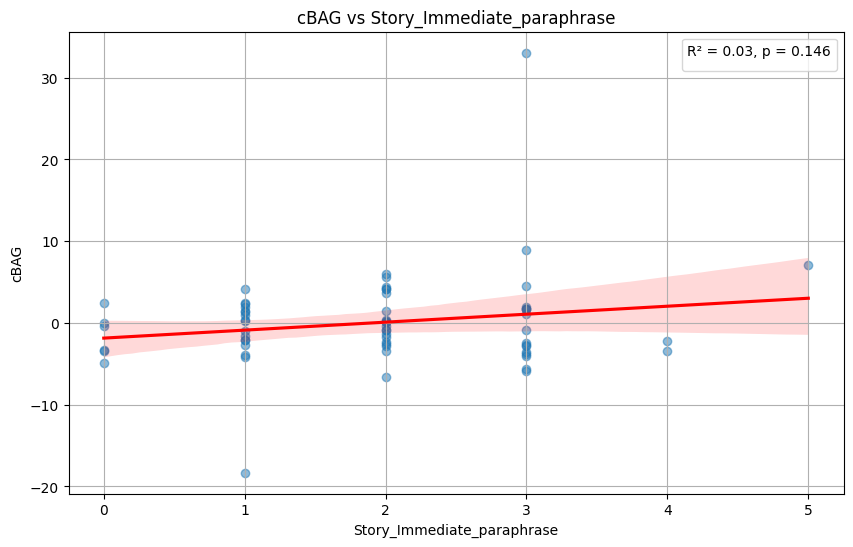

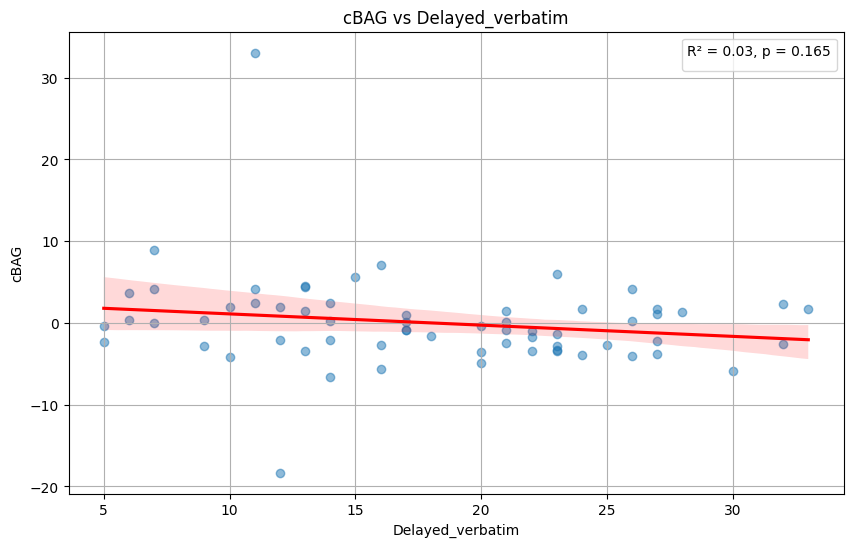

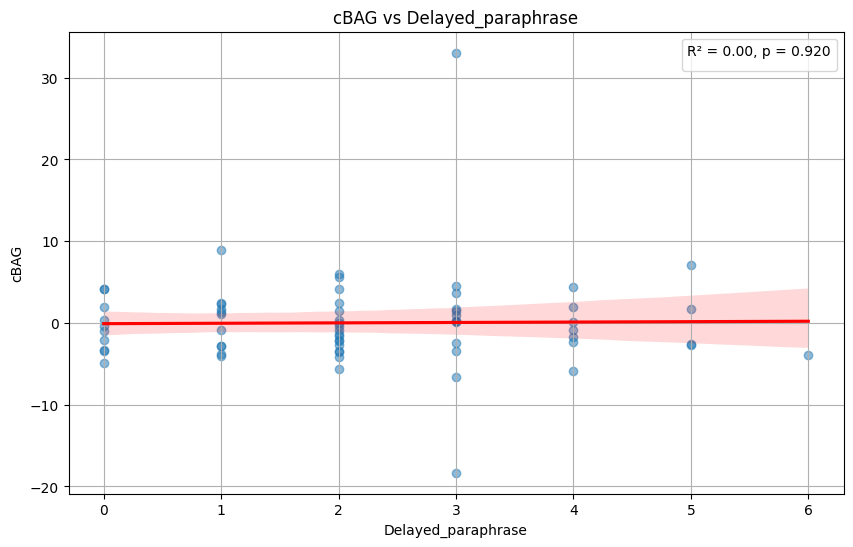

Top 10 cognitive columns with highest R² values:
              cognitive_column        R2   p_value
1               Im_BensonTotal  0.070736  0.033655
2            Delay_BensonTotal  0.057521  0.056283
11             RAVLT_IMMEDIATE  0.050757  0.073467
9                  AVLT_Trial6  0.050285  0.074854
28  Story_Immediate_paraphrase  0.033774  0.146040
12              RAVLT_LEARNING  0.033416  0.148236
29            Delayed_verbatim  0.030923  0.164552
10                 AVLT_Trial7  0.030099  0.170377
6        Composite_Nameability  0.020048  0.264412
15              fwd_max_length  0.017750  0.293946

Top 10 cognitive columns with lowest p-values:
              cognitive_column        R2   p_value
1               Im_BensonTotal  0.070736  0.033655
2            Delay_BensonTotal  0.057521  0.056283
11             RAVLT_IMMEDIATE  0.050757  0.073467
9                  AVLT_Trial6  0.050285  0.074854
28  Story_Immediate_paraphrase  0.033774  0.146040
12              RAVLT_LEARNING  0.03

In [2]:
# Plot the cBAG vs column from 'MOCA_TOTAL' to 'Delayed_paraphrase'
import seaborn as sns

cognitive_start = merged_df.columns.get_loc('MOCA_TOTAL')
cognitive_end = merged_df.columns.get_loc('Delayed_paraphrase') + 1
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

R2 = []
p_values = []

for column in cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['cBAG']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'cognitive_column': cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
top_10_cognitive = cognitive_r2_df.head(10)
print("Top 10 cognitive columns with highest R² values:")
print(top_10_cognitive)
# Print the top 10 cognitive columns with lowest p-values
top_10_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 cognitive columns with lowest p-values:")
print(top_10_cognitive_p)


In [3]:
# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
# Save the FDR corrected p-value results to a CSV file
# Sort from lowest to highest p-value
cognitive_r2_df['corrected_p_value'] = corrected_p_values
cognitive_r2_df = cognitive_r2_df.sort_values(by='corrected_p_value')
cognitive_r2_df.to_csv('cognitive_vs_cBAG_results.csv', index=False)


C:\Users\22679\AppData\Local\Temp\ipykernel_19464\406552247.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


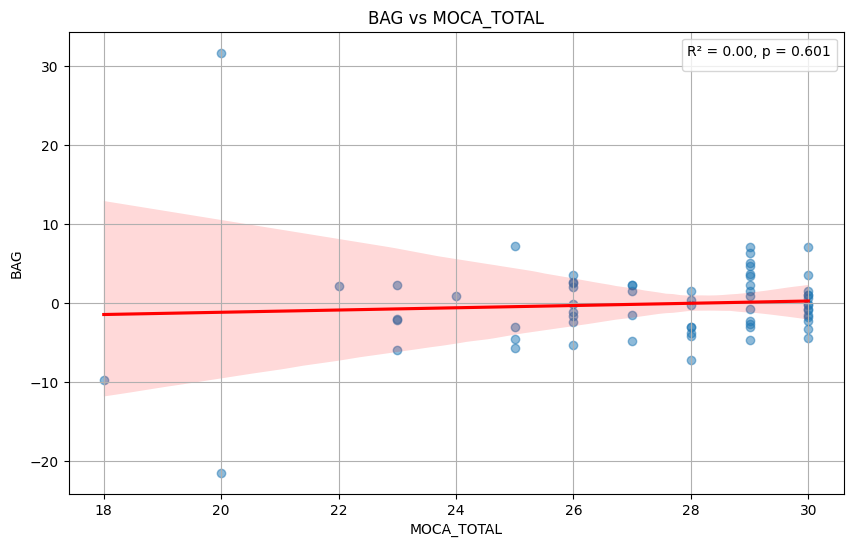

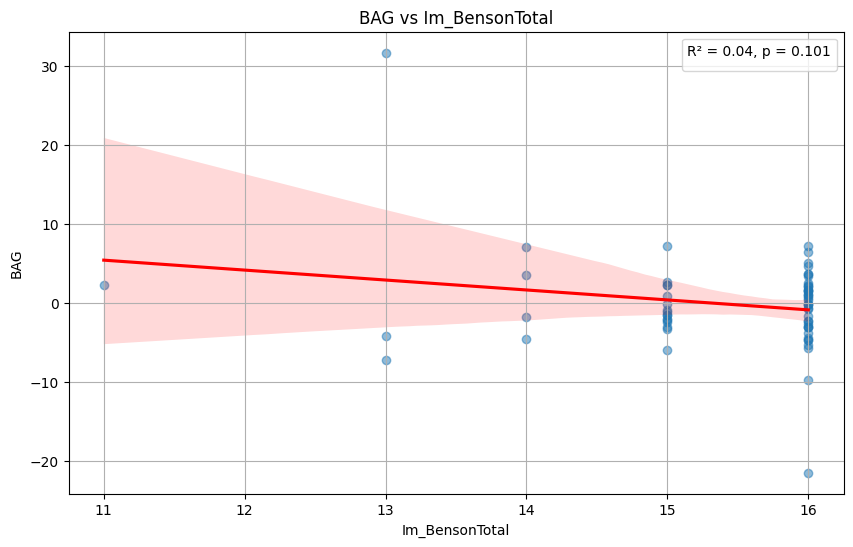

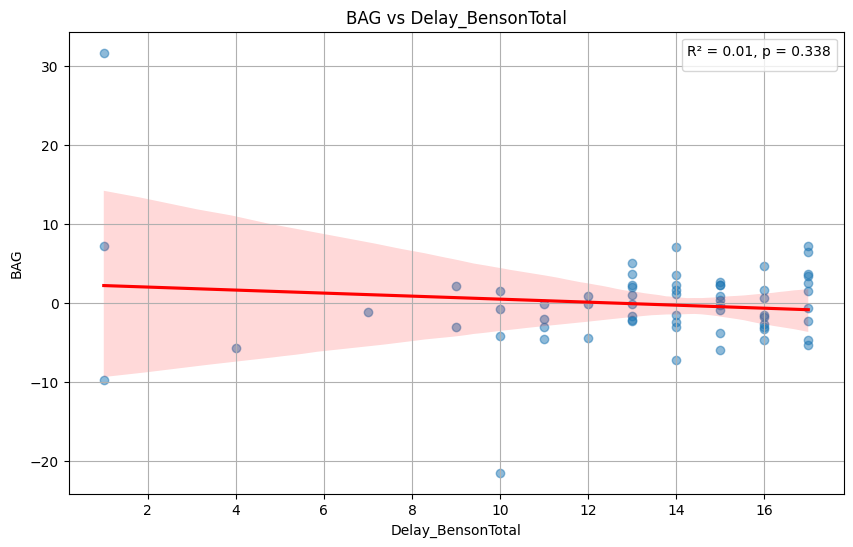

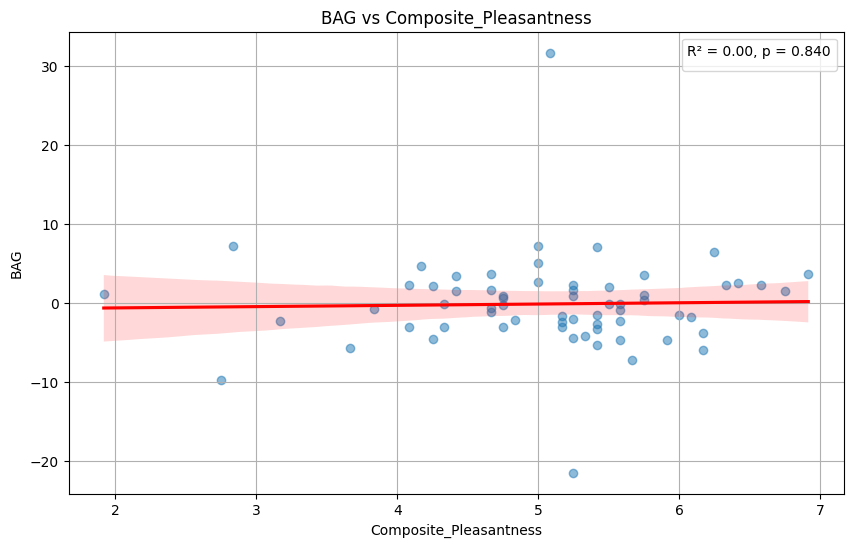

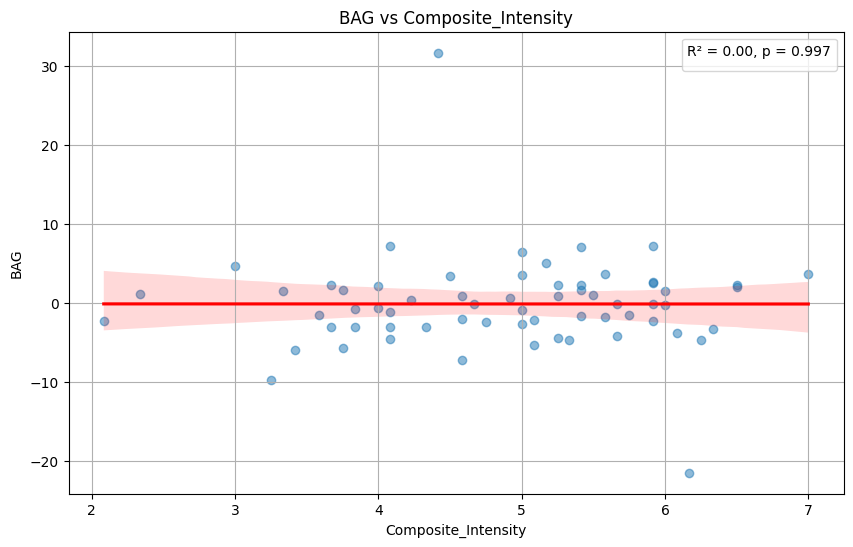

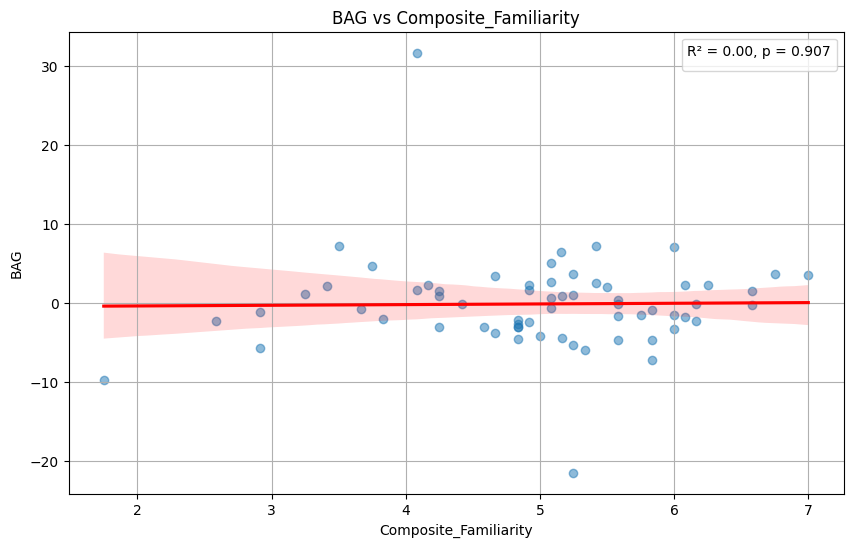

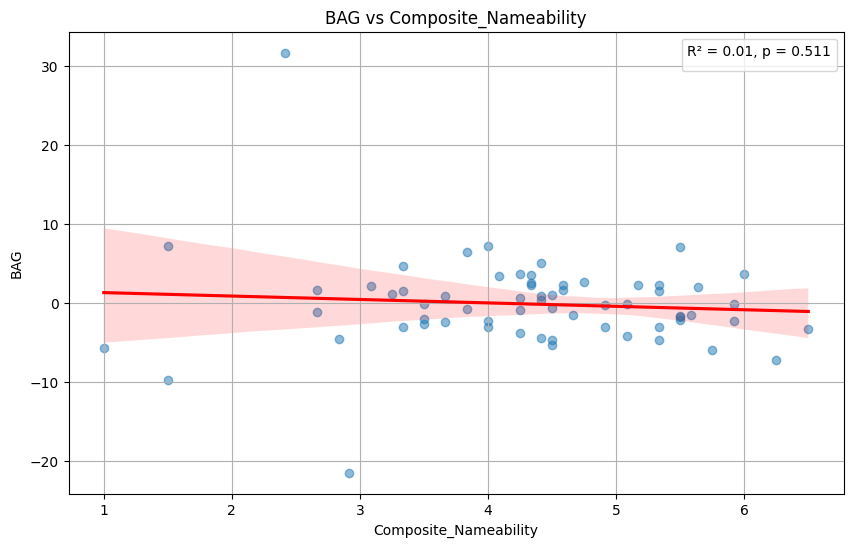

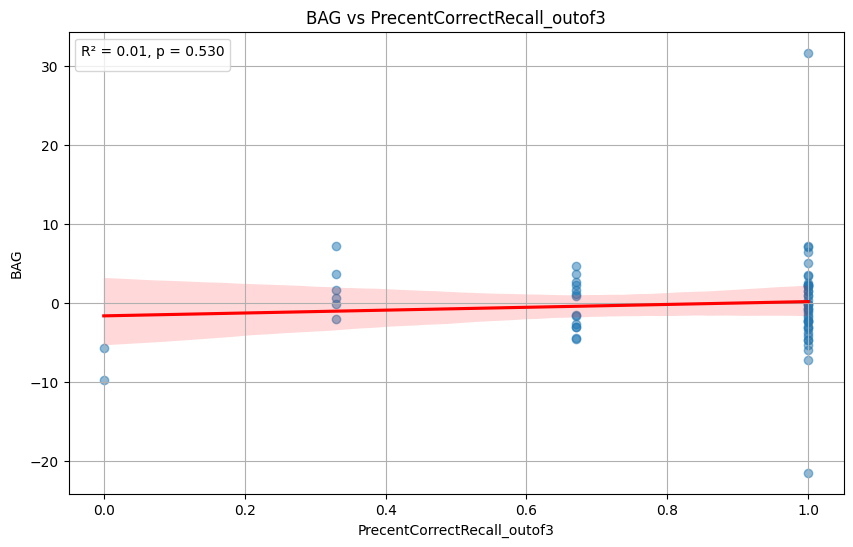

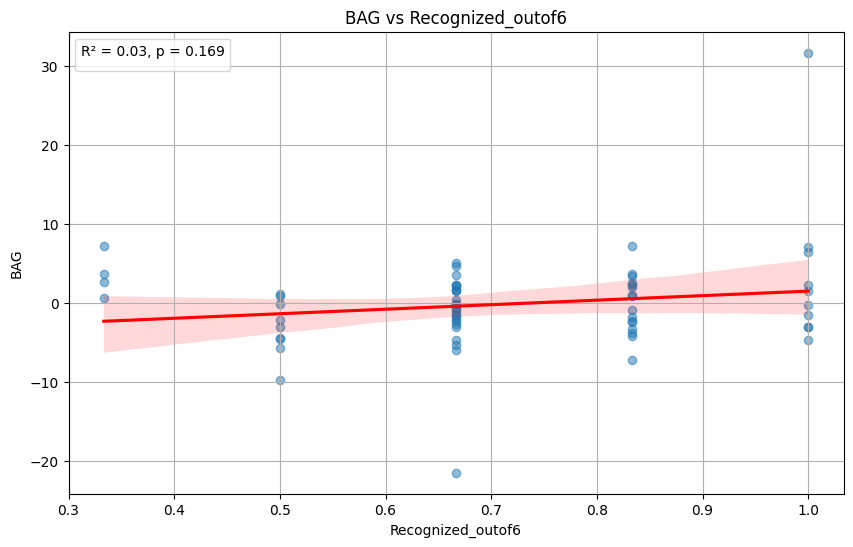

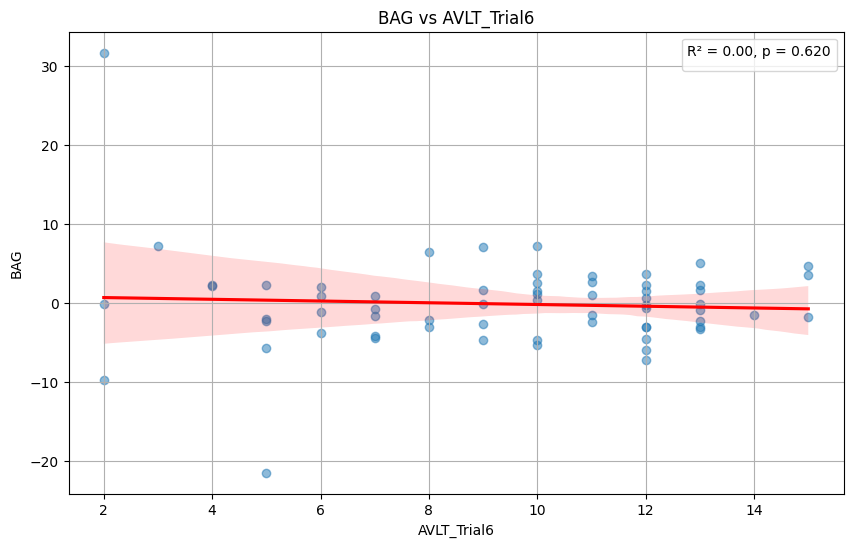

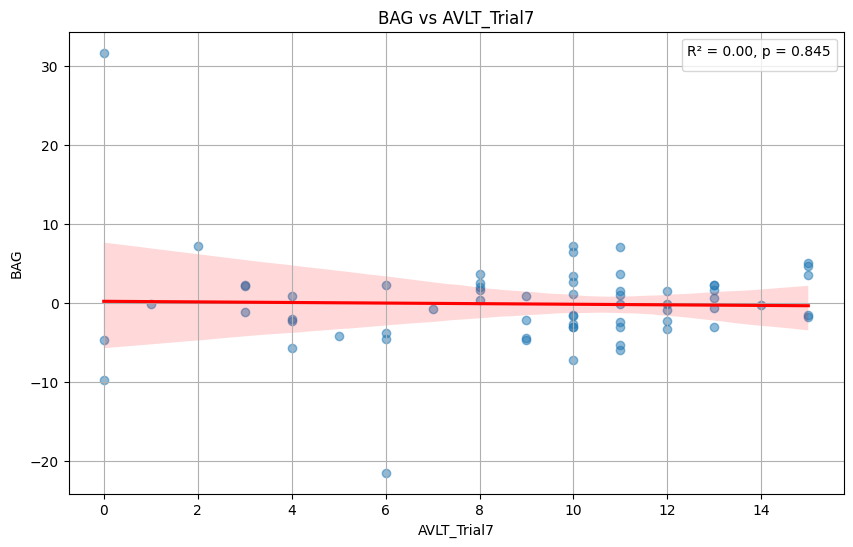

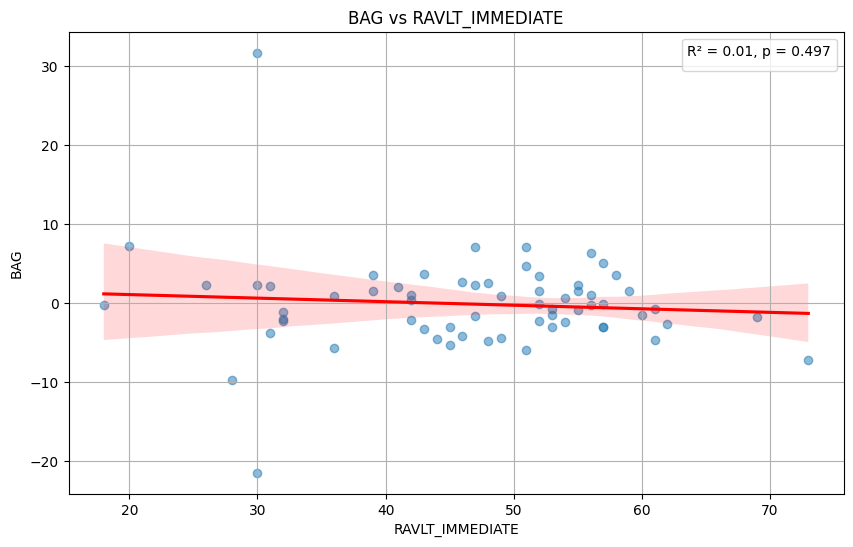

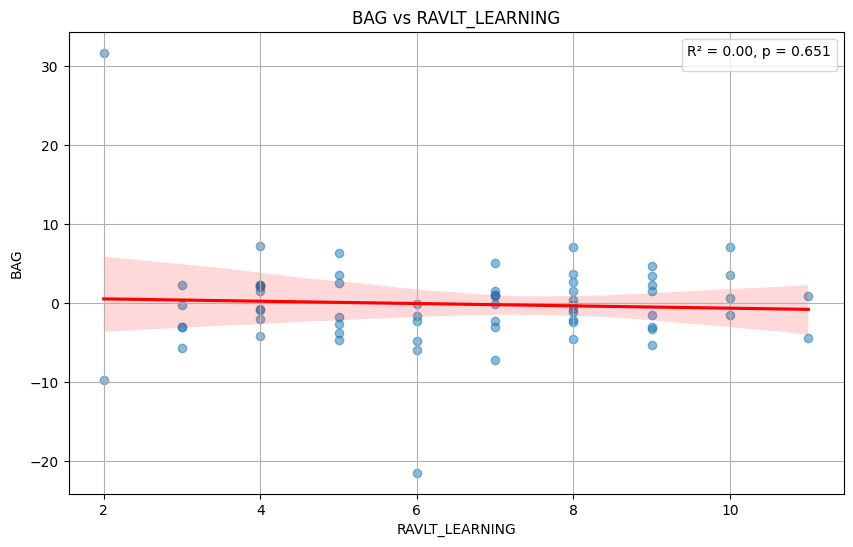

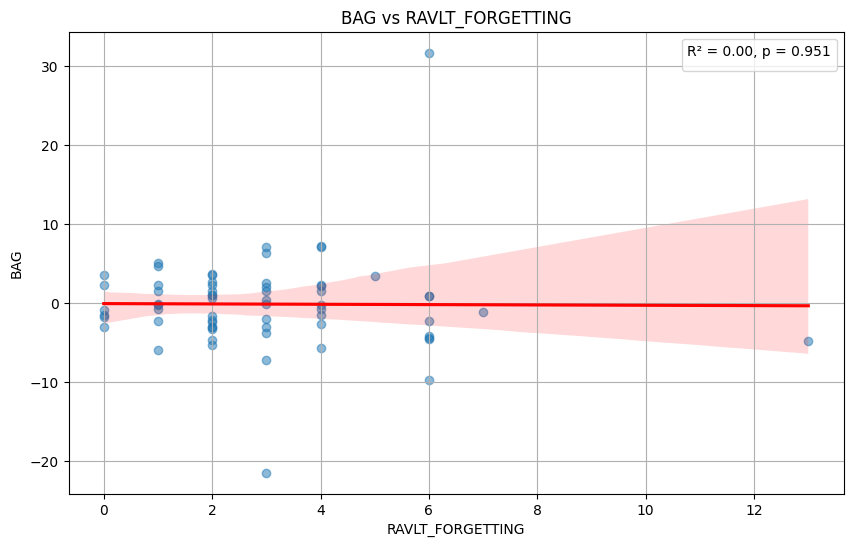

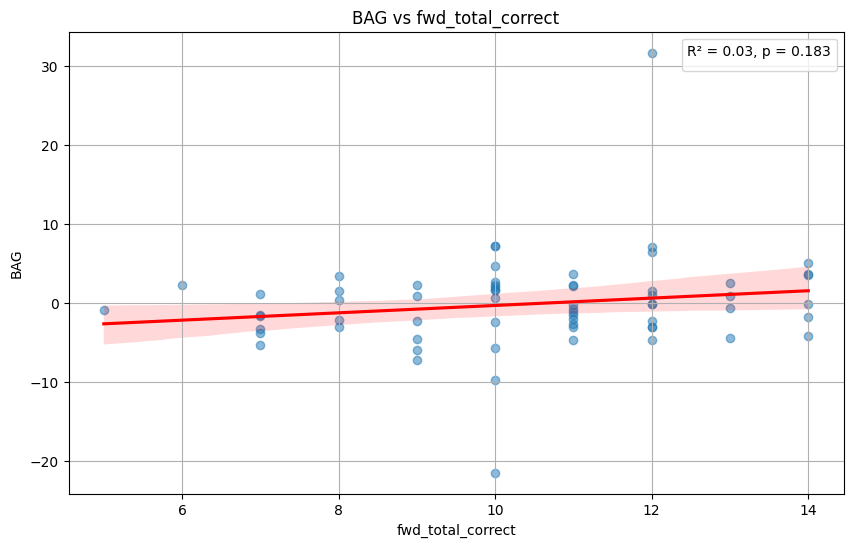

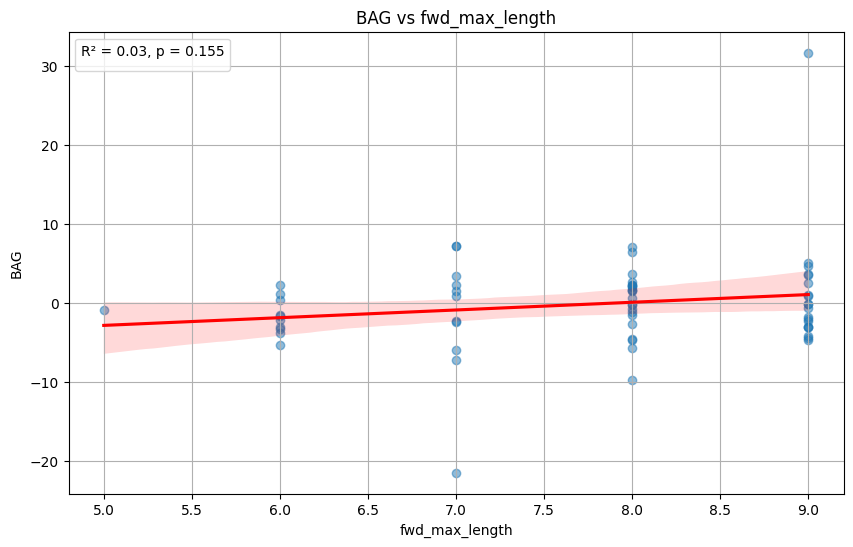

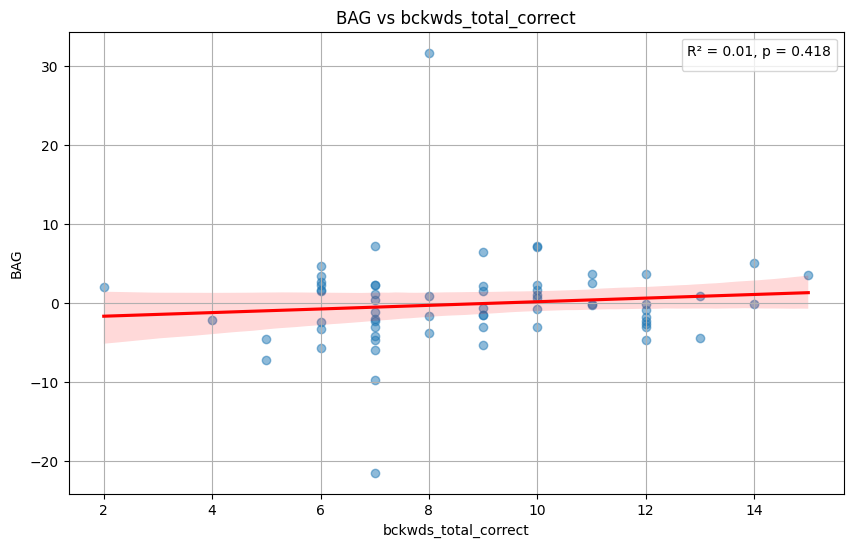

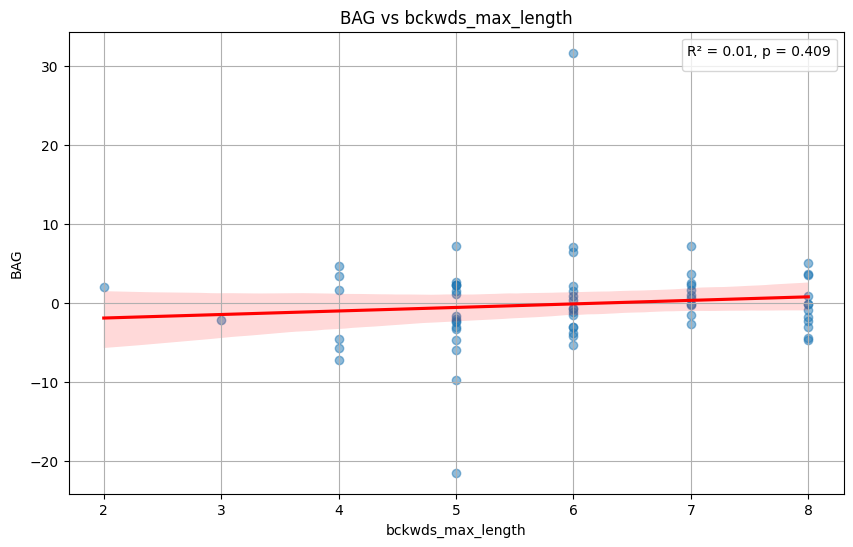

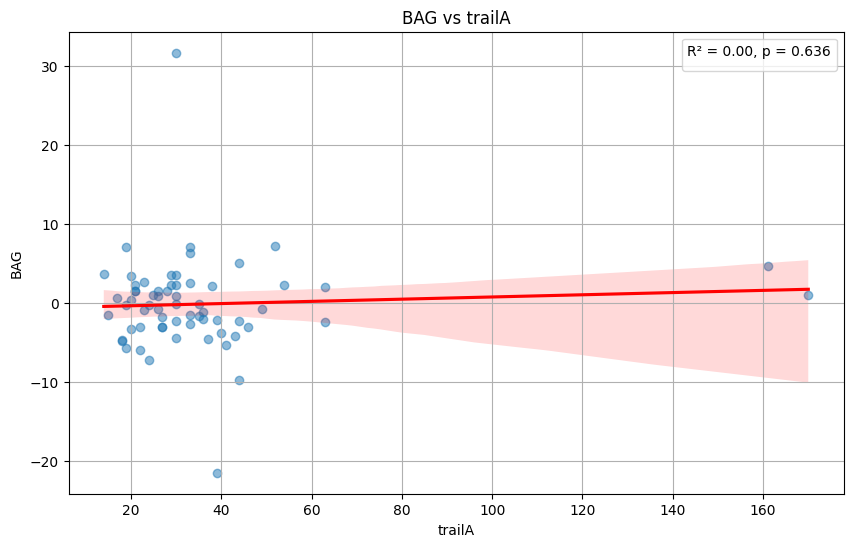

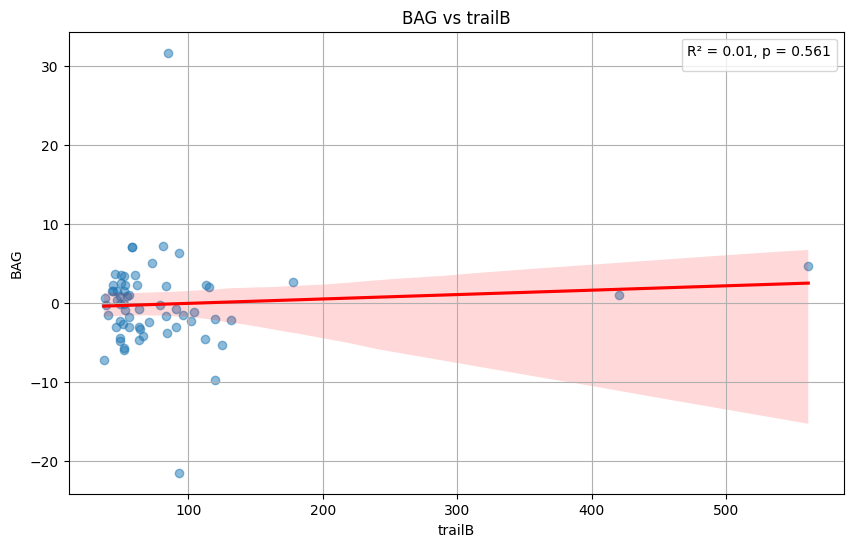

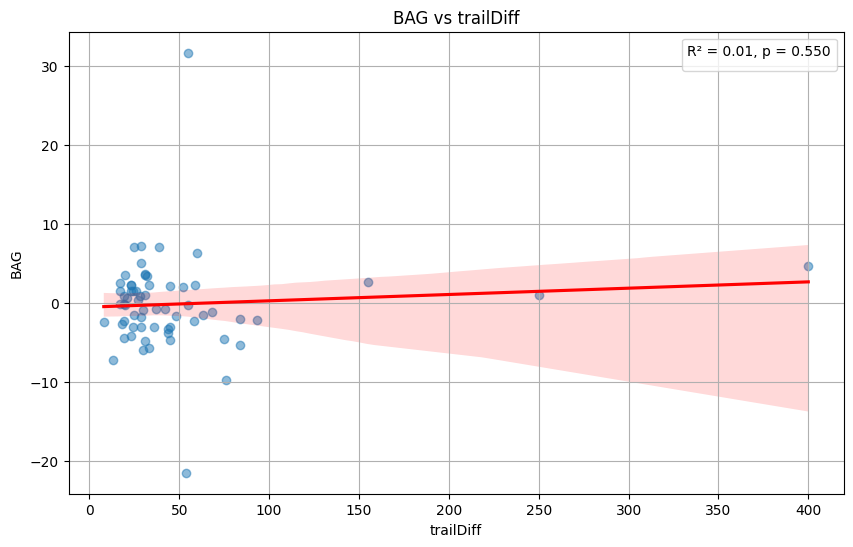

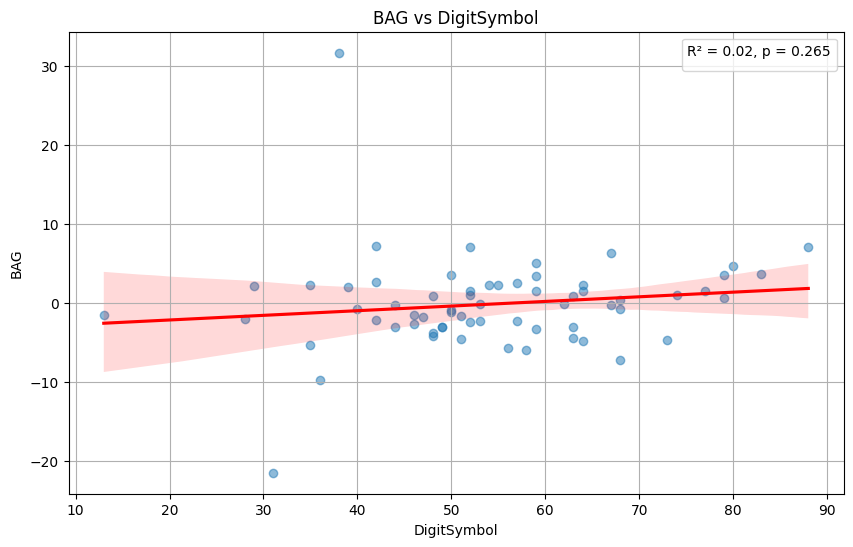

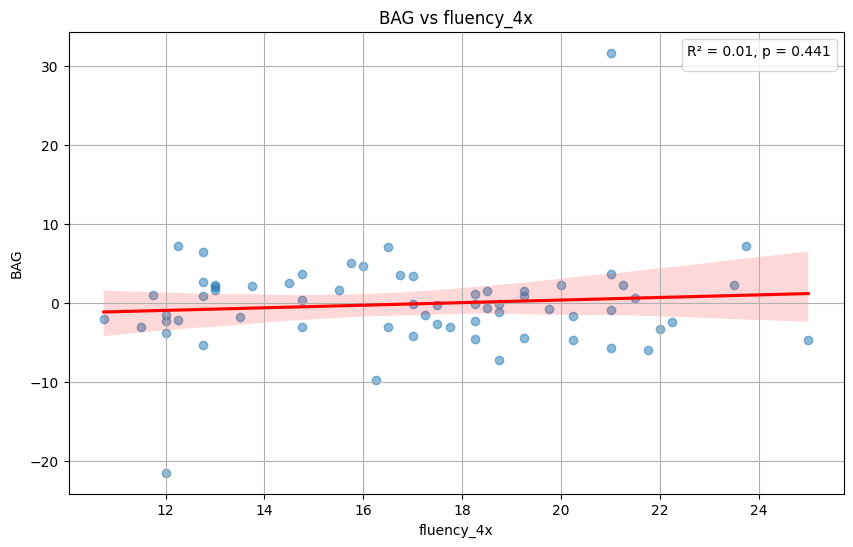

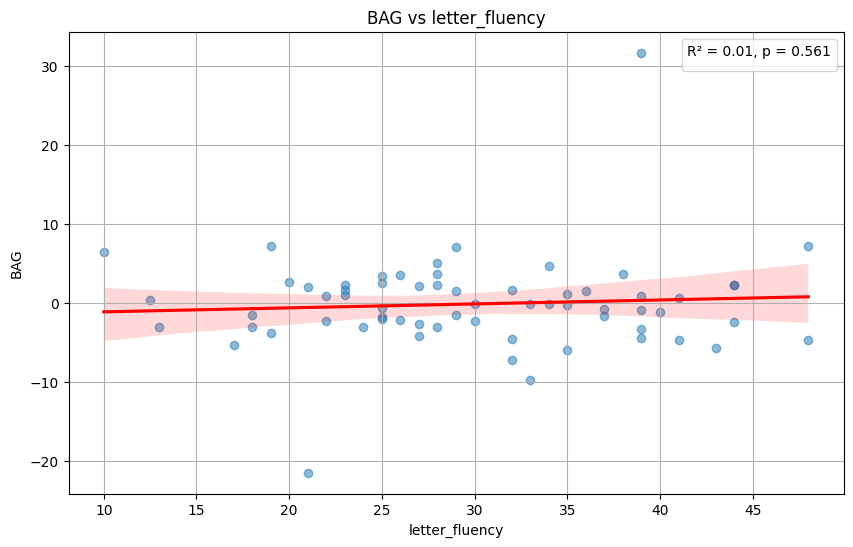

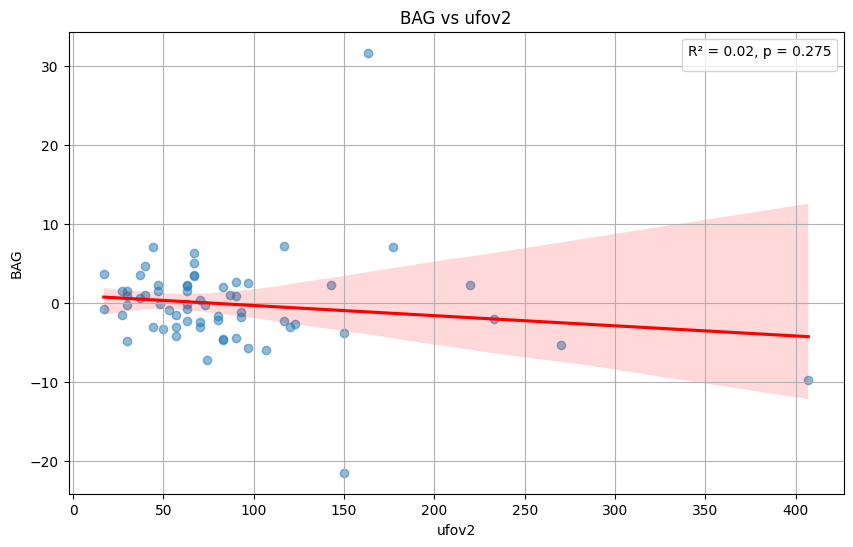

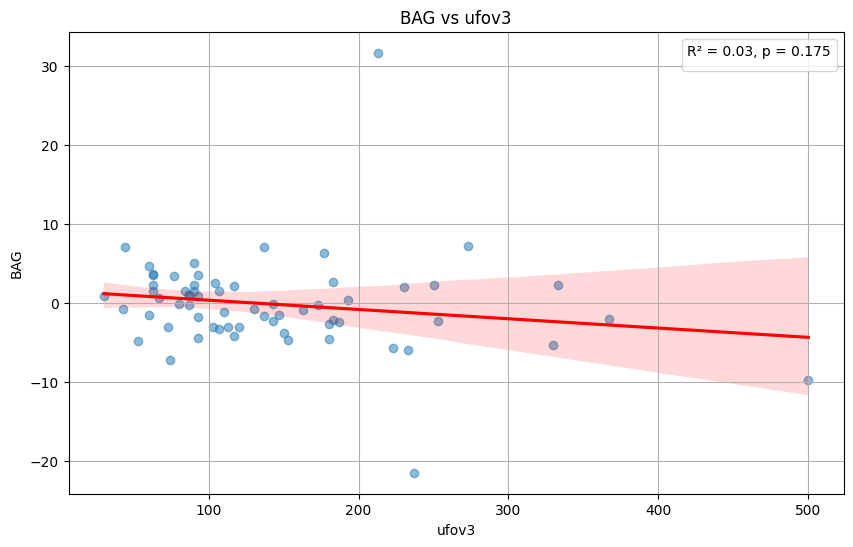

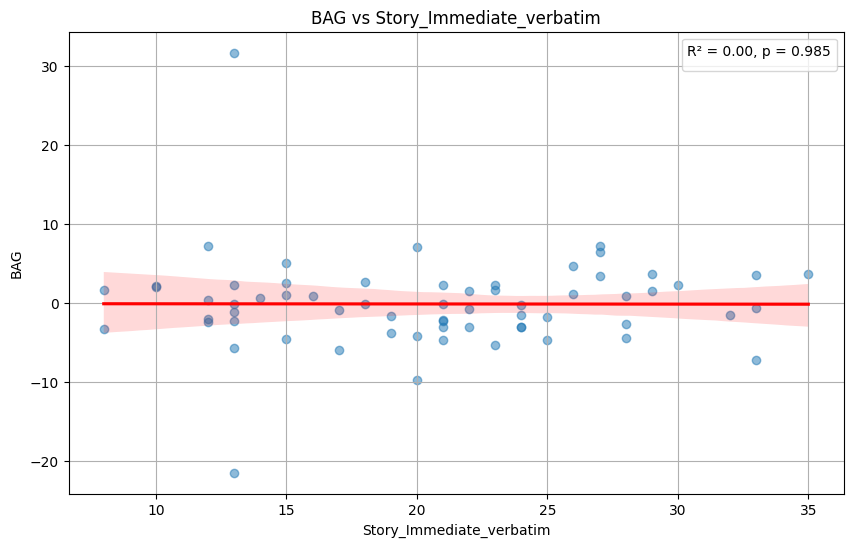

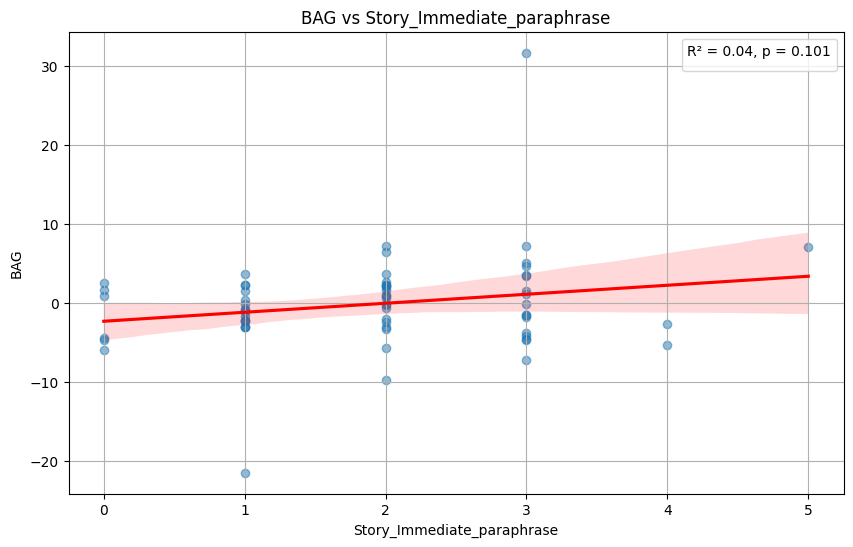

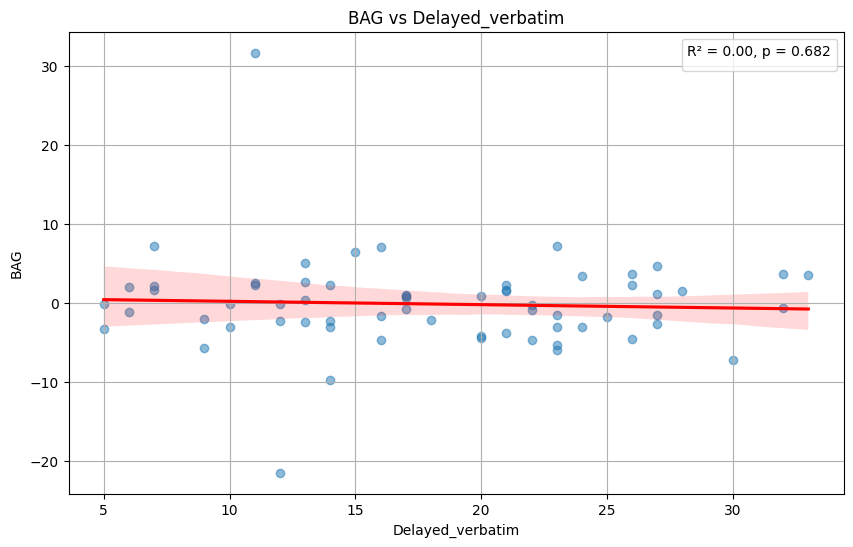

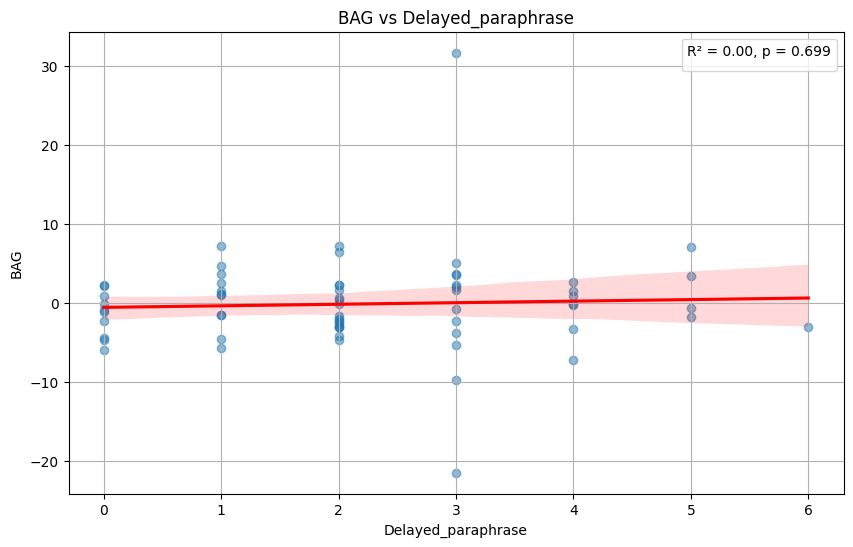

Top 10 cognitive columns with highest R² values:
              cognitive_column        R2   p_value
1               Im_BensonTotal  0.042893  0.100580
28  Story_Immediate_paraphrase  0.042670  0.101490
15              fwd_max_length  0.032281  0.155426
8            Recognized_outof6  0.030252  0.169282
26                       ufov3  0.029454  0.175100
14           fwd_total_correct  0.028413  0.183036
21                 DigitSymbol  0.020005  0.264921
25                       ufov2  0.019226  0.274530
2            Delay_BensonTotal  0.014801  0.338235
17           bckwds_max_length  0.011017  0.409129

Top 10 cognitive columns with lowest p-values:
              cognitive_column        R2   p_value
1               Im_BensonTotal  0.042893  0.100580
28  Story_Immediate_paraphrase  0.042670  0.101490
15              fwd_max_length  0.032281  0.155426
8            Recognized_outof6  0.030252  0.169282
26                       ufov3  0.029454  0.175100
14           fwd_total_correct  0.02

In [4]:
# Plot the BAG vs column from 'MOCA_TOTAL' to 'Delayed_paraphrase'
import seaborn as sns

cognitive_start = merged_df.columns.get_loc('MOCA_TOTAL')
cognitive_end = merged_df.columns.get_loc('Delayed_paraphrase') + 1
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

R2 = []
p_values = []

for column in cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['BAG']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'cognitive_column': cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
top_10_cognitive = cognitive_r2_df.head(10)
print("Top 10 cognitive columns with highest R² values:")
print(top_10_cognitive)
# Print the top 10 cognitive columns with lowest p-values
top_10_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 cognitive columns with lowest p-values:")
print(top_10_cognitive_p)


## cBAG vs. biological metrics

C:\Users\22679\AppData\Local\Temp\ipykernel_19464\853178695.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


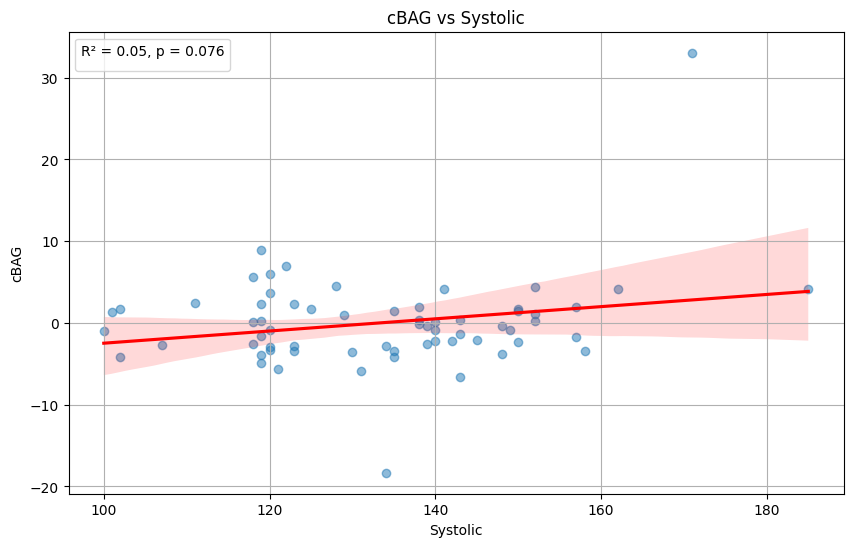

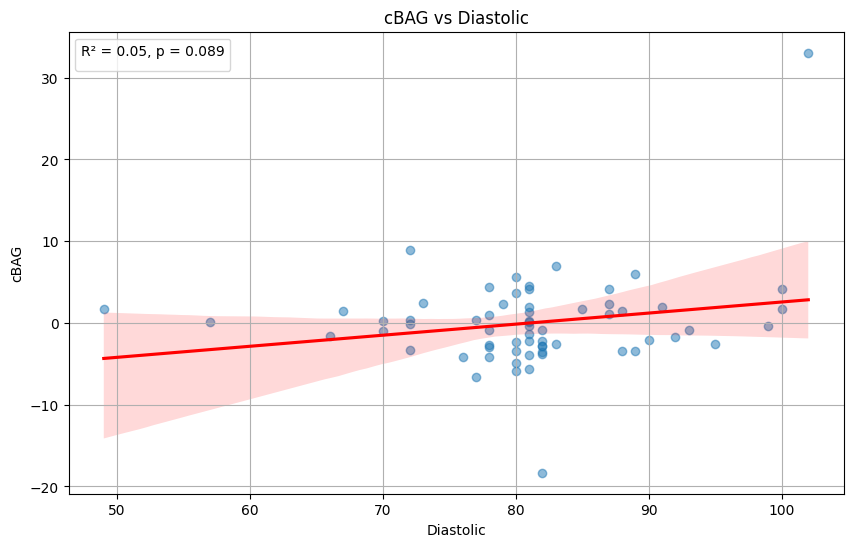

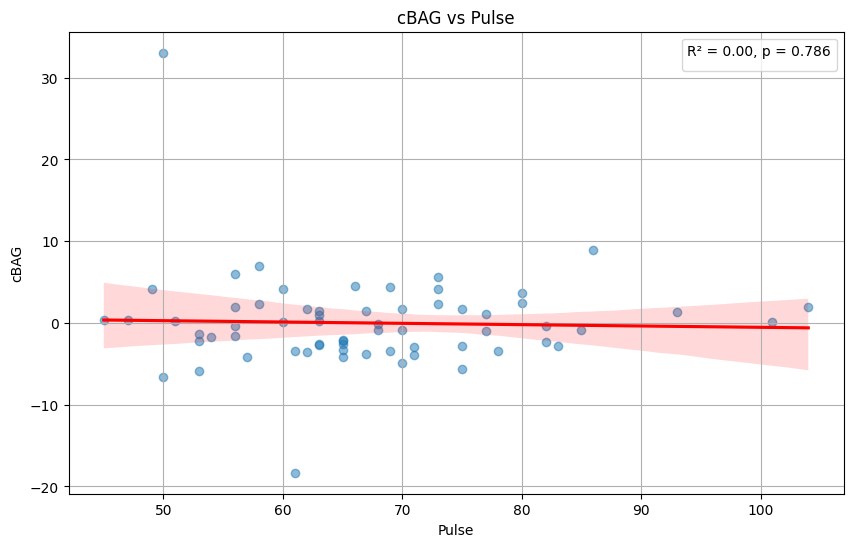

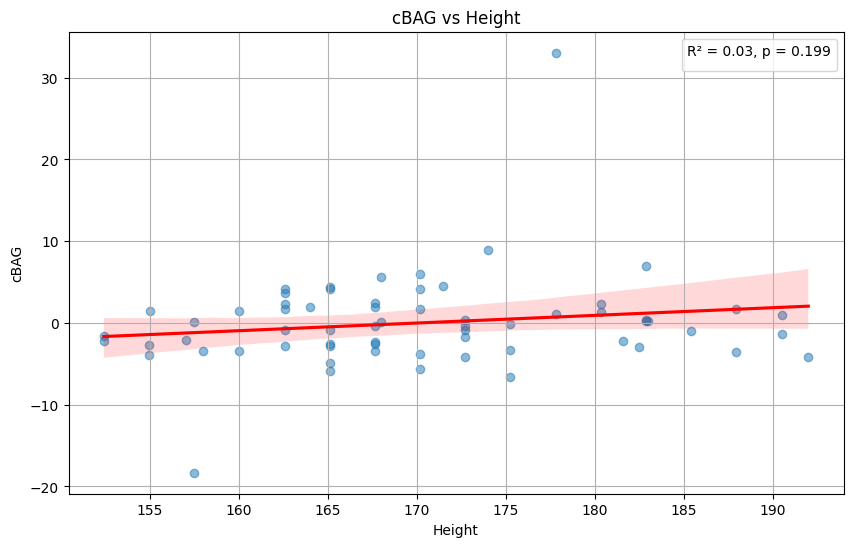

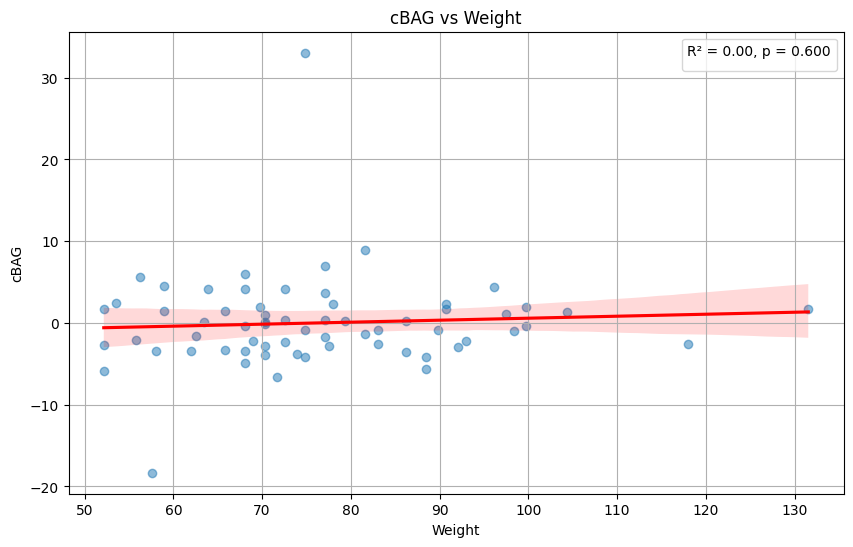

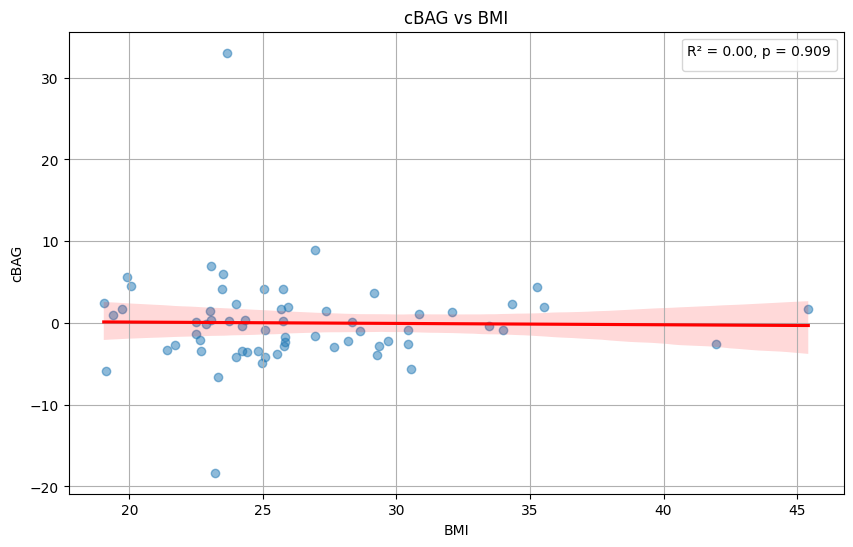

In [5]:
import seaborn as sns
from scipy.stats import linregress

# Plot cBAG vs biological metrics with regression line, R2, and p-value

biological_start = merged_df.columns.get_loc('Systolic')
biological_end = merged_df.columns.get_loc('BMI') + 1
biological_columns = merged_df.columns[biological_start:biological_end]

for column in biological_columns:
    x = merged_df[column]
    y = merged_df['cBAG']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()

# AUC

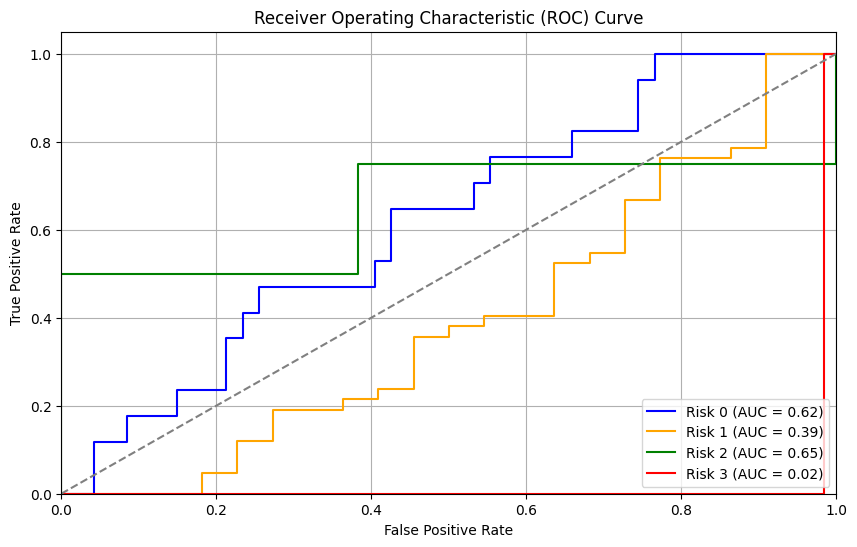

AUC for Risk Group 0: 0.6182728410513141
AUC for Risk Group 1: 0.39069264069264076
AUC for Risk Group 2: 0.6541666666666667
AUC for Risk Group 3: 0.015873015873015928


In [6]:
# Group the sibjects into 2 groups by 'risk_for_ad'= 0 and 1 or 'risk_for_ad'= 2 and 3
risk_group_01 = merged_df[merged_df['risk_for_ad'].isin([0, 1])]
risk_group_23 = merged_df[merged_df['risk_for_ad'].isin([2, 3])]

# Plot the ROC curve by using cBAG to predict 'risk_for_ad'
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarize the 'risk_for_ad' column
y = label_binarize(merged_df['risk_for_ad'], classes=[0, 1, 2, 3])
# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(y.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y[:, i], merged_df['cBAG'])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr[0], tpr[0], color='blue', label='Risk 0 (AUC = {:.2f})'.format(roc_auc[0]))
plt.plot(fpr[1], tpr[1], color='orange', label='Risk 1 (AUC = {:.2f})'.format(roc_auc[1]))
plt.plot(fpr[2], tpr[2], color='green', label='Risk 2 (AUC = {:.2f})'.format(roc_auc[2]))
plt.plot(fpr[3], tpr[3], color='red', label='Risk 3 (AUC = {:.2f})'.format(roc_auc[3]))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print the AUC for each risk group
print("AUC for Risk Group 0:", roc_auc[0])
print("AUC for Risk Group 1:", roc_auc[1])
print("AUC for Risk Group 2:", roc_auc[2])
print("AUC for Risk Group 3:", roc_auc[3])


95% Confidence Interval for AUC: [0.00, 0.97]


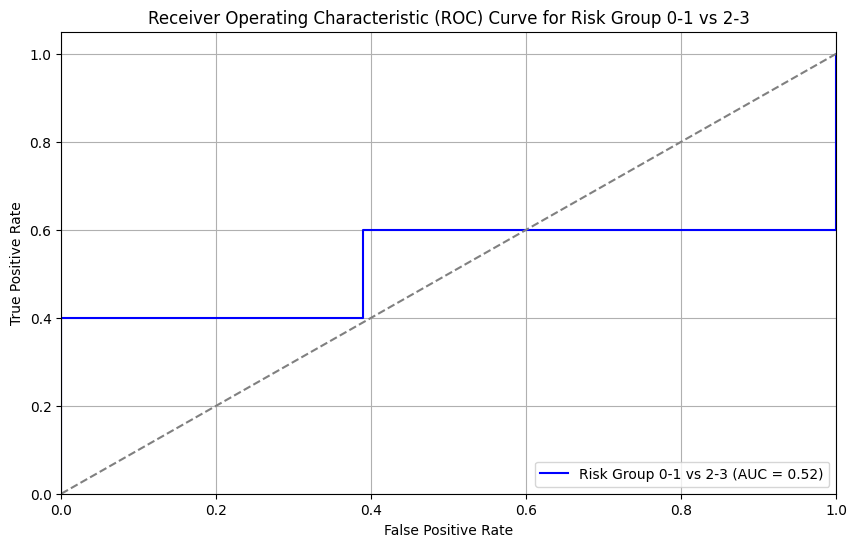

AUC for Risk Group 0-1 vs 2-3: 0.5220338983050847


In [7]:
# Plot the ROC curve by using cBAG to predict group 0 and 1 vs group 2 and 3
y_risk_group = label_binarize(merged_df['risk_for_ad'].apply(lambda x: 0 if x in [0, 1] else 1), classes=[0, 1])
fpr_risk_group, tpr_risk_group, _ = roc_curve(y_risk_group, merged_df['cBAG'])
roc_auc_risk_group = auc(fpr_risk_group, tpr_risk_group)

# Compute the confidence intervals for the AUC
from sklearn.utils import resample
# Bootstrap to compute confidence intervals
n_bootstraps = 1000
bootstrapped_scores = []
for _ in range(n_bootstraps):
    # Resample the data with replacement
    indices = resample(np.arange(len(merged_df)), replace=True)
    y_true_bootstrap = y_risk_group[indices]
    y_score_bootstrap = merged_df['cBAG'][indices]
    # Skip this bootstrap sample if it does not contain both classes
    if np.sum(y_true_bootstrap) == 0 or np.sum(y_true_bootstrap) == len(y_true_bootstrap):
        continue
    # Compute the ROC curve for the bootstrap sample
    fpr_bootstrap, tpr_bootstrap, _ = roc_curve(y_true_bootstrap, y_score_bootstrap)
    bootstrapped_scores.append(auc(fpr_bootstrap, tpr_bootstrap))
# Compute the 95% confidence interval
bootstrapped_scores = np.array(bootstrapped_scores)
lower_bound = np.percentile(bootstrapped_scores, 2.5)
upper_bound = np.percentile(bootstrapped_scores, 97.5)
print(f"95% Confidence Interval for AUC: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Plot ROC curve for risk group 0 and 1 vs group 2 and 3
plt.figure(figsize=(10, 6))
plt.plot(fpr_risk_group, tpr_risk_group, color='blue', label='Risk Group 0-1 vs 2-3 (AUC = {:.2f})'.format(roc_auc_risk_group))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Risk Group 0-1 vs 2-3')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print the AUC for risk group 0-1 vs 2-3
print("AUC for Risk Group 0-1 vs 2-3:", roc_auc_risk_group)


In [8]:
from sklearn.metrics import roc_curve, auc

aucs = {}
for k in [1,2,3]:
    yk = (merged_df['risk_for_ad'] >= k).astype(int)  # positives are {k, …, 3}
    fpr, tpr, _ = roc_curve(yk, merged_df['cBAG'])
    aucs[f'≥{k}'] = auc(fpr, tpr)
print(aucs)

{'≥1': 0.38172715894868586, '≥2': 0.5220338983050847, '≥3': 0.015873015873015928}


# Volume analysis

In [8]:
# Read the volume data
# BAG vs. Hippocampal Volume (Relative, z-scored)
# ===============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy.stats import zscore

# === Load raw regional volume data ===
vol_path = "../../../AD_Decode_Regional_Stats/AD_Decode_studywide_stats_for_volume.txt"
df_vol_raw = pd.read_csv(vol_path, sep="\t").iloc[1:]  # Remove header row used as data
df_vol_raw = df_vol_raw[df_vol_raw["ROI"] != "0"].reset_index(drop=True)

# === Extract subject columns and transpose for per-subject format ===
subject_cols = [col for col in df_vol_raw.columns if col.startswith("S")]
df_vol_transposed = df_vol_raw[subject_cols].transpose()
df_vol_transposed.columns = [f"Index_{i+1}" for i in range(df_vol_transposed.shape[1])]
df_vol_transposed.index.name = "subject_id"
df_vol_transposed = df_vol_transposed.astype(float)

# === Clean and standardize subject IDs to 5-digit format ===
cleaned_vol = {}
for subj in df_vol_transposed.index:
    match = re.search(r"S(\d{5})", subj)
    if match:
        subj_id = match.group(1)  # Extract e.g. "02842"
        cleaned_vol[subj_id] = df_vol_transposed.loc[subj]

# === Reconstruct volume DataFrame with subject ID index ===
df_vol_clean = pd.DataFrame.from_dict(cleaned_vol, orient="index")
df_vol_clean.index.name = "subject_id"

# Print the column names for reference
print("Volume DataFrame columns:")
print(df_vol_clean.columns.tolist())


Volume DataFrame columns:
['Index_1', 'Index_2', 'Index_3', 'Index_4', 'Index_5', 'Index_6', 'Index_7', 'Index_8', 'Index_9', 'Index_10', 'Index_11', 'Index_12', 'Index_13', 'Index_14', 'Index_15', 'Index_16', 'Index_17', 'Index_18', 'Index_19', 'Index_20', 'Index_21', 'Index_22', 'Index_23', 'Index_24', 'Index_25', 'Index_26', 'Index_27', 'Index_28', 'Index_29', 'Index_30', 'Index_31', 'Index_32', 'Index_33', 'Index_34', 'Index_35', 'Index_36', 'Index_37', 'Index_38', 'Index_39', 'Index_40', 'Index_41', 'Index_42', 'Index_43', 'Index_44', 'Index_45', 'Index_46', 'Index_47', 'Index_48', 'Index_49', 'Index_50', 'Index_51', 'Index_52', 'Index_53', 'Index_54', 'Index_55', 'Index_56', 'Index_57', 'Index_58', 'Index_59', 'Index_60', 'Index_61', 'Index_62', 'Index_63', 'Index_64', 'Index_65', 'Index_66', 'Index_67', 'Index_68', 'Index_69', 'Index_70', 'Index_71', 'Index_72', 'Index_73', 'Index_74', 'Index_75', 'Index_76', 'Index_77', 'Index_78', 'Index_79', 'Index_80', 'Index_81', 'Index_82'

In [9]:
# Read the index look up file
index_lookup_path = "../../../IITmean_RPI_lookup.xlsx"
index_lookup_df = pd.read_excel(index_lookup_path)
# The index_lookup_df contains the region names and the 'Index_i' in df_vol_clean means the i-th region in the index_lookup_df
# Create a mapping from index to region name
index_to_region = {f"Index_{i+1}": row['Structure'] for i, row in index_lookup_df.iterrows()}
# Map the column names in df_vol_clean to region names
df_vol_clean.columns = [index_to_region.get(col, col) for col in df_vol_clean.columns]
# Print the updated column names
print("Updated Volume DataFrame columns:")
print(df_vol_clean.columns.tolist())

Updated Volume DataFrame columns:
['Left-Cerebellum-Cortex', 'Left-Thalamus-Proper', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum', 'Left-Hippocampus', 'Left-Amygdala', 'Left-Accumbens-area', 'Right-Cerebellum-Cortex', 'Right-Thalamus-Proper', 'Right-Caudate', 'Right-Putamen', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-Accumbens-area', 'ctx-lh-bankssts', 'ctx-lh-caudalanteriorcingulate', 'ctx-lh-caudalmiddlefrontal', 'ctx-lh-cuneus', 'ctx-lh-entorhinal', 'ctx-lh-fusiform', 'ctx-lh-inferiorparietal', 'ctx-lh-inferiortemporal', 'ctx-lh-isthmuscingulate', 'ctx-lh-lateraloccipital', 'ctx-lh-lateralorbitofrontal', 'ctx-lh-lingual', 'ctx-lh-medialorbitofrontal', 'ctx-lh-middletemporal', 'ctx-lh-parahippocampal', 'ctx-lh-paracentral', 'ctx-lh-parsopercularis', 'ctx-lh-parsorbitalis', 'ctx-lh-parstriangularis', 'ctx-lh-pericalcarine', 'ctx-lh-postcentral', 'ctx-lh-posteriorcingulate', 'ctx-lh-precentral', 'ctx-lh-precuneus', 'ctx-lh-rostralanteriorcingulate', 'ctx-lh-ros

C:\Users\22679\AppData\Local\Temp\ipykernel_28968\1072689301.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


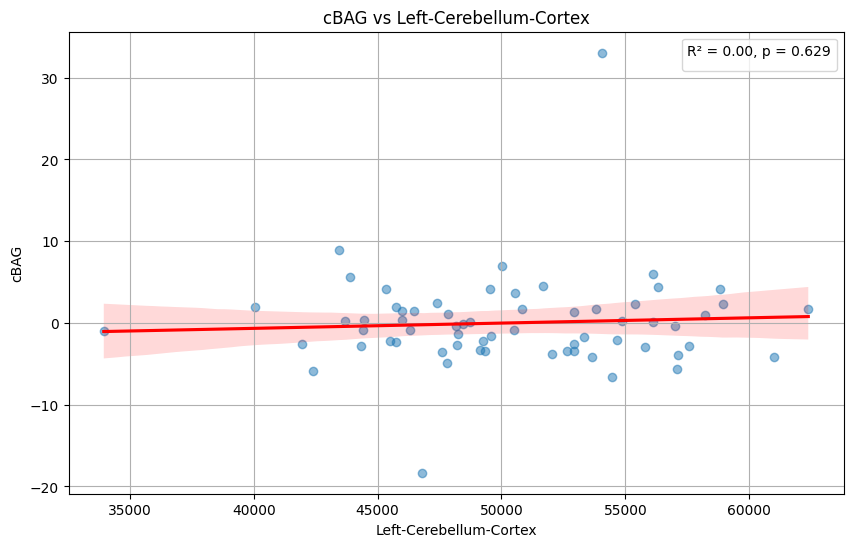

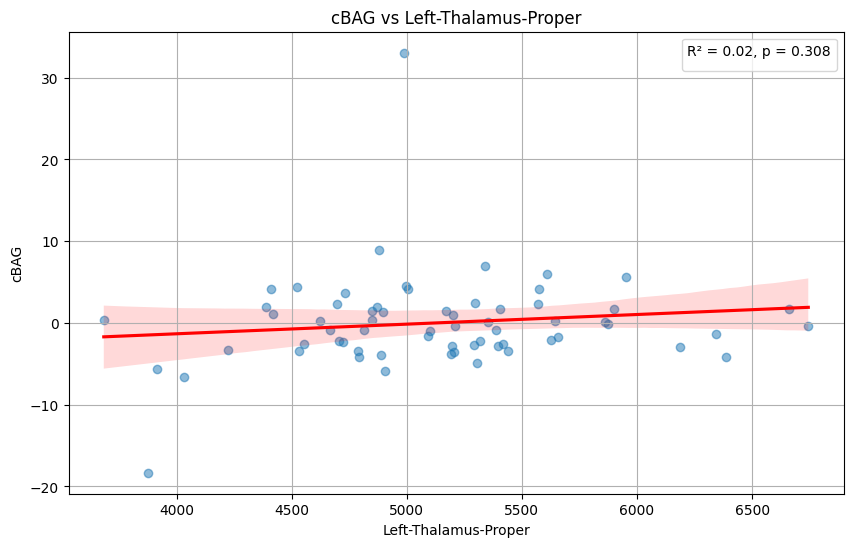

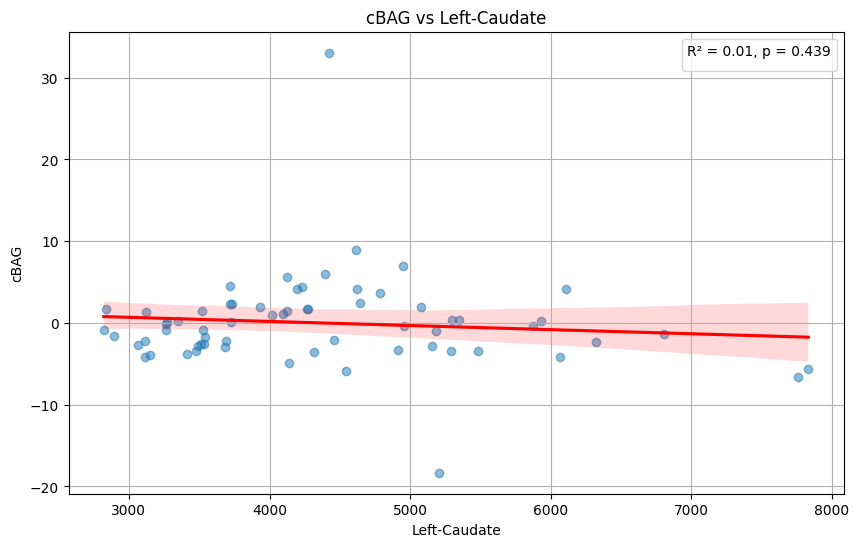

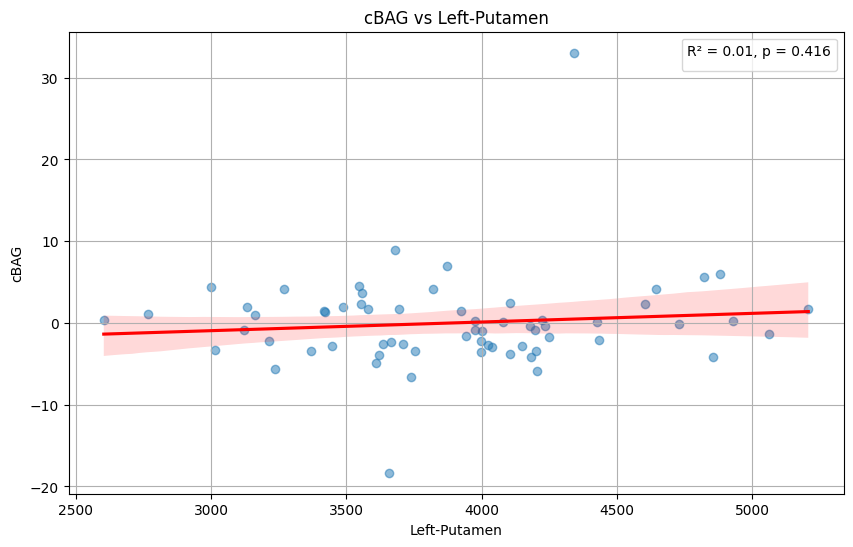

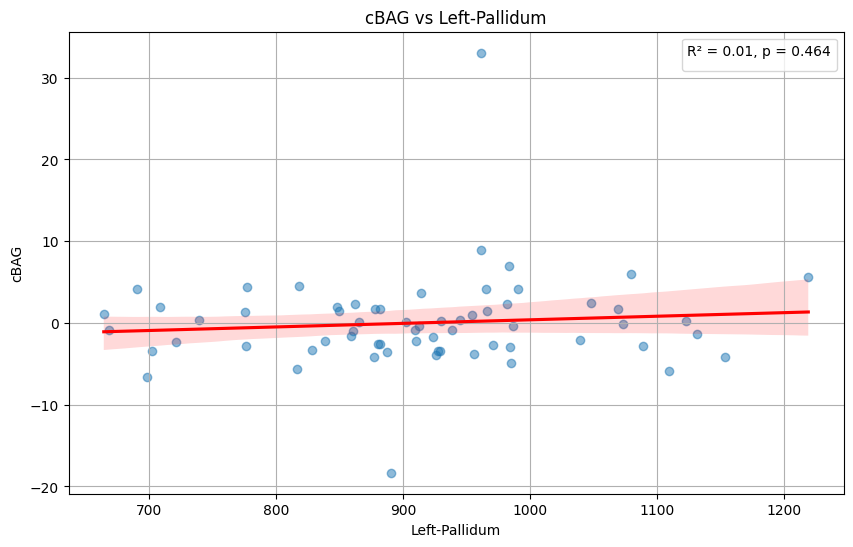

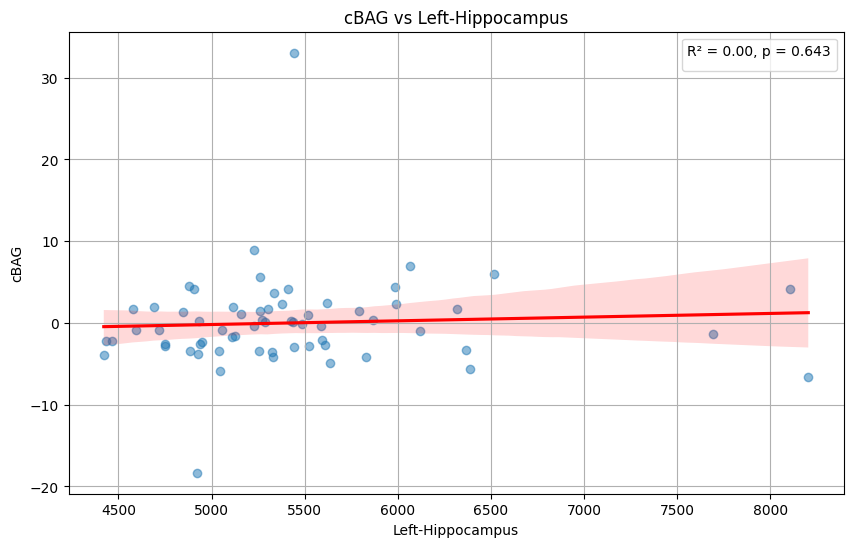

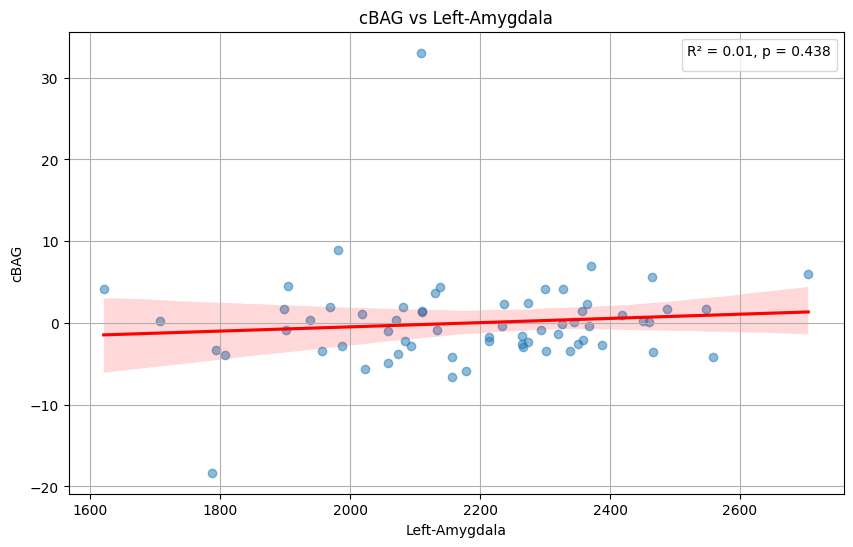

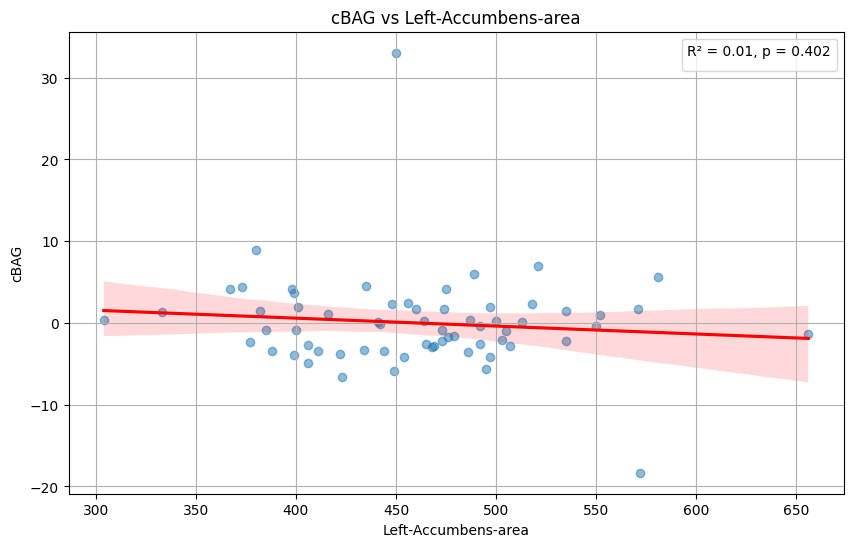

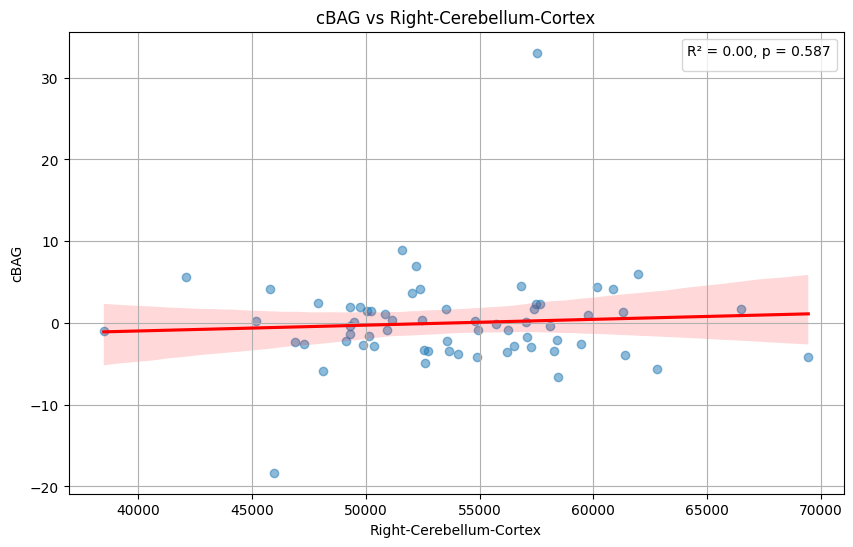

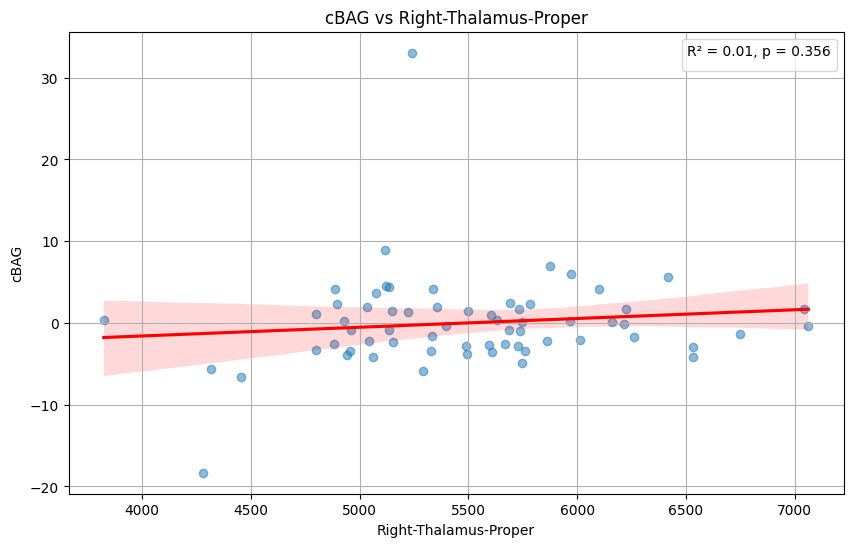

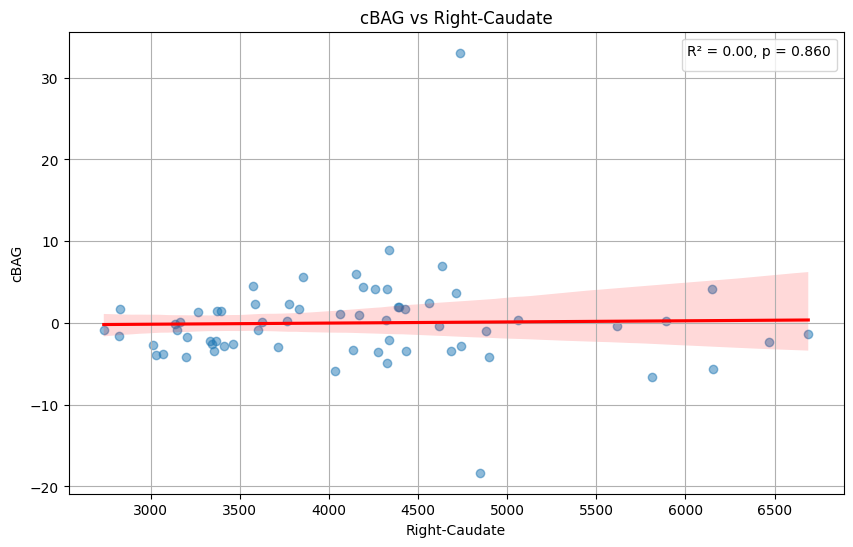

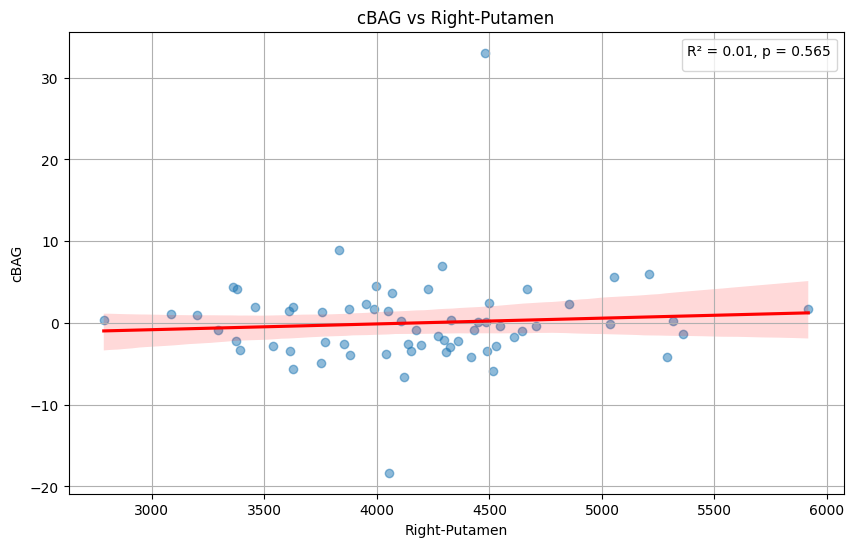

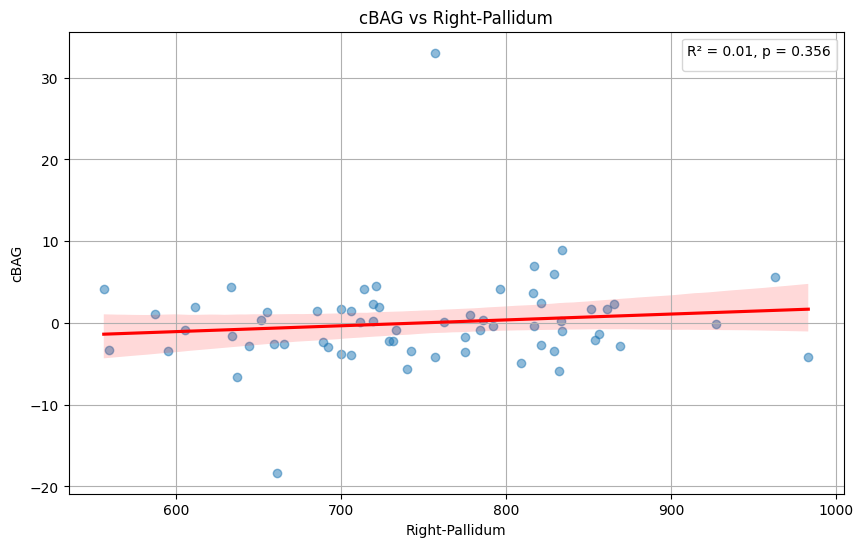

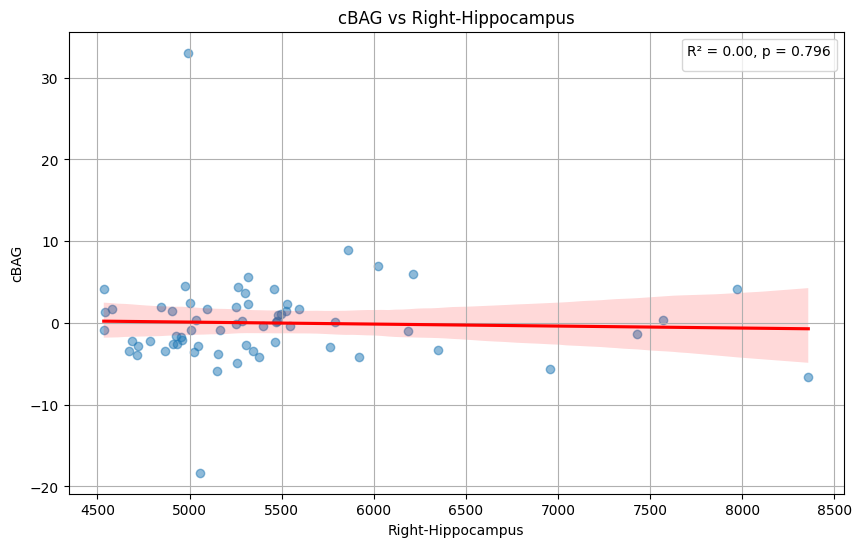

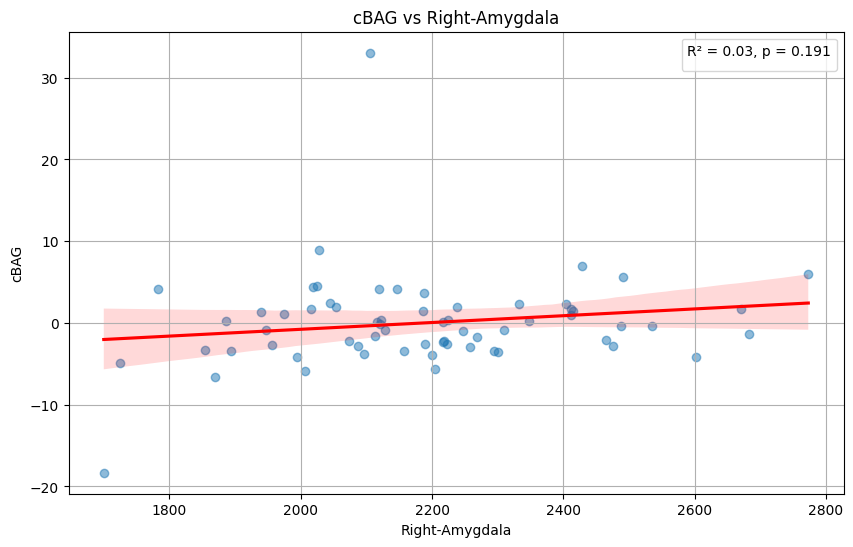

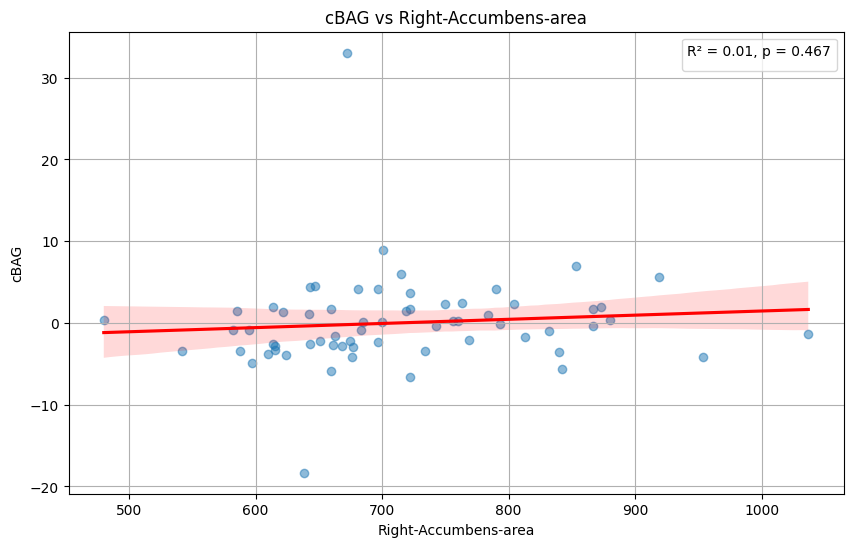

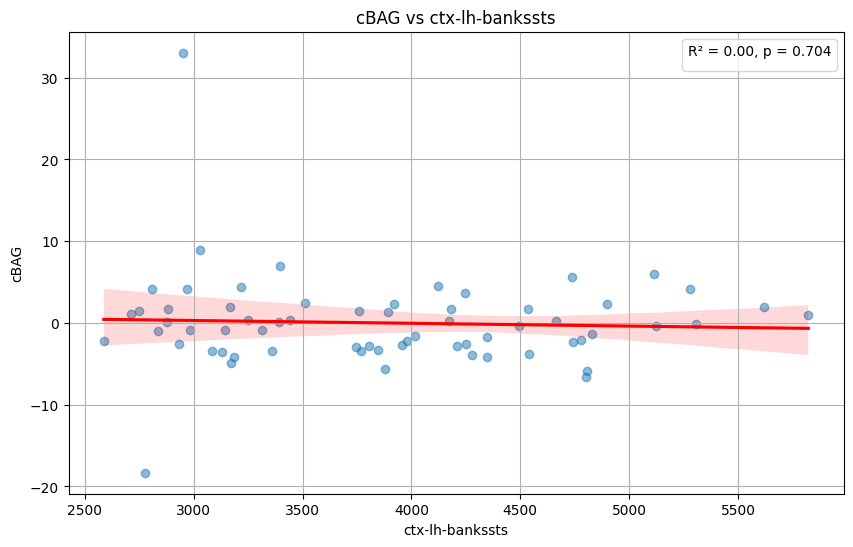

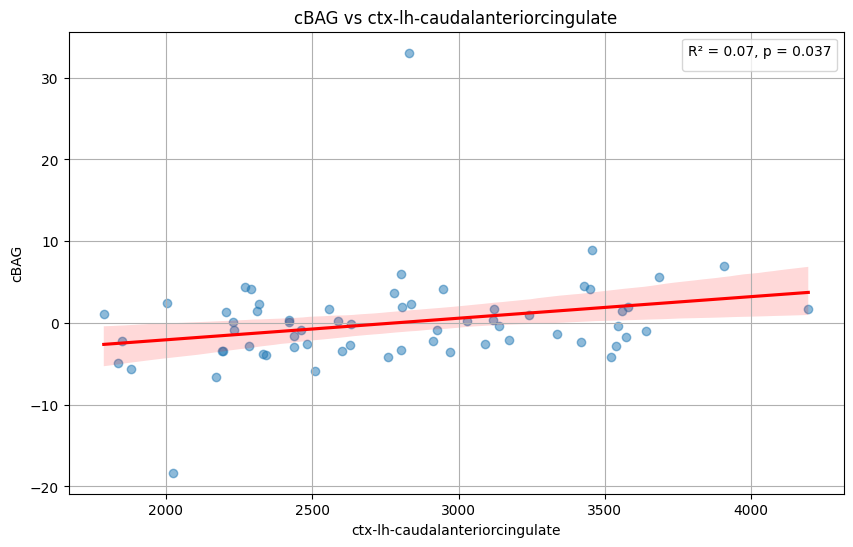

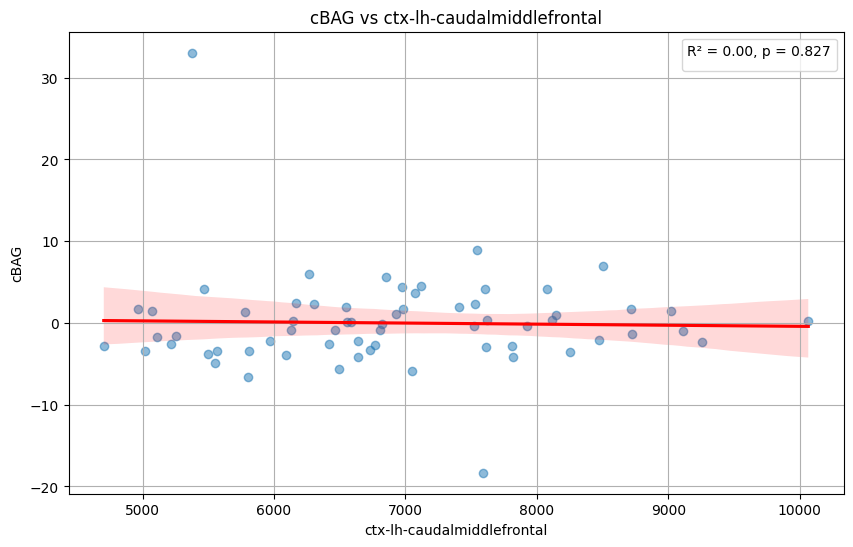

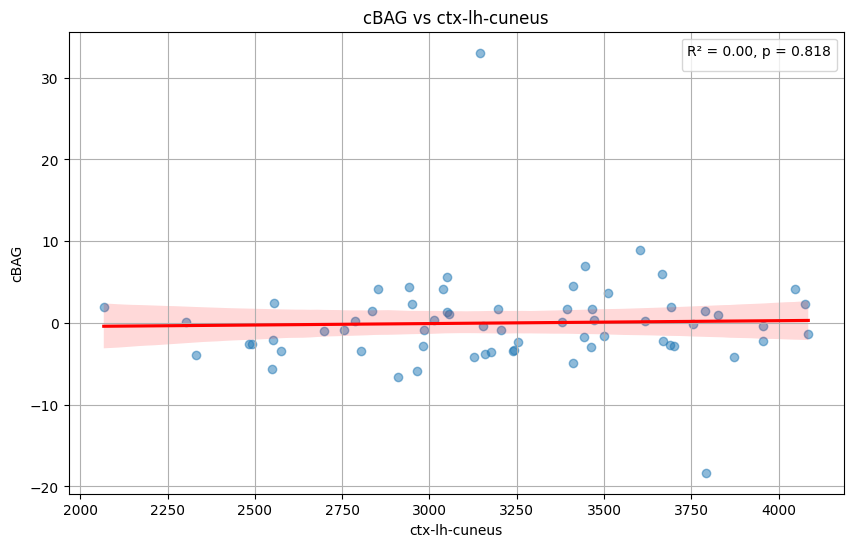

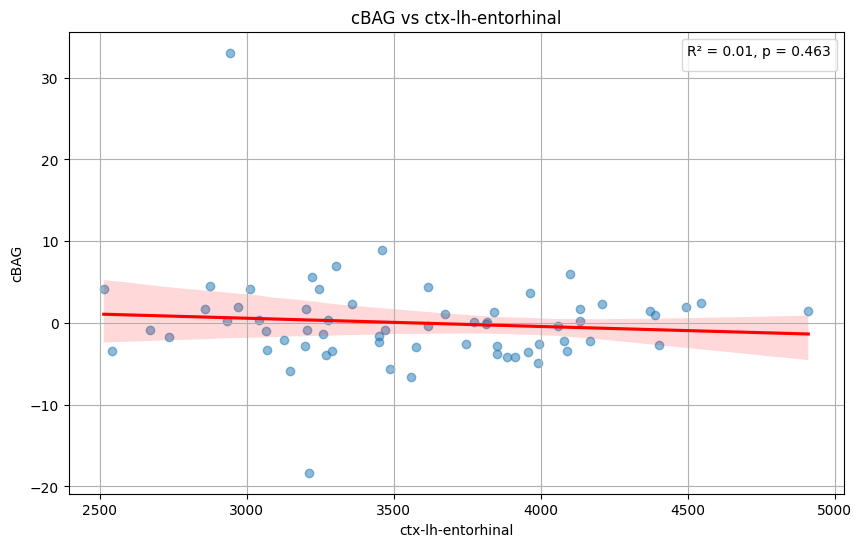

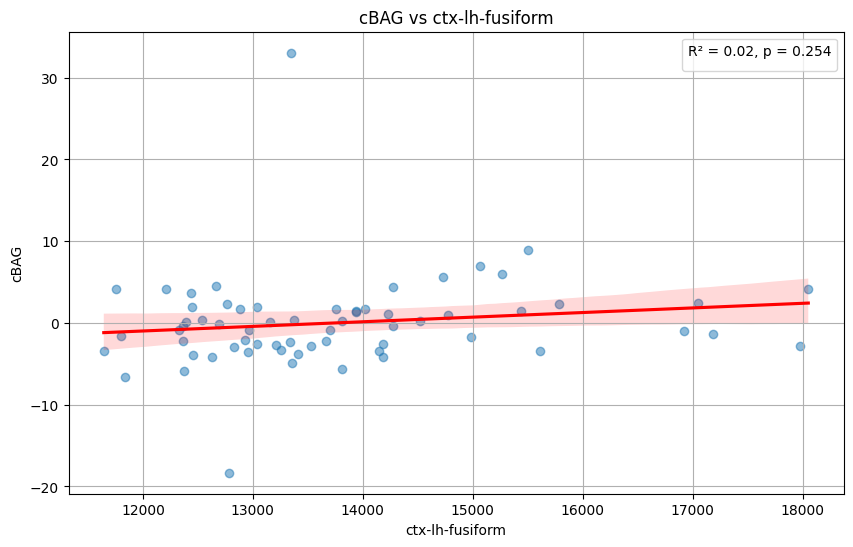

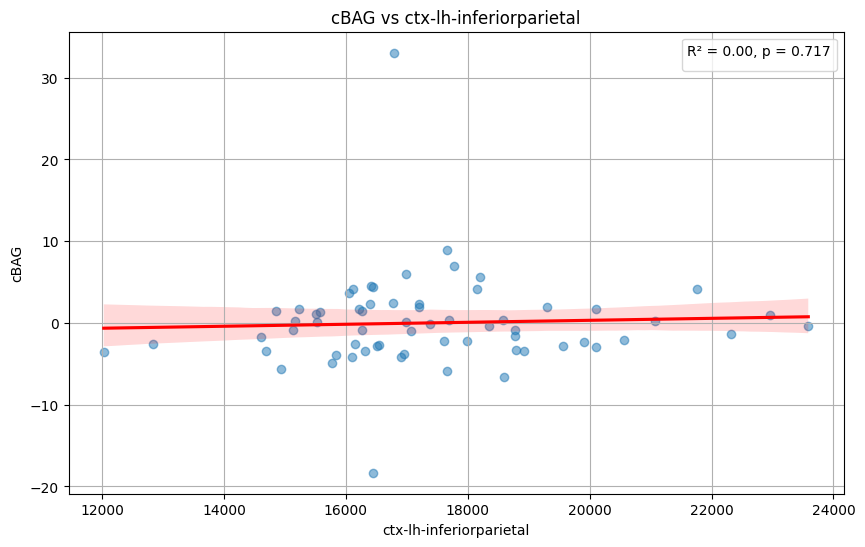

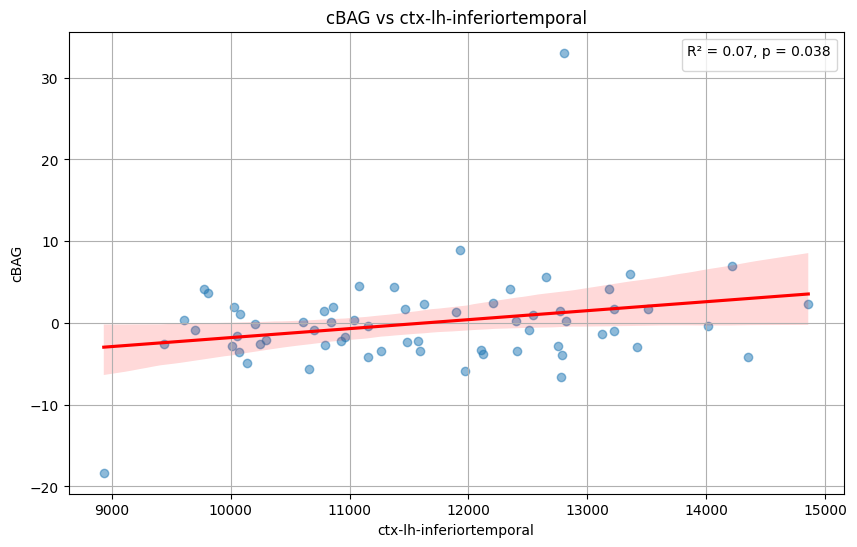

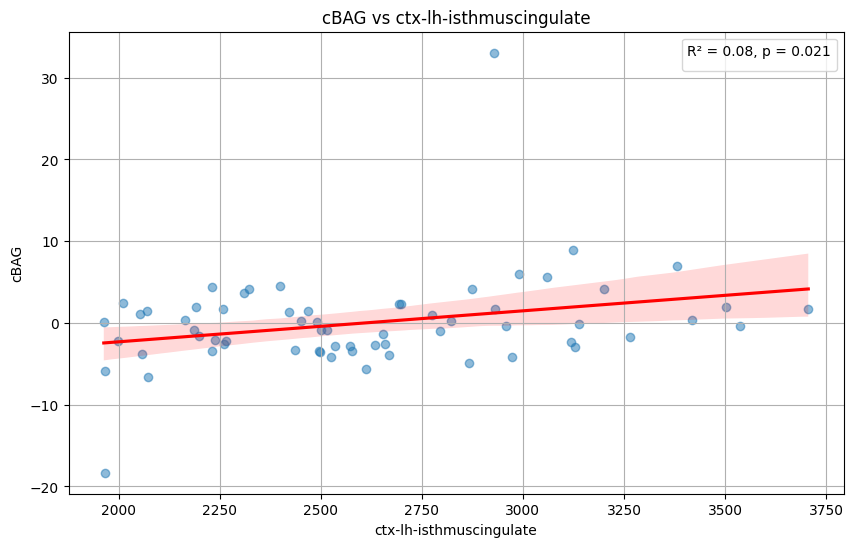

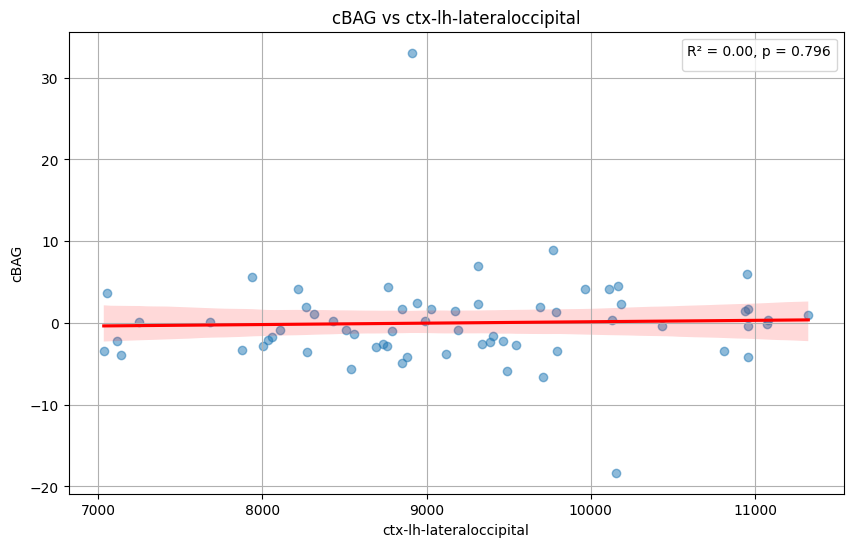

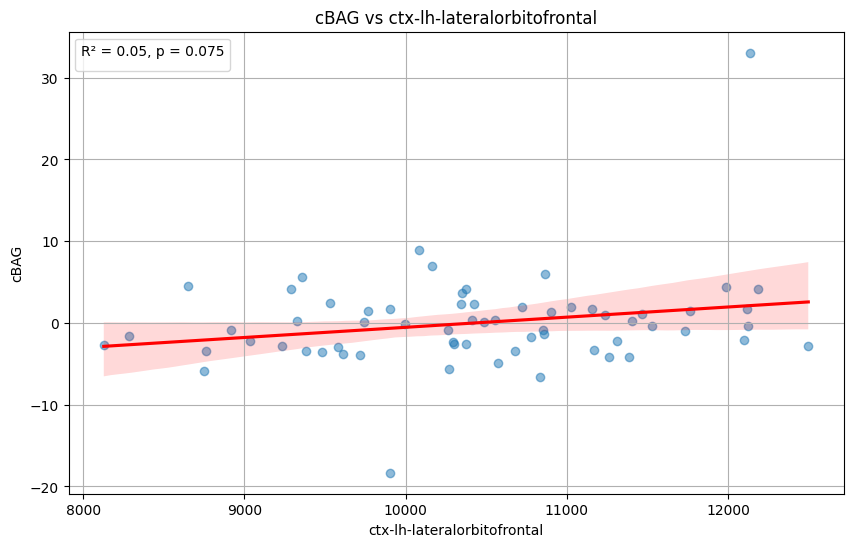

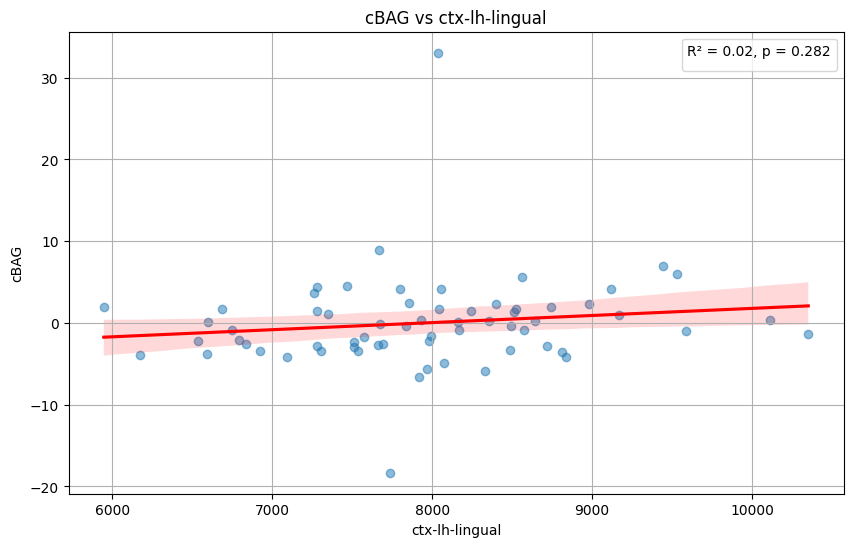

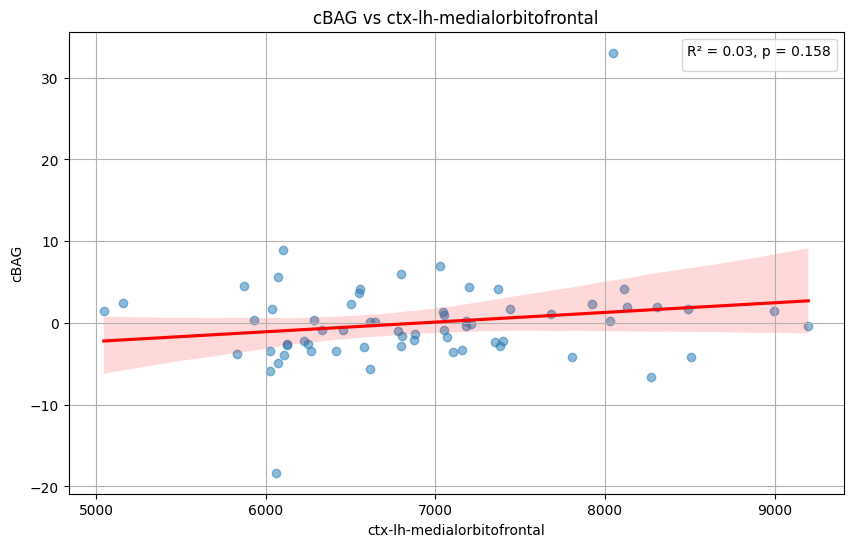

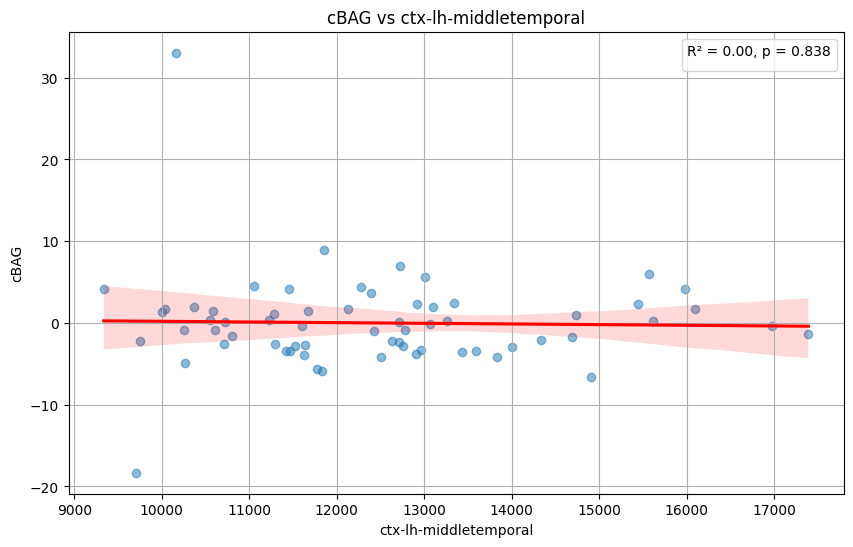

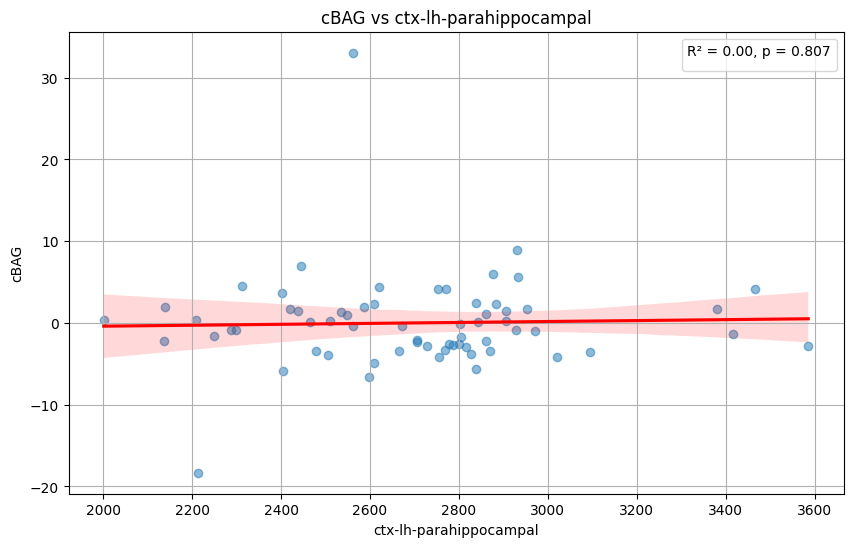

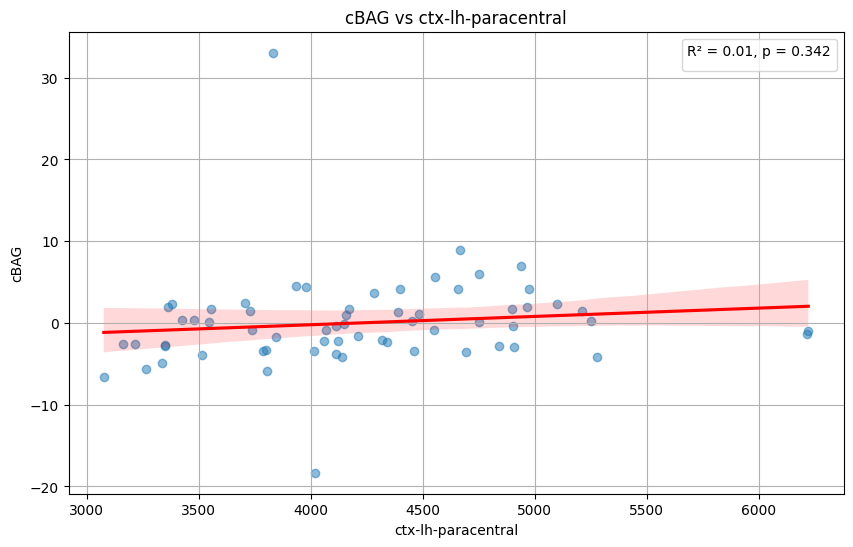

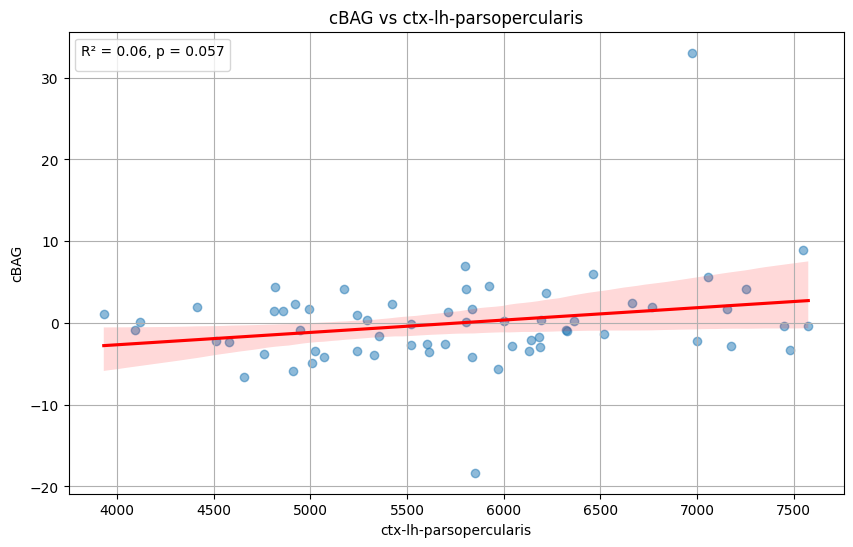

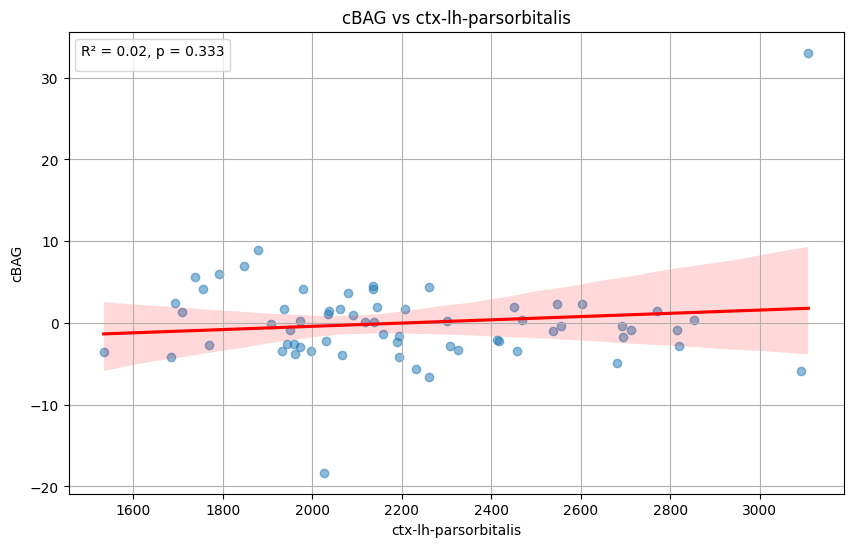

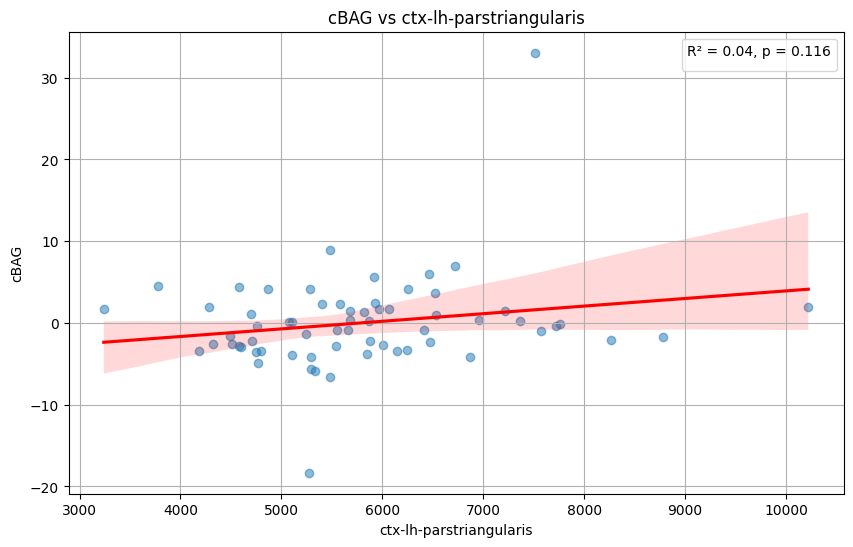

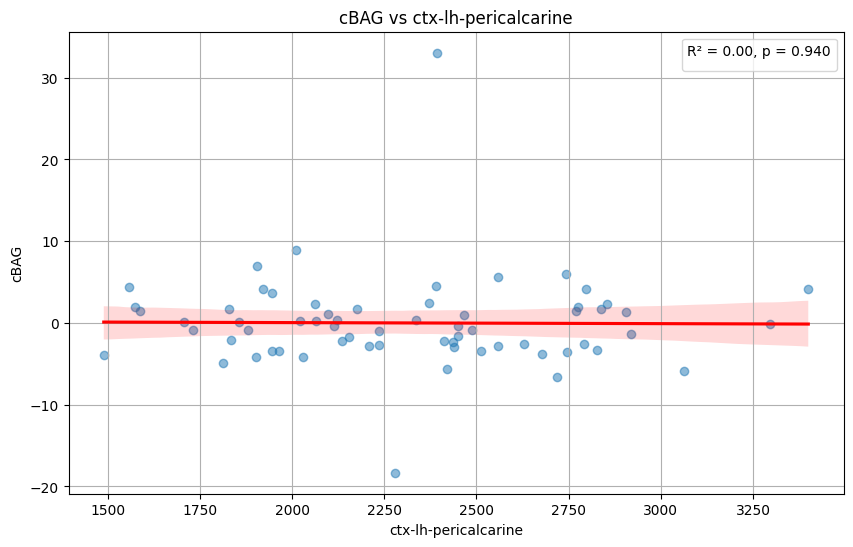

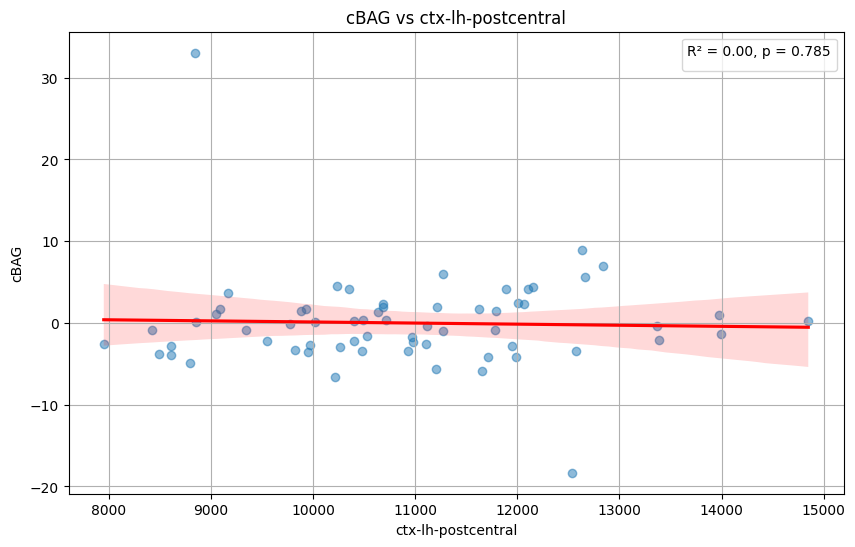

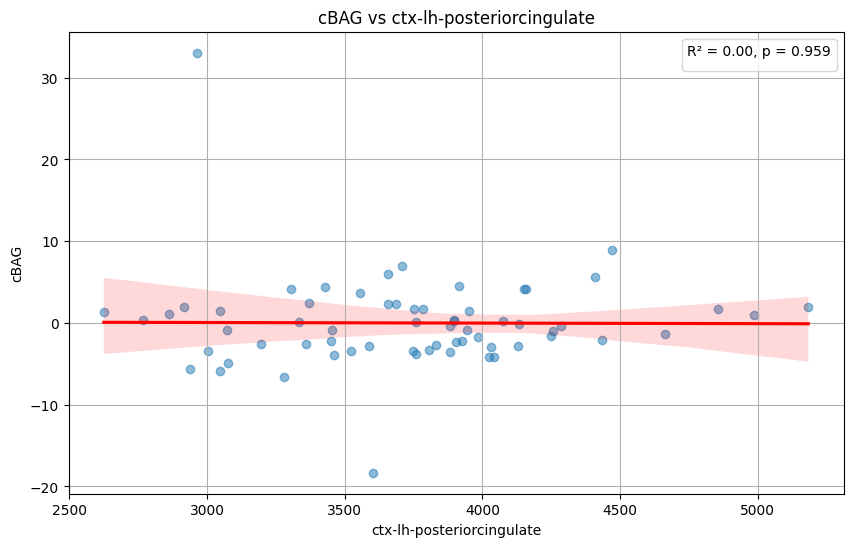

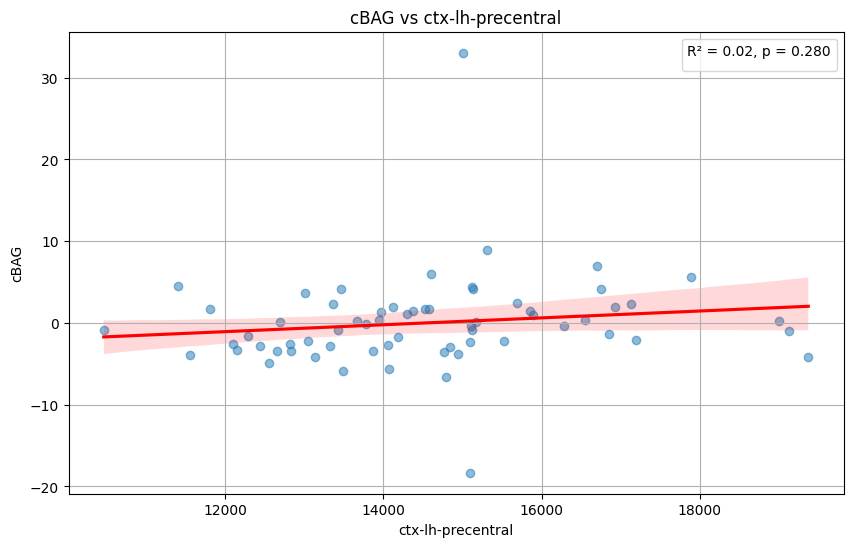

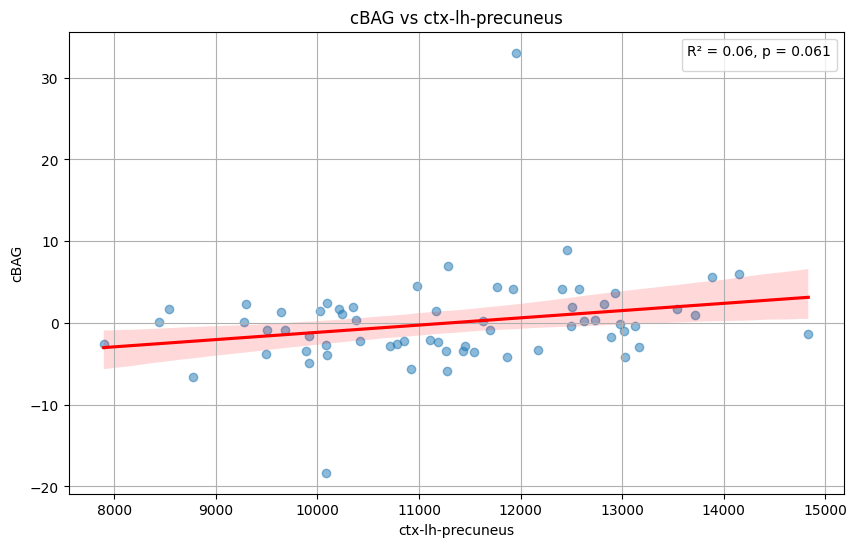

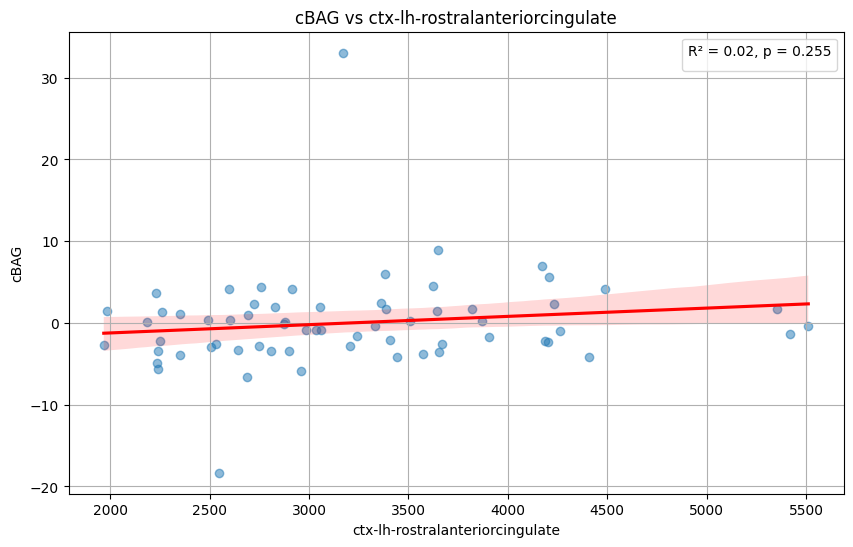

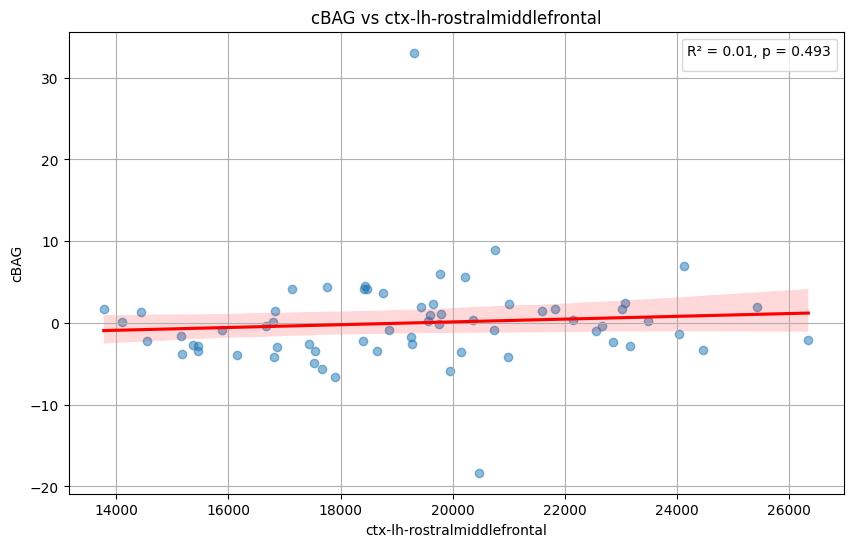

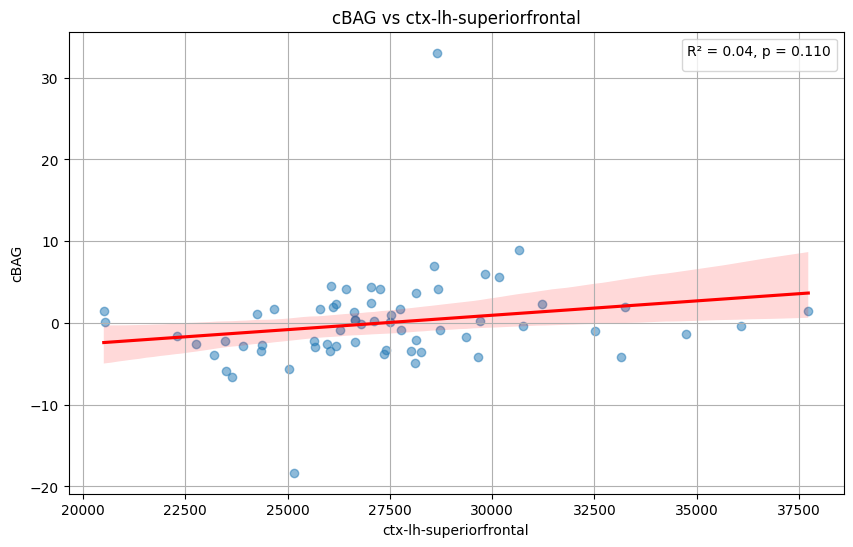

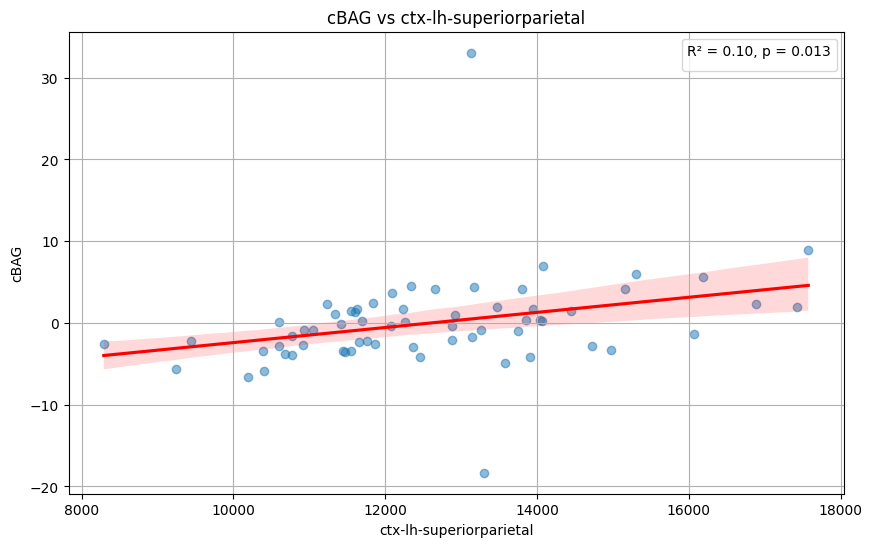

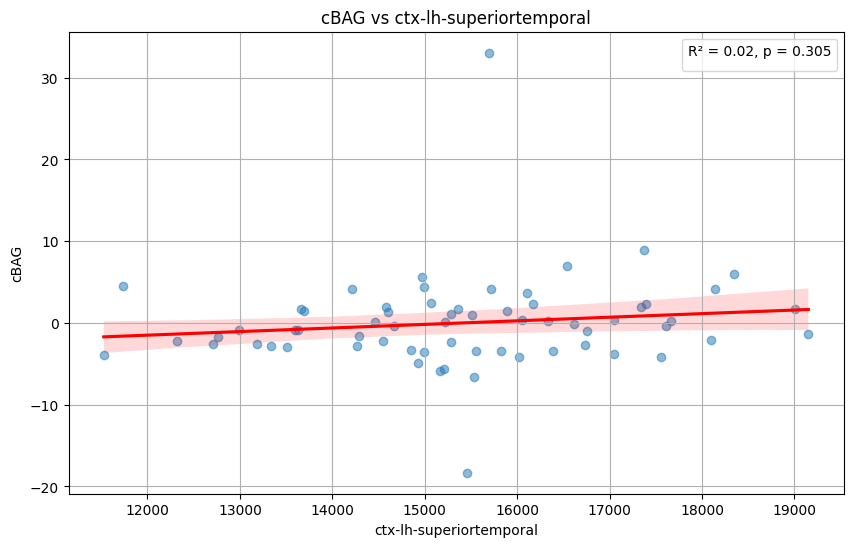

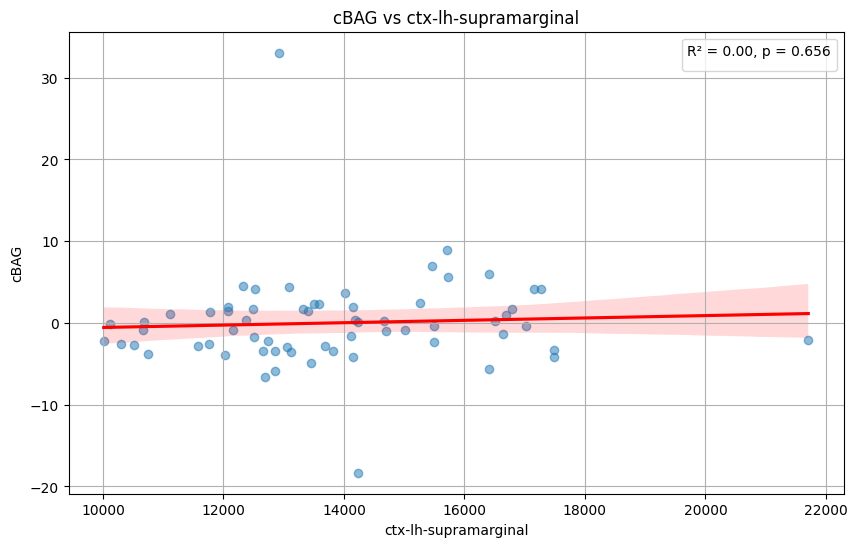

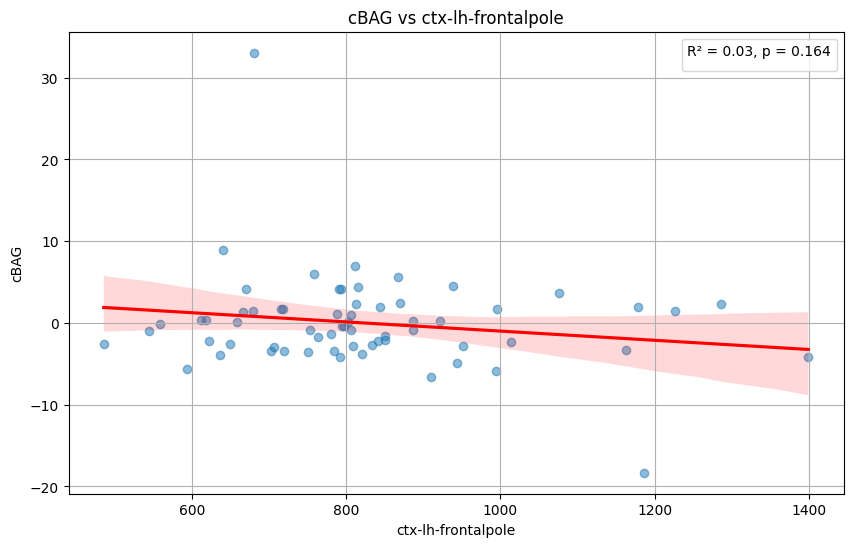

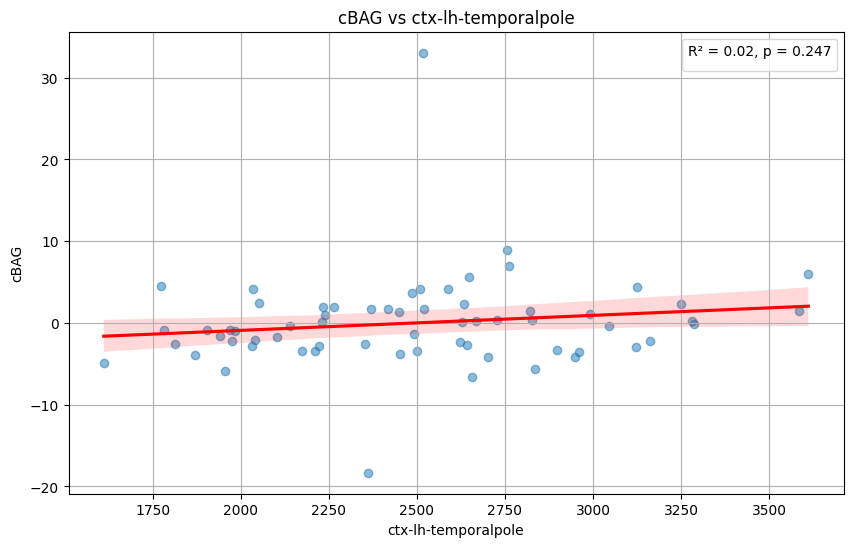

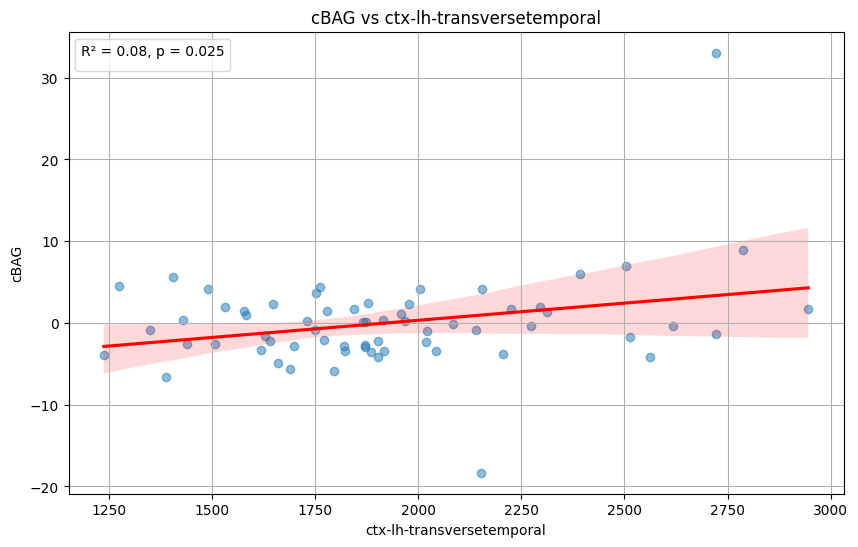

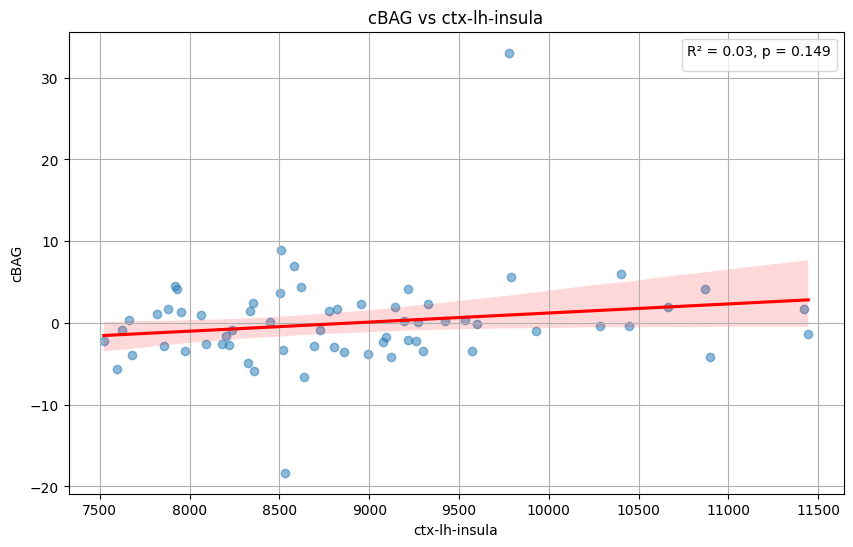

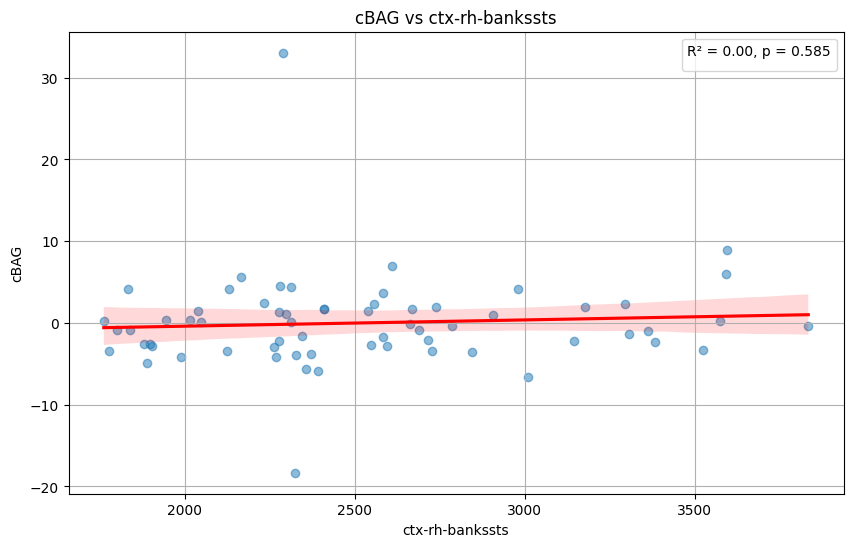

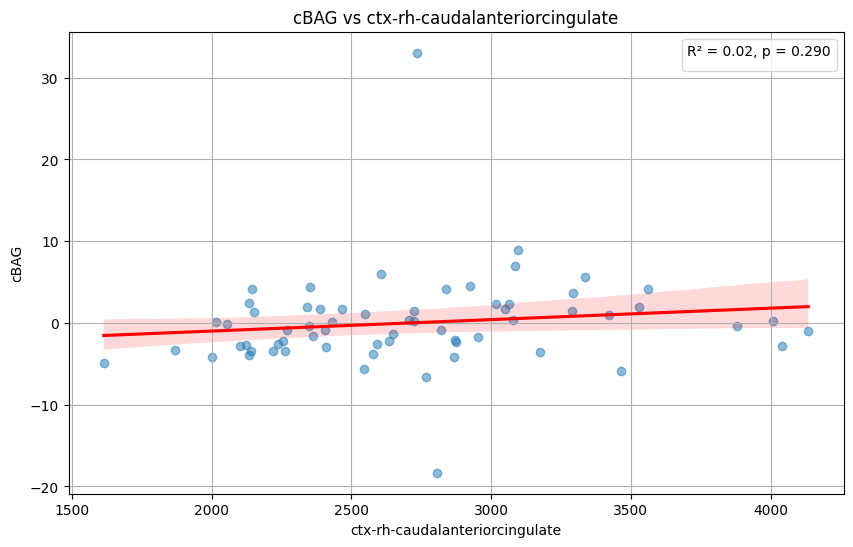

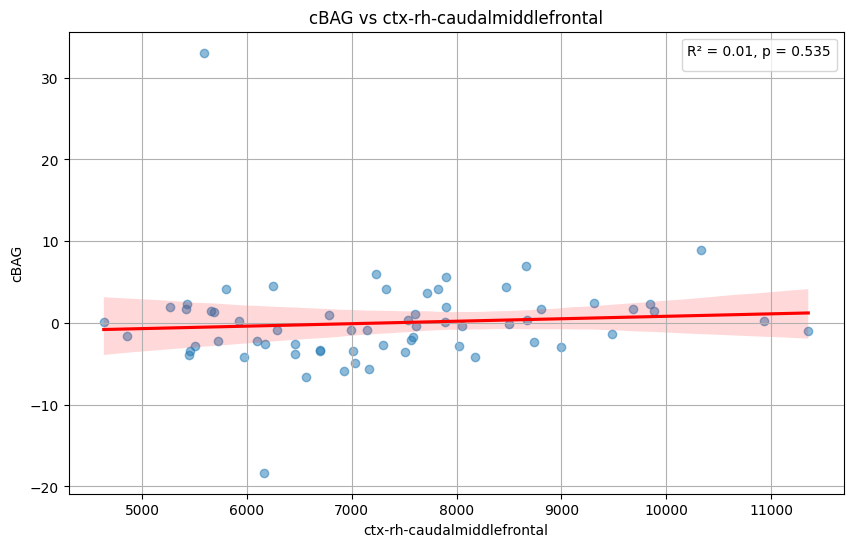

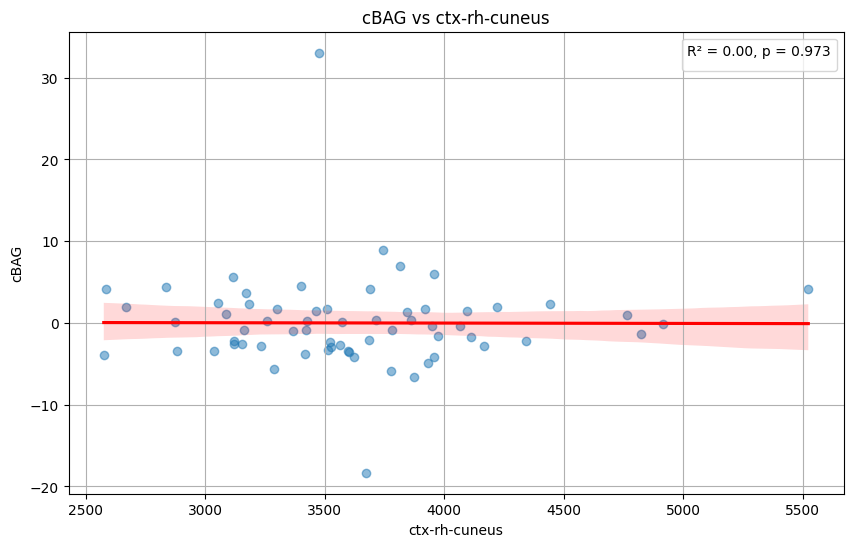

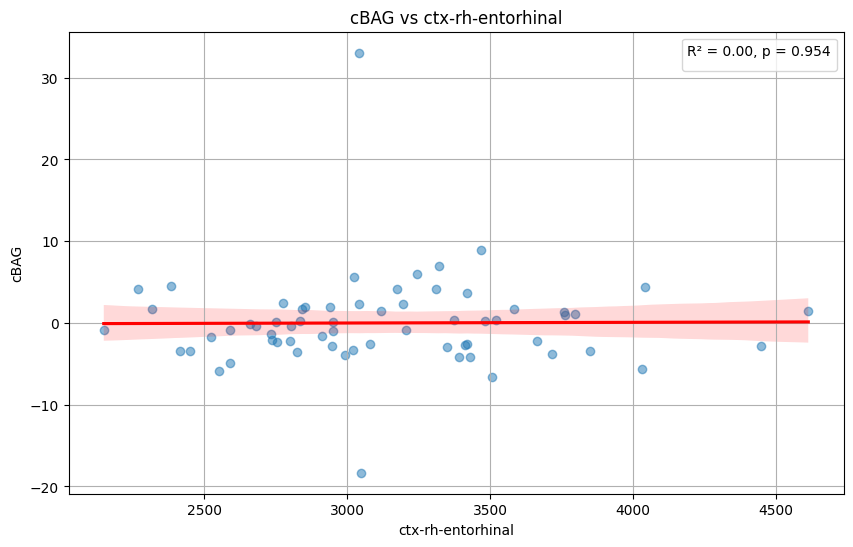

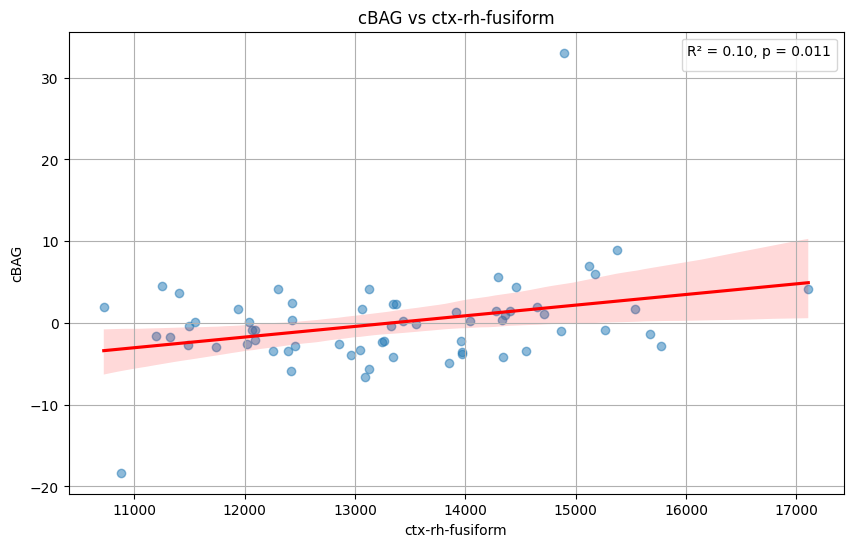

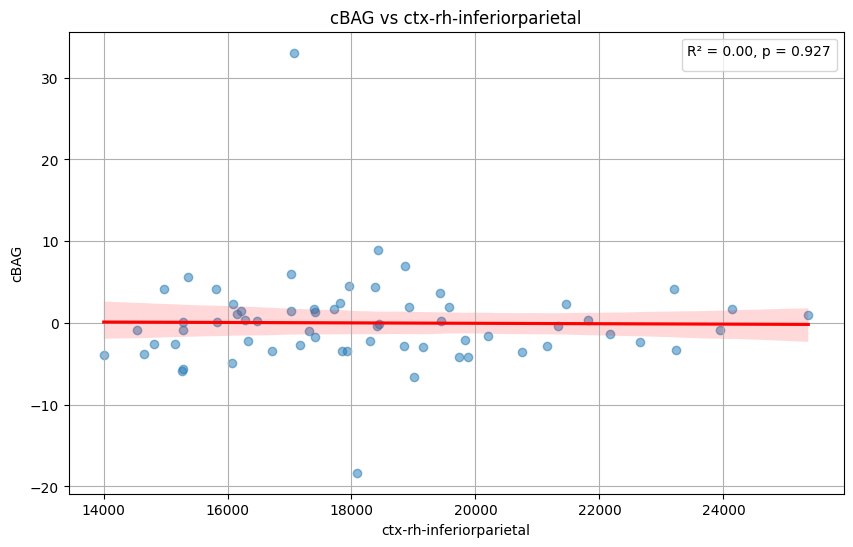

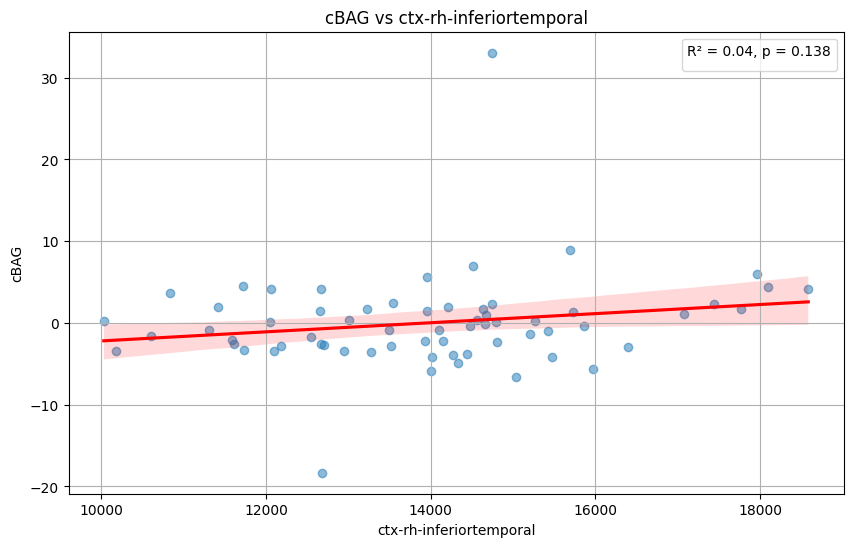

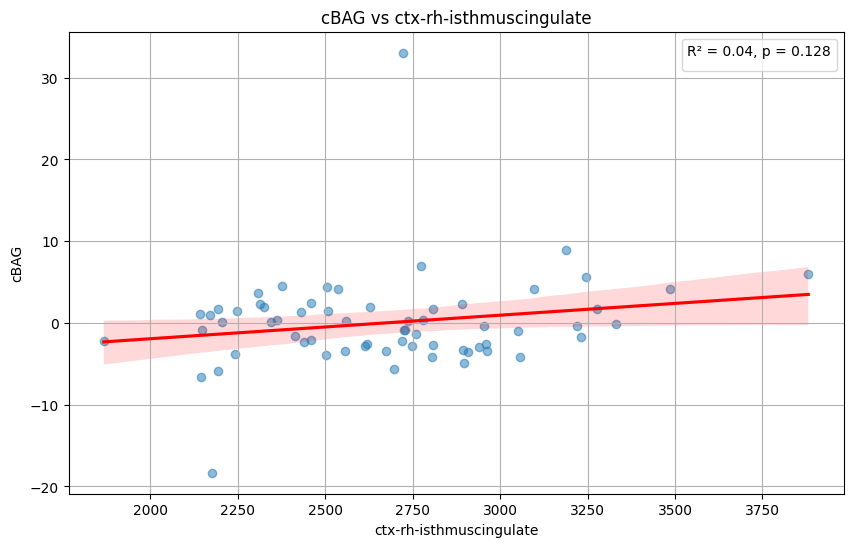

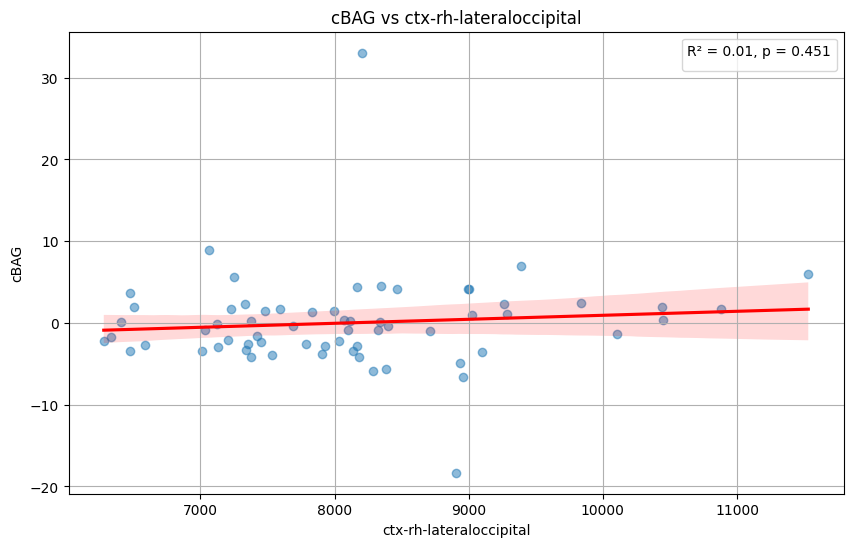

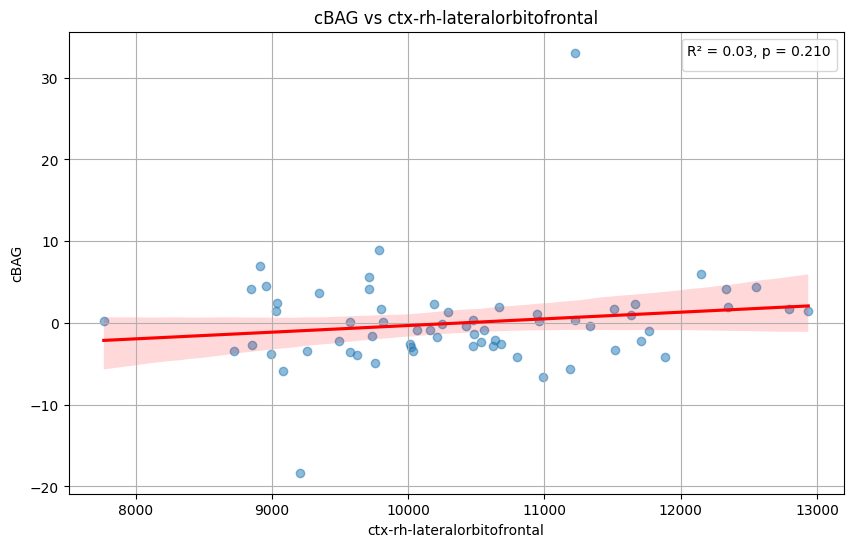

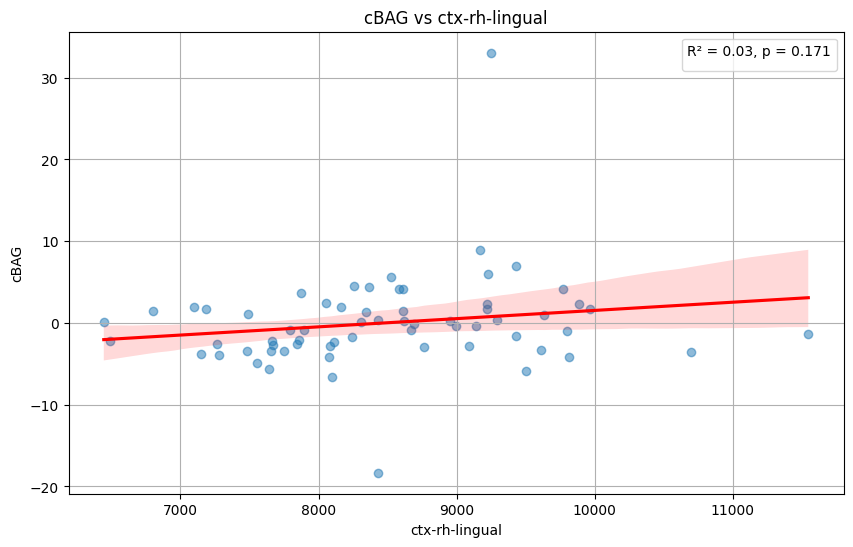

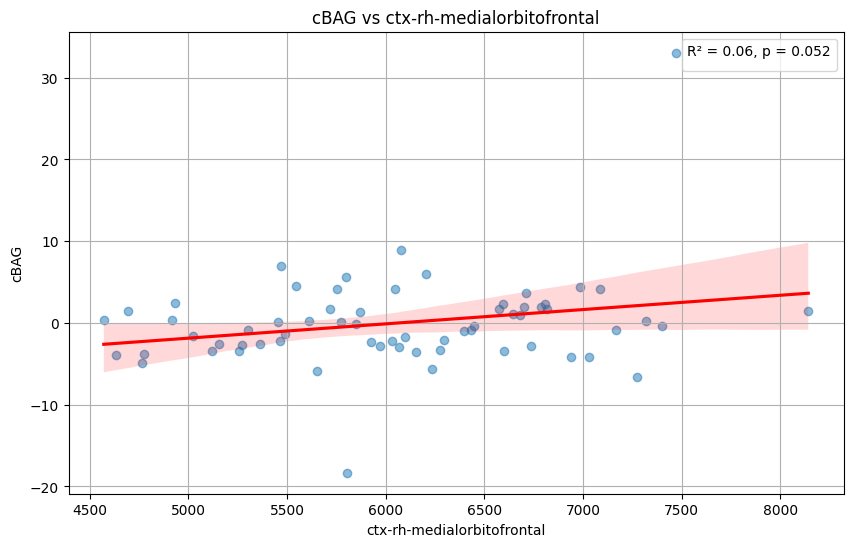

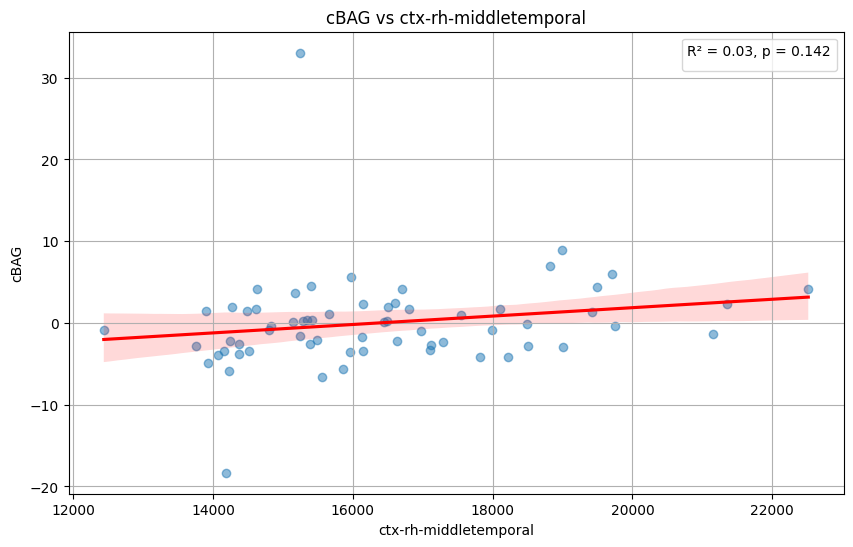

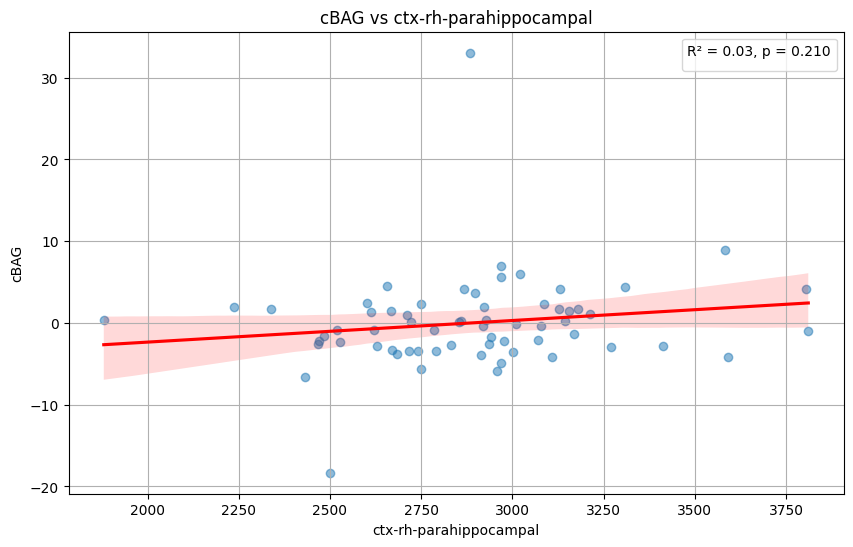

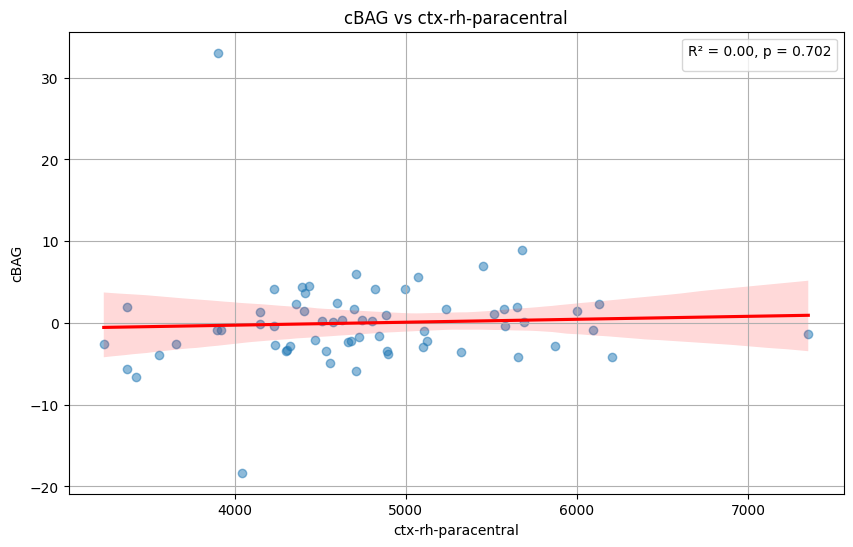

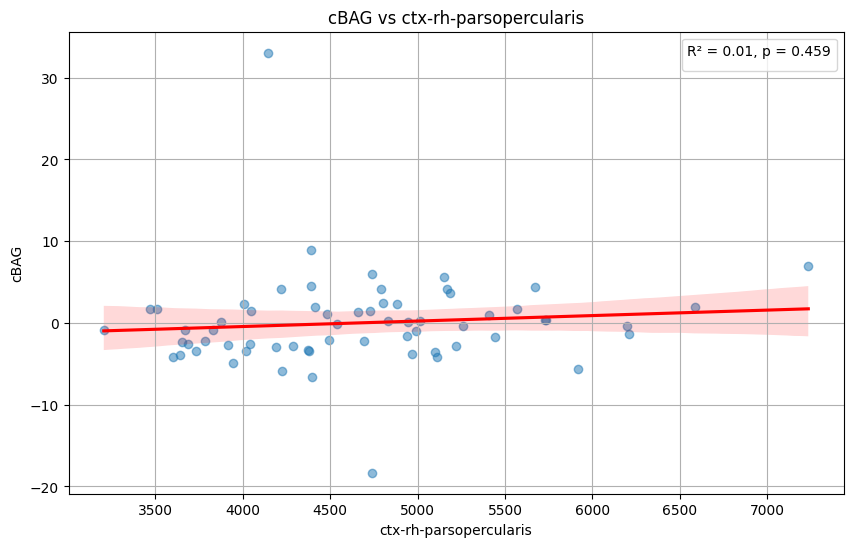

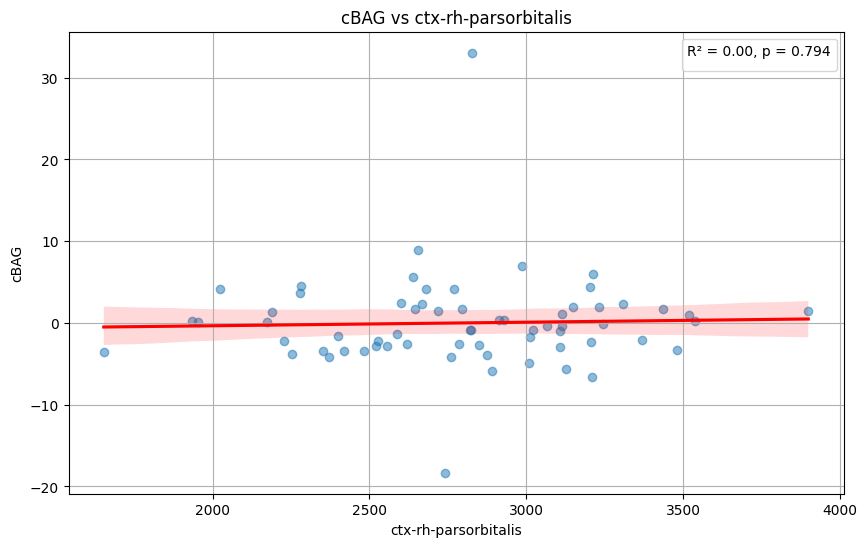

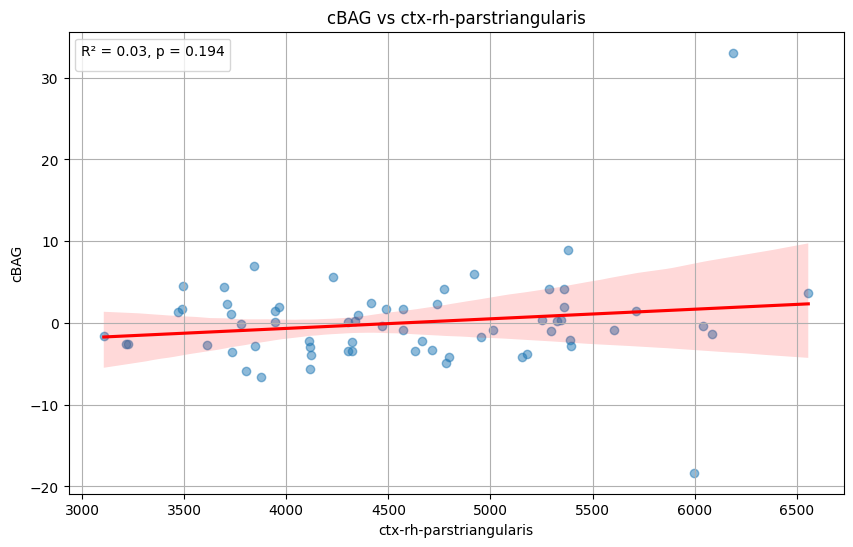

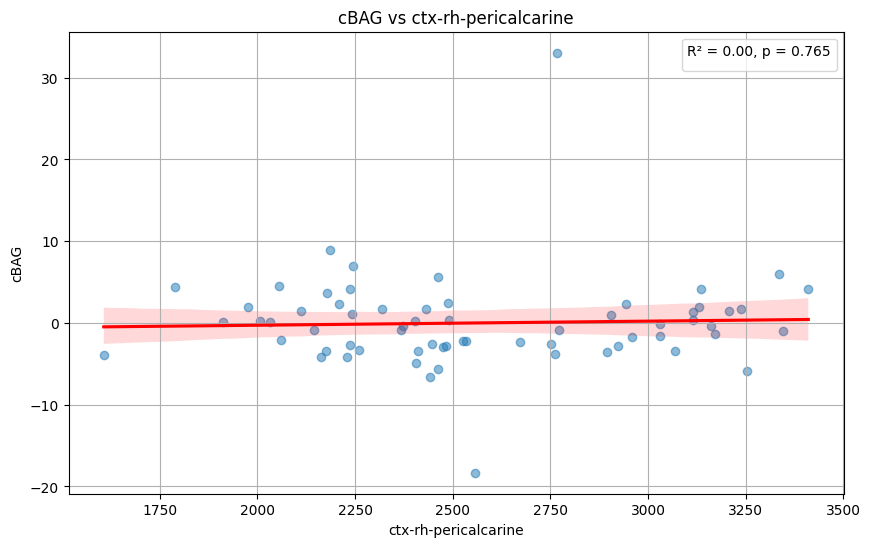

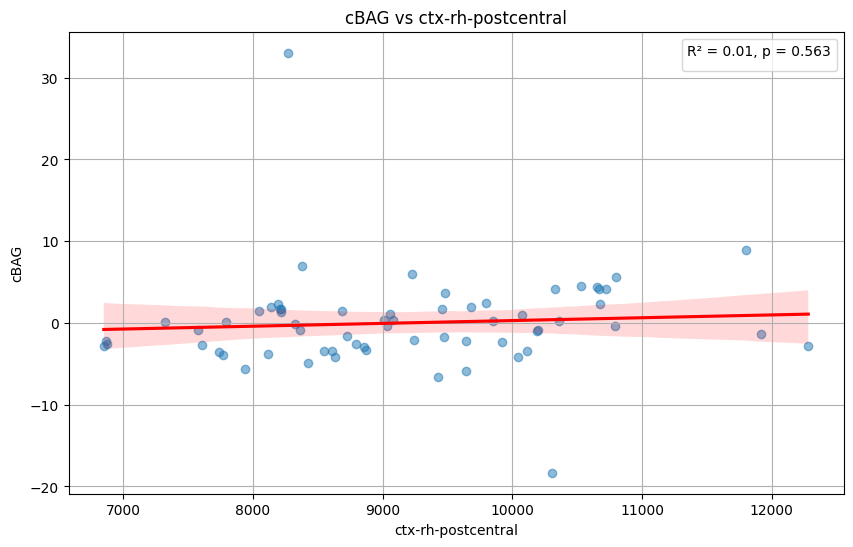

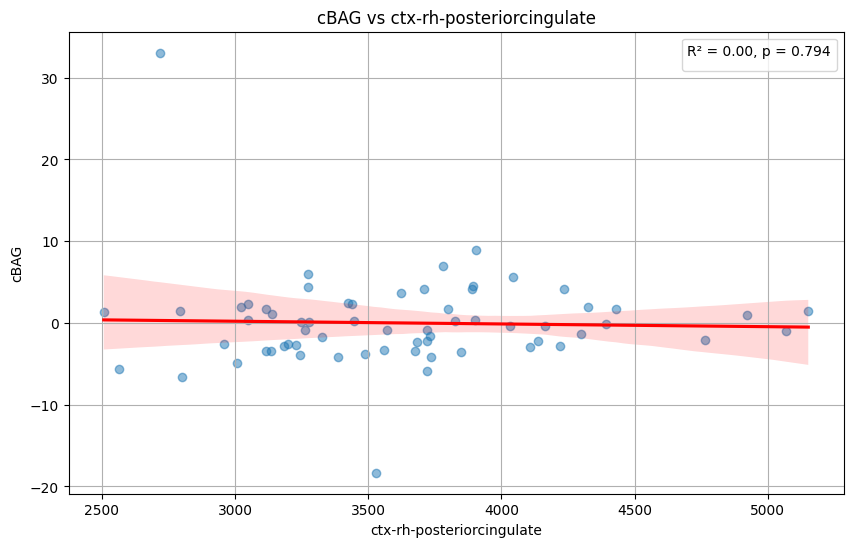

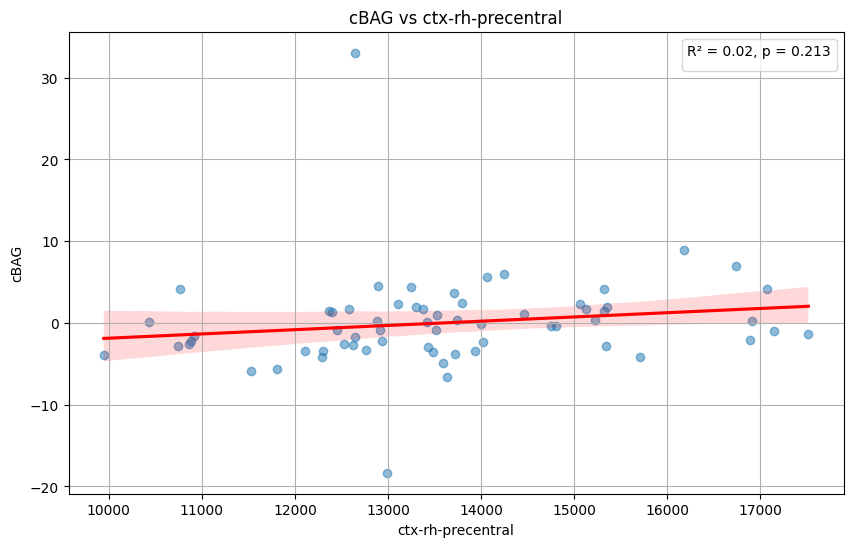

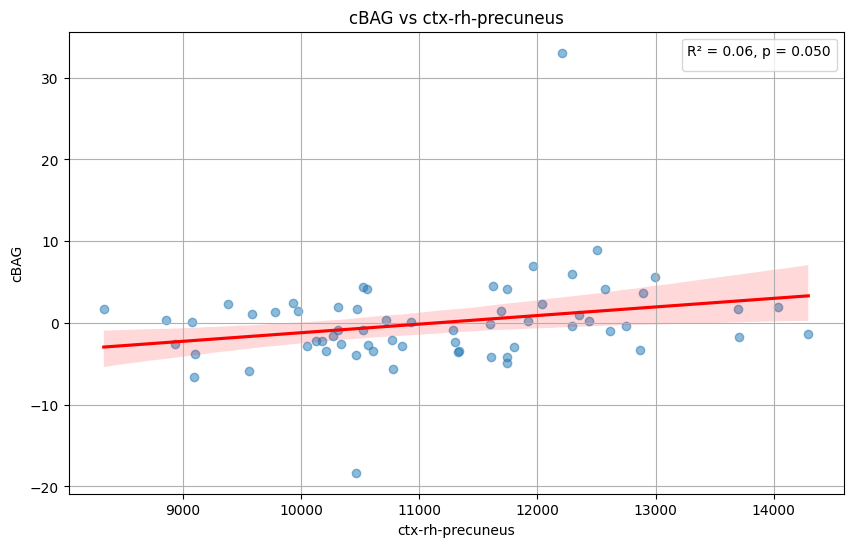

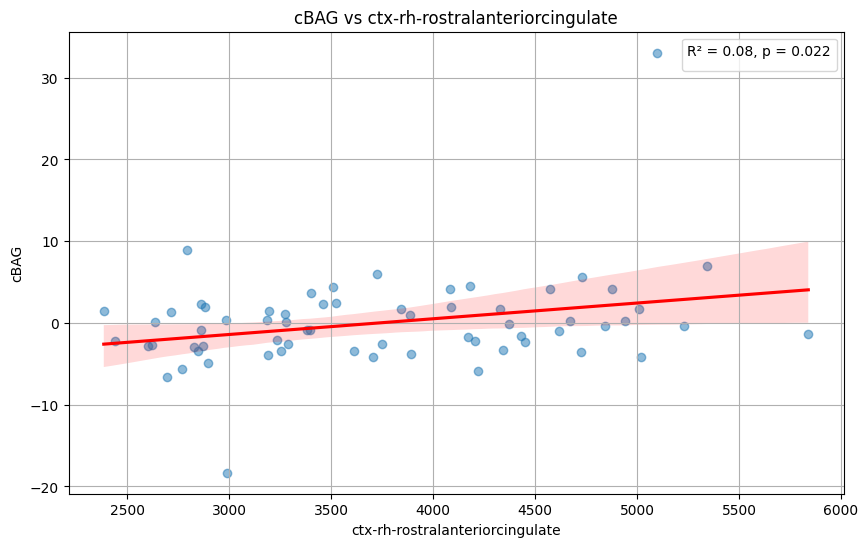

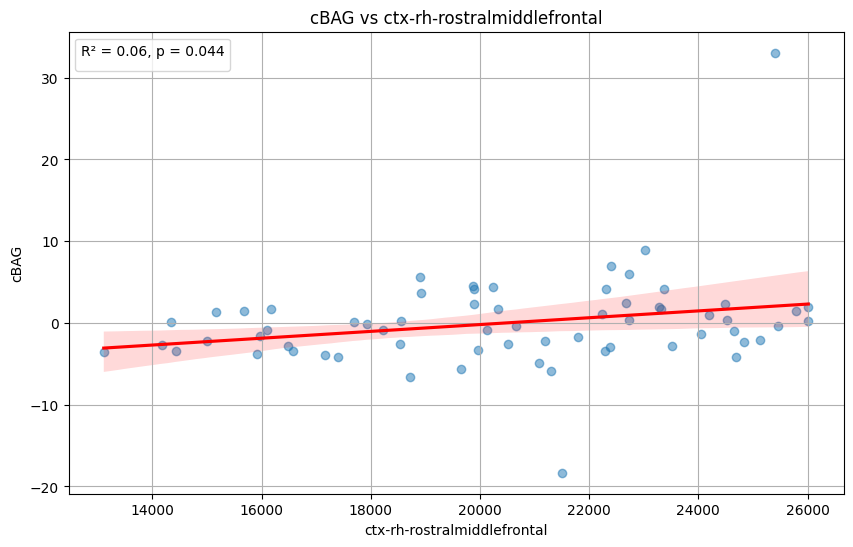

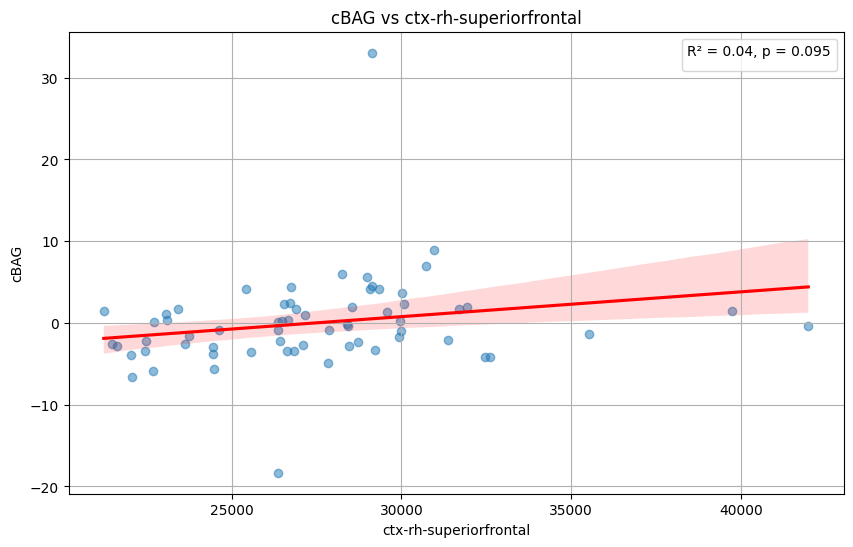

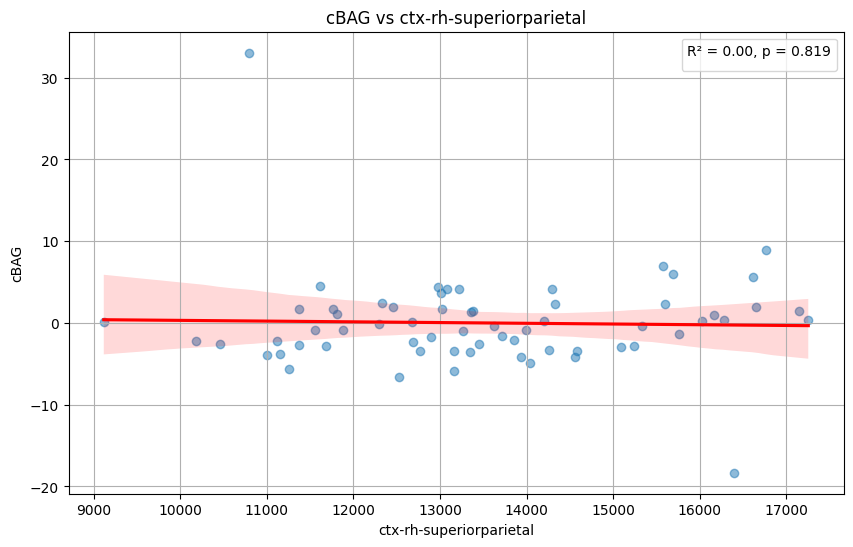

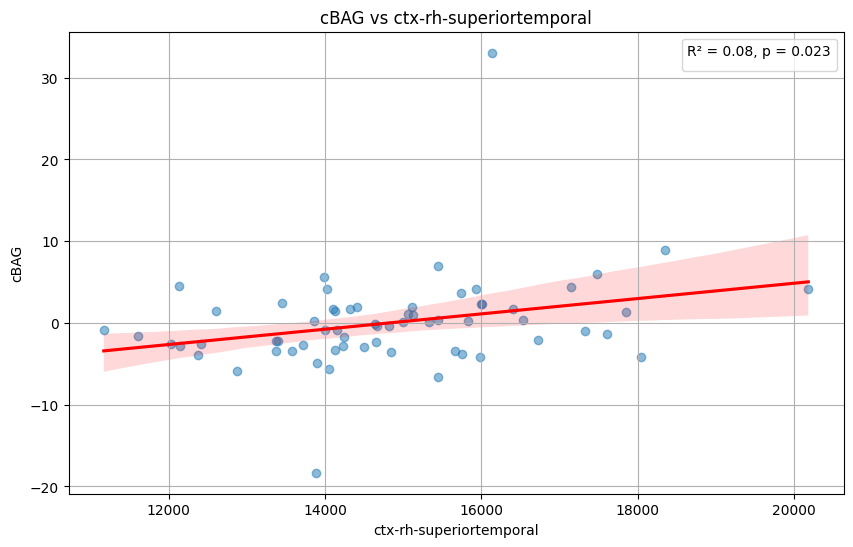

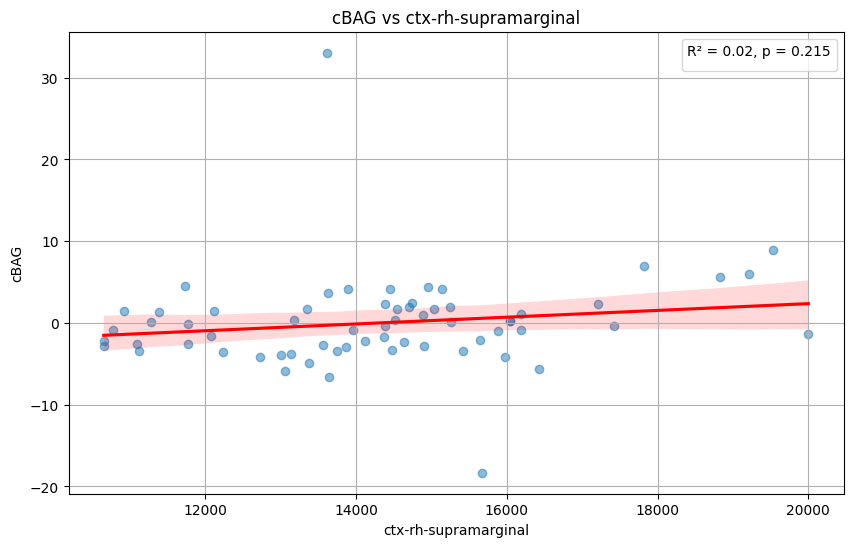

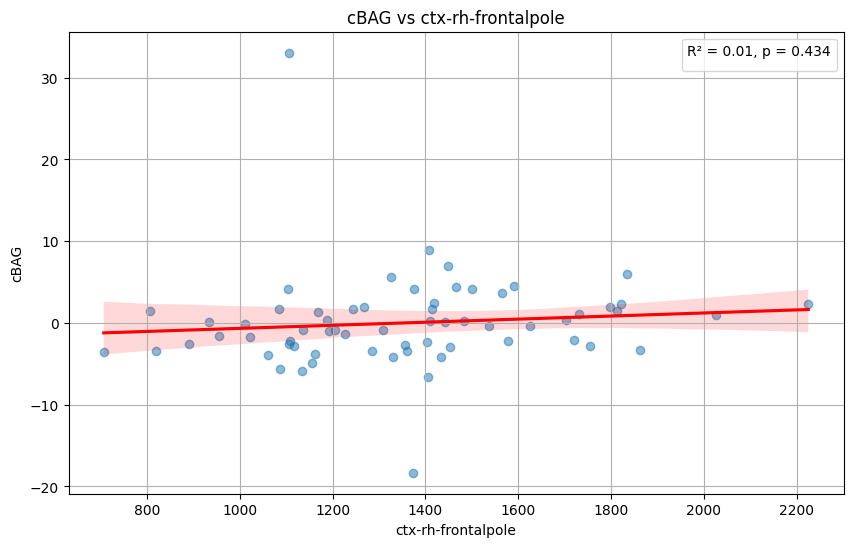

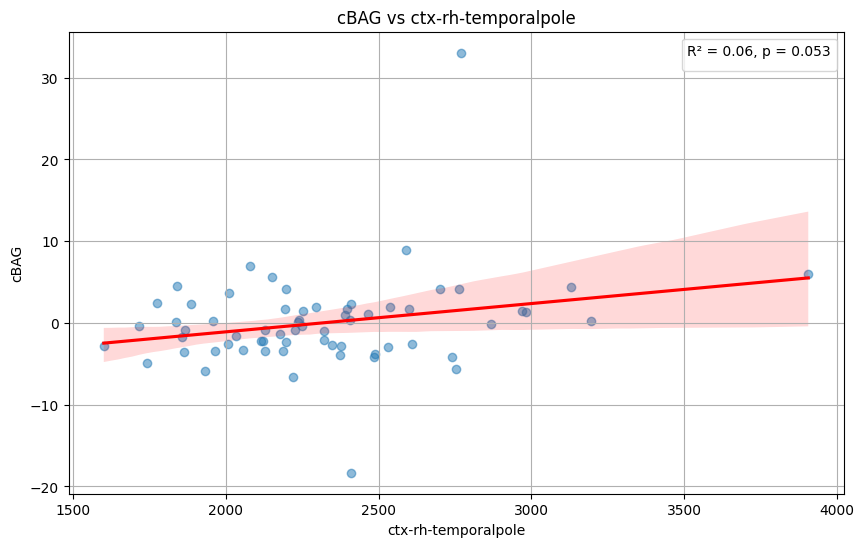

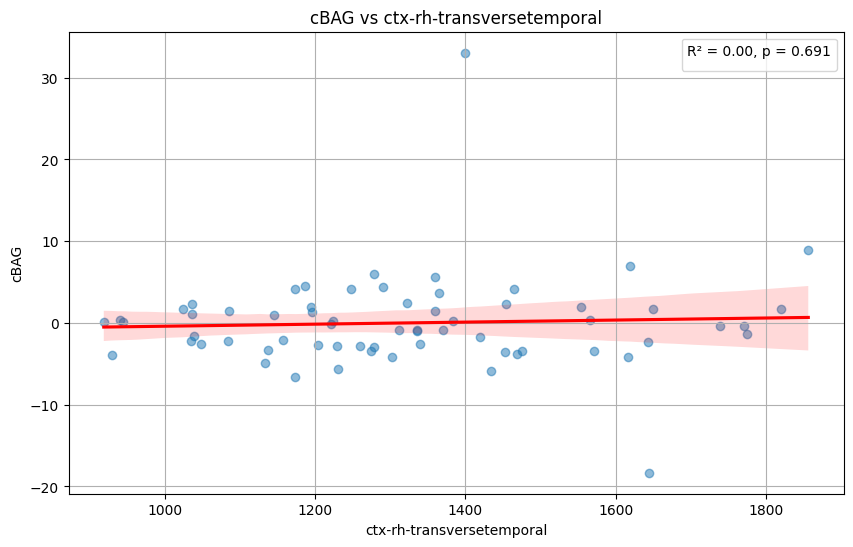

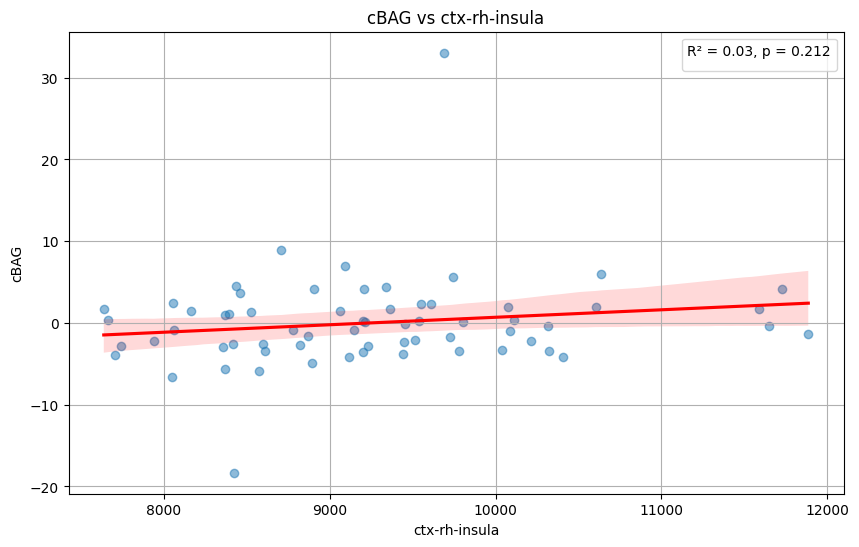

Top 10 volume columns with highest R² values:
                      volume_column        R2   p_value
55                  ctx-rh-fusiform  0.099721  0.011025
43          ctx-lh-superiorparietal  0.095353  0.013041
24          ctx-lh-isthmuscingulate  0.082845  0.021095
74  ctx-rh-rostralanteriorcingulate  0.081188  0.022484
78          ctx-rh-superiortemporal  0.081092  0.022568
48        ctx-lh-transversetemporal  0.078843  0.024610
17   ctx-lh-caudalanteriorcingulate  0.068521  0.036669
23          ctx-lh-inferiortemporal  0.067636  0.037948
75      ctx-rh-rostralmiddlefrontal  0.063621  0.044355
73                 ctx-rh-precuneus  0.060406  0.050277

Top 10 volume columns with lowest p-values:
                      volume_column        R2   p_value
55                  ctx-rh-fusiform  0.099721  0.011025
43          ctx-lh-superiorparietal  0.095353  0.013041
24          ctx-lh-isthmuscingulate  0.082845  0.021095
74  ctx-rh-rostralanteriorcingulate  0.081188  0.022484
78          c

In [10]:
# Plot the BAG vs. volume for each region with regression line, R2, and p-value
# Convert all volume columns to numeric, coercing errors to NaN
for col in df_vol_clean.columns:
    df_vol_clean[col] = pd.to_numeric(df_vol_clean[col], errors='coerce')
R2 = []
p_values = []

# Match the subject_id in df_vol_clean with the subject_id in merged_df
merged_df['subject_id'] = merged_df['subject_id'].astype(str)
# Reset index to make 'subject_id' a column for merging
merged_vol_df = pd.merge(df_vol_clean, merged_df[['subject_id', 'cBAG']], on='subject_id', how='inner')
# Set 'subject_id' as index again if needed
merged_vol_df.set_index('subject_id', inplace=True)

for column in df_vol_clean.columns:
    if column == 'subject_id':
        continue  # Skip the subject_id column
    x = merged_vol_df[column]
    y = merged_vol_df['cBAG']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.show()
# Print the top 10 volume columns with the highest R2 values
volume_r2_df = pd.DataFrame({'volume_column': df_vol_clean.columns, 'R2': R2, 'p_value': p_values})
volume_r2_df = volume_r2_df.sort_values(by='R2', ascending=False)
top_10_volume = volume_r2_df.head(10)
print("Top 10 volume columns with highest R² values:")
print(top_10_volume)
# Print the top 10 volume columns with lowest p-values
top_10_volume_p = volume_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 volume columns with lowest p-values:")
print(top_10_volume_p)

# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh', is_sorted=False, returnsorted=True)
# Sort the volume_r2_df by p-value
volume_r2_df = volume_r2_df.sort_values(by='p_value')
# Save the FDR corrected p-value results to a CSV file
volume_r2_df['corrected_p_value'] = corrected_p_values
volume_r2_df.to_csv('volume_vs_cBAG_results.csv', index=False)
